<a href="https://colab.research.google.com/github/vikashrao627-glitch/Amazon-sales-analysis-powerbi/blob/main/Amazon_E_commerce_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  📊 Amazon Sales Data Analysis
Dataset: Amazon_Sales Dataset.csv

This project will help you learn Python, Pandas, Matplotlib, Seaborn, and basic Statistics step by step.
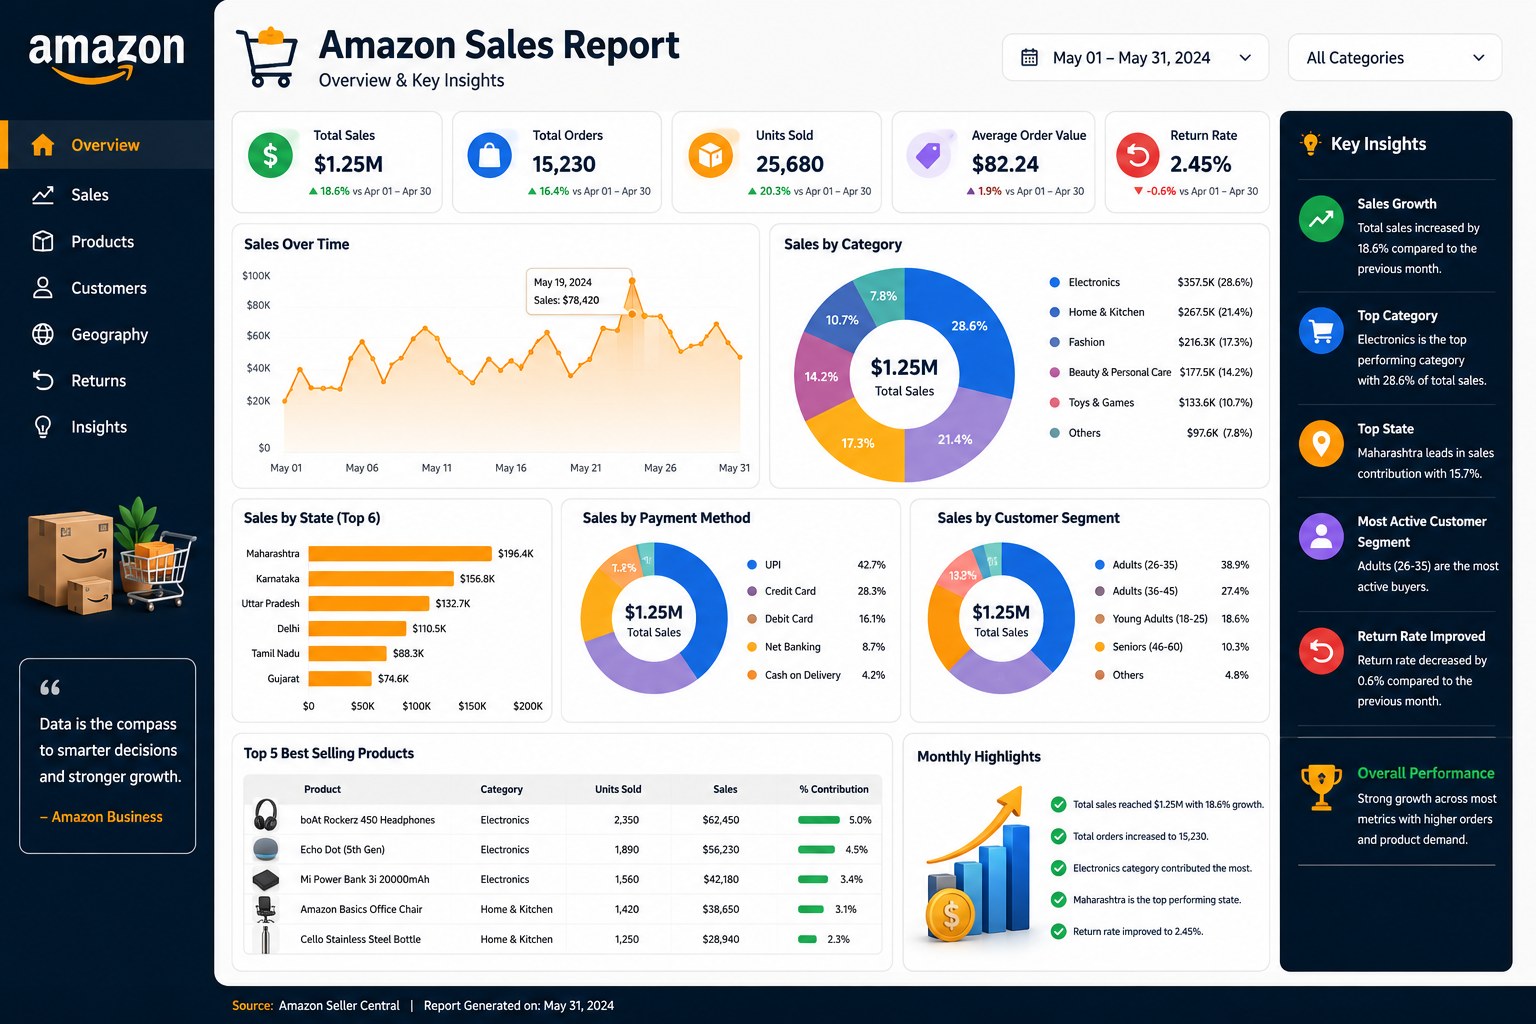




 ================================================================

 ## PROJECT: Amazon Sales Data Analysis – A Statistical Investigation

 STEP 1: Setup and Environment Preparation

 ================================================================



 Objective:

- Prepare the working environment by importing required libraries,
- configuring notebook settings, and creating reusable helper
- functions for logging and validation.





1.1 Import Required Libraries

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Testing
from scipy import stats

# Warning Control
import warnings
warnings.filterwarnings("ignore")


2. **Data Loading and Initial Inspection**
- Goal – Read the CSV, understand its structure, and assess data quality.

In [ ]:
df = pd.read_csv("Amazon Sale Report.csv", encoding='latin1', on_bad_lines='skip')

print("Dataset Loaded Successfully")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset Loaded Successfully
Rows: 128975
Columns: 24


- Error Handling Check #1

In [ ]:
if 'df' not in locals():
    raise ValueError("Dataset was not loaded.")

3. Display Basic Information
- Task: Print df.shape, df.columns, df.dtypes, df.head().


In [ ]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


- 4.Dataset Dimensions

In [ ]:
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

Rows: 128975
Columns: 24


- Column Names

In [ ]:
print(df.columns.tolist())

['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'Unnamed: 22']


- Data Types

In [ ]:
df.dtypes

,0
index,int64
Order ID,object
Date,object
Status,object
Fulfilment,object
Sales Channel,object
ship-service-level,object
Style,object
SKU,object
Category,object


- Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

- Missing Value Analysis

Purpose
Calculate:

- Missing count
- Missing percentage

Display:

- Missing values table
- Columns with no missing values
- Columns having missing values

Error Handling

- Handle completely empty columns.
- Warn if all values are missing.

In [ ]:
# Step 1: count how many missing (null) values are in each column
missing_counts = df.isnull().sum()

# Step 2: Calculate the percentage of missing values for each column
# This is done by dividing the missing count by the total number of rows and multiplying by 100
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Step 3: Combine these two pieces of information into a simple table (DataFrame)
missing_report_simplified = pd.DataFrame({
    "Number of Missing Values": missing_counts,
    "Percentage Missing (%)": missing_percentages
})

# Step 4: Display the report, sorted from highest to lowest percentage of missing values
print("Simplified Missing Value Report:")
print(missing_report_simplified.sort_values(by="Percentage Missing (%)", ascending=False))

Simplified Missing Value Report:
                    Number of Missing Values  Percentage Missing (%)
fulfilled-by                           89698               69.546811
promotion-ids                          49153               38.110487
Unnamed: 22                            49050               38.030626
currency                                7795                6.043807
Amount                                  7795                6.043807
Courier Status                          6872                5.328164
ship-country                              33                0.025586
ship-city                                 33                0.025586
ship-state                                33                0.025586
ship-postal-code                          33                0.025586
Sales Channel                              0                0.000000
Fulfilment                                 0                0.000000
Status                                     0                0.000000
D

- Identify Columns With More Than 20% Missing Values

In [ ]:
 # Identify Columns With More Than 20% Missing Values
columns_with_high_missing_values = missing_report_simplified[missing_report_simplified["Percentage Missing (%)"] > 20]

# Display the identified columns
if not columns_with_high_missing_values.empty:
    print("Columns with more than 20% missing values:")
    print(columns_with_high_missing_values)
else:
    print("No columns found with more than 20% missing values.")

Columns with more than 20% missing values:
               Number of Missing Values  Percentage Missing (%)
promotion-ids                     49153               38.110487
fulfilled-by                      89698               69.546811
Unnamed: 22                       49050               38.030626


###  Missing Values

There are **3 columns** (`promotion-ids`, `fulfilled-by`, and `Unnamed: 22`) that have more than 20% missing values. These columns might require specific handling, such as removal or imputation, depending on their relevance to the analysis.

- Duplicate Customer Check

In [ ]:
# Check for duplicate 'Order ID's
duplicate_order_ids = df[df.duplicated(subset=['Order ID'], keep=False)]

if not duplicate_order_ids.empty:
    print(f"Number of duplicate 'Order ID's: {len(duplicate_order_ids)}")
    print("Sample of duplicate 'Order ID's:")
    display(duplicate_order_ids.sort_values(by='Order ID').head())
else:
    print("No duplicate 'Order ID's found.")

Number of duplicate 'Order ID's: 15443
Sample of duplicate 'Order ID's:


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
78939,78939,171-0012693-2893106,05-07-22,Cancelled,Merchant,Amazon.in,Standard,NW015,NW015-TP-PJ-S,Set,...,INR,477.14,SRI GANGANAGAR,RAJASTHAN,335001.0,IN,NaN,False,Easy Ship,False
78938,78938,171-0012693-2893106,05-07-22,Cancelled,Merchant,Amazon.in,Standard,NW030,NW030-TP-PJ-S,Set,...,INR,538.10,SRI GANGANAGAR,RAJASTHAN,335001.0,IN,NaN,False,Easy Ship,False
91476,91476,171-0014231-7760344,06-29-22,Pending,Amazon,Amazon.in,Expedited,J0224,J0224-SKD-XS,Set,...,INR,1364.00,AHMEDABAD,Gujarat,380015.0,IN,NaN,False,NaN,False
91475,91475,171-0014231-7760344,06-29-22,Pending,Amazon,Amazon.in,Expedited,SET342,SET342-KR-NP-N-XS,Set,...,INR,850.00,AHMEDABAD,Gujarat,380015.0,IN,NaN,False,NaN,False
24515,24515,171-0015435-1981904,04-16-22,Shipped,Amazon,Amazon.in,Expedited,JNE3611,JNE3611-KR-L,kurta,...,INR,459.00,Pimpri Chinchwad,MAHARASHTRA,412101.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN


In [ ]:
# Check for entirely duplicate rows in the DataFrame
duplicate_rows = df[df.duplicated(keep=False)]

if not duplicate_rows.empty:
    print(f"Number of entirely duplicate rows: {len(duplicate_rows)}")
    print("Sample of entirely duplicate rows:")
    display(duplicate_rows.sort_values(by='Order ID').head())
else:
    print("No entirely duplicate rows found.")

No entirely duplicate rows found.


### Observation on Duplicates

- We found **15,443 rows with duplicate 'Order ID's**. This indicates that many orders might contain multiple items, leading to multiple entries sharing the same order ID.
- No entirely duplicate rows were found, suggesting unique records even if they share an 'Order ID'.

This observation helps in understanding the structure of the sales data, where a single order can comprise several distinct items, each recorded as a separate row.

**Numerical Summary**
- Check Numeric value


In [ ]:
df.describe()

,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


- Check Categorical Value

In [ ]:
df.describe(include='object')

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,currency,ship-city,ship-state,ship-country,promotion-ids,fulfilled-by,Unnamed: 22
count,128975,128975,128975,128975,128975,128975,128975,128975,128975,128975,128975,122103,121180,128942,128942,128942,79822,39277,79925
unique,120378,91,13,2,2,2,1377,7195,9,11,7190,3,1,8955,69,1,5787,1,1
top,403-4984515-8861958,05-03-22,Shipped,Amazon,Amazon.in,Expedited,JNE3797,JNE3797-KR-L,Set,M,B09SDXFFQ1,Shipped,INR,BENGALURU,MAHARASHTRA,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,Easy Ship,False
freq,12,2085,77804,89698,128851,88615,4224,773,50284,22711,773,109487,121180,11217,22260,128942,46100,39277,79925


# Step 2: Data Cleaning
- Create a Working Copy

**Tasks**

- Copy df to df_clean.
- Display initial shape.
- Verify DataFrame exists.

**Error Handling**

- Check if df exists.
- Check if df is empty.
- Stop execution with a clear message if validation fails.

In [ ]:
df_clean = df.copy()
print("Dataset Loaded Successfully")
print(f"Rows: {df_clean.shape[0]}")
print(f"Columns: {df_clean.shape[1]}")

Dataset Loaded Successfully
Rows: 128975
Columns: 24


### Remove Unnecessary Columns

**Purpose**

Remove columns that are unnecessary or contain excessive missing values.

**Tasks**

- Remove Unnamed: 22 (if present).
- Optionally remove promotion-ids.
- Optionally remove columns with more - than 50% missing values.
- Print removed columns.

**Error Handling**

- Check column existence before dropping.
- Skip missing columns without raising errors.

In [ ]:
columns_to_drop = ['Unnamed: 22', 'promotion-ids']

# Filter out columns that do not exist in df_clean to prevent errors
existing_columns_to_drop = [col for col in columns_to_drop if col in df_clean.columns]

if existing_columns_to_drop:
    df_clean.drop(columns=existing_columns_to_drop, inplace=True)
    print(f"Dropped columns: {existing_columns_to_drop}")
else:
    print("No specified columns were found to drop.")

print(f"Current columns in df_clean: {df_clean.columns.tolist()}")

Dropped columns: ['Unnamed: 22', 'promotion-ids']
Current columns in df_clean: ['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'B2B', 'fulfilled-by']


### Handling Duplicate 'Order ID's

As observed, the duplicate 'Order ID's indicate multiple items within a single order. This is a common and expected structure in sales datasets, where each row represents a distinct item sold as part of an order. For current analysis, these rows are valuable for understanding item-level sales. If future analysis requires aggregated order-level data (e.g., total sales per order), we can sum up the 'Amount' for each unique 'Order ID' at that stage. For now, we will retain these rows to preserve the detailed item information.

### Addressing Remaining Missing Values

The `fulfilled-by` column still has a significant number of missing values (69.5%). Since this is a categorical column, a suitable approach is to fill these missing values with a placeholder like 'Unknown'. This allows us to retain these records without losing information, while clearly indicating that the fulfillment method for these orders was not specified.

In [ ]:
# Fill missing values in 'fulfilled-by' with 'Unknown'
df_clean['fulfilled-by'] = df_clean['fulfilled-by'].fillna('Unknown')

# Verify the missing values after filling
missing_fulfilled_by = df_clean['fulfilled-by'].isnull().sum()
print(f"Missing values in 'fulfilled-by' after filling: {missing_fulfilled_by}")

# Display the updated value counts for 'fulfilled-by'
print("\nUpdated 'fulfilled-by' value counts:")
display(df_clean['fulfilled-by'].value_counts())

Missing values in 'fulfilled-by' after filling: 0

Updated 'fulfilled-by' value counts:


,count
fulfilled-by,
Unknown,89698
Easy Ship,39277


### Summary of Missing Value Handling

We have successfully addressed the missing values in the dataset:

*   **`promotion-ids`** and **`Unnamed: 22`**: These columns, identified with over 20% missing values, were removed as they were deemed unnecessary for the analysis.
*   **`fulfilled-by`**: The missing values in this categorical column were filled with 'Unknown', allowing us to retain the records while accurately representing the absence of fulfillment information.

Now, let's re-check the overall missing value status of our `df_clean` DataFrame to ensure all major missing data issues have been resolved.

In [ ]:
# Recalculate missing values for df_clean
missing_counts_clean = df_clean.isnull().sum()
missing_percentages_clean = (df_clean.isnull().sum() / len(df_clean)) * 100

missing_report_clean = pd.DataFrame({
    "Number of Missing Values": missing_counts_clean,
    "Percentage Missing (%)": missing_percentages_clean
})

print("Updated Missing Value Report for df_clean:")
print(missing_report_clean.sort_values(by="Percentage Missing (%)", ascending=False))

Updated Missing Value Report for df_clean:
                    Number of Missing Values  Percentage Missing (%)
currency                                7795                6.043807
Amount                                  7795                6.043807
Courier Status                          6872                5.328164
ship-city                                 33                0.025586
ship-postal-code                          33                0.025586
ship-state                                33                0.025586
ship-country                              33                0.025586
Fulfilment                                 0                0.000000
Sales Channel                              0                0.000000
Date                                       0                0.000000
Order ID                                   0                0.000000
index                                      0                0.000000
Status                                     0                

### Handling Remaining Missing Values

Based on the updated missing value report, we still have missing values in the `currency`, `Amount`, `Courier Status`, `ship-city`, `ship-state`, `ship-postal-code`, and `ship-country` columns.

Let's first inspect the unique values of the `currency` column to decide on an imputation strategy.

In [ ]:
# Check unique values in the 'currency' column of df_clean
print("Unique values in 'currency' column:")
print(df_clean['currency'].unique())

# Check the mode of the 'currency' column
currency_mode = df_clean['currency'].mode()[0]
print(f"\nMode of 'currency' column: {currency_mode}")

Unique values in 'currency' column:
['INR' nan]

Mode of 'currency' column: INR


### Imputing Remaining Missing Values

Given that 'INR' is the only recorded currency, we will fill the missing values in the `currency` column with 'INR'. The `Amount` column, having the same number of missing values as `currency` and a minimum value of 0, will be imputed with 0 to represent unrecorded amounts.

For `Courier Status`, a categorical column, 'Unknown' will be used to indicate missing information. Similarly, for the categorical shipping details (`ship-city`, `ship-state`, `ship-country`), 'Unknown' will be used, and for the numerical `ship-postal-code`, `0.0` will serve as a placeholder due to the very small number of missing entries.

In [ ]:
# Fill missing values in 'currency' with its mode 'INR'
df_clean['currency'].fillna(df_clean['currency'].mode()[0], inplace=True)

# Fill missing values in 'Amount' with 0
df_clean['Amount'].fillna(0, inplace=True)

# Fill missing values in 'Courier Status' with 'Unknown'
df_clean['Courier Status'].fillna('Unknown', inplace=True)

# Fill missing values in shipping-related categorical columns with 'Unknown'
shipping_categorical_cols = ['ship-city', 'ship-state', 'ship-country']
for col in shipping_categorical_cols:
    df_clean[col].fillna('Unknown', inplace=True)

# Fill missing values in 'ship-postal-code' with 0.0
df_clean['ship-postal-code'].fillna(0.0, inplace=True)

print("Missing values imputation complete for currency, Amount, Courier Status, and shipping details.")

Missing values imputation complete for currency, Amount, Courier Status, and shipping details.


### Final Missing Value Report

Let's re-run the missing value report to confirm that all identified missing values have been addressed.

In [ ]:
# Recalculate missing values for df_clean after all imputations
missing_counts_final = df_clean.isnull().sum()
missing_percentages_final = (df_clean.isnull().sum() / len(df_clean)) * 100

missing_report_final = pd.DataFrame({
    "Number of Missing Values": missing_counts_final,
    "Percentage Missing (%)": missing_percentages_final
})

print("Final Missing Value Report for df_clean:")
print(missing_report_final.sort_values(by="Percentage Missing (%)", ascending=False))

Final Missing Value Report for df_clean:
                    Number of Missing Values  Percentage Missing (%)
index                                      0                     0.0
Order ID                                   0                     0.0
Date                                       0                     0.0
Status                                     0                     0.0
Fulfilment                                 0                     0.0
Sales Channel                              0                     0.0
ship-service-level                         0                     0.0
Style                                      0                     0.0
SKU                                        0                     0.0
Category                                   0                     0.0
Size                                       0                     0.0
ASIN                                       0                     0.0
Courier Status                             0                  

### Step 3: Feature Engineering

**Goal:** Create meaningful features from the cleaned dataset to enhance exploratory analysis, statistical testing, and predictive modeling. These engineered features should provide additional business value while preserving the original data.

#### 1. Create a Feature Engineering Copy

**Purpose**

- Create a separate DataFrame for feature engineering.
- -Preserve the cleaned dataset (df_clean) as a backup.
- Verify dataset integrity before creating new features.

**Tasks**

- Copy df_clean to df_features.
- Display current shape.
- Verify required columns exist.

**Error Handling**

- Check if df_clean exists.
- Ensure the DataFrame is not empty.
- Stop execution with a clear message if validation fails.

In [ ]:
df_features = df_clean.copy()
print("Dataset Loaded Successfully")
print(f"Rows: {df_features.shape[0]}")
print(f"Columns: {df_features.shape[1]}")

Dataset Loaded Successfully
Rows: 128975
Columns: 22


###n2. Extract Date Features


**Purpose**

- Generate time-based features for trend and seasonal analysis.

- New Features
- Year
- Month
- Month Name
- Quarter
- Week Number
- Day
- Day Name
- Weekend Flag (Is_Weekend)

**Business Value**

- Monthly sales trends
- Quarterly performance
- Weekday vs Weekend comparison
- Seasonal analysis

**Error Handling**

- Ensure Date column exists.
- Skip feature creation if Date contains invalid values.
- Handle missing dates gracefully.

In [ ]:
if 'Date' not in df_features.columns:
    print("Error: 'Date' column not found in df_features.")
else:
    # Convert 'Date' column to datetime objects, coercing errors to NaT
    df_features['Date'] = pd.to_datetime(df_features['Date'], errors='coerce')

    # Drop rows where 'Date' conversion resulted in NaT (invalid dates)
    initial_rows = df_features.shape[0]
    df_features.dropna(subset=['Date'], inplace=True)
    if df_features.shape[0] < initial_rows:
        print(f"Warning: {initial_rows - df_features.shape[0]} rows dropped due to invalid dates.")

    if not df_features['Date'].empty:
        # Extract new date features
        df_features['Year'] = df_features['Date'].dt.year
        df_features['Month'] = df_features['Date'].dt.month
        df_features['Month Name'] = df_features['Date'].dt.month_name()
        df_features['Quarter'] = df_features['Date'].dt.quarter
        df_features['Week Number'] = df_features['Date'].dt.isocalendar().week.astype(int)
        df_features['Day'] = df_features['Date'].dt.day
        df_features['Day Name'] = df_features['Date'].dt.day_name()
        df_features['Is_Weekend'] = df_features['Date'].dt.dayofweek >= 5  # Saturday (5) or Sunday (6)

        print("Date features extracted successfully.")
        print("New columns added: Year, Month, Month Name, Quarter, Week Number, Day, Day Name, Is_Weekend")
        display(df_features[['Date', 'Year', 'Month', 'Month Name', 'Quarter', 'Week Number', 'Day', 'Day Name', 'Is_Weekend']].head())
    else:
        print("No valid dates remaining after cleaning. Skipping feature extraction.")

Date features extracted successfully.
New columns added: Year, Month, Month Name, Quarter, Week Number, Day, Day Name, Is_Weekend


,Date,Year,Month,Month Name,Quarter,Week Number,Day,Day Name,Is_Weekend
0,2022-04-30,2022,4,April,2,17,30,Saturday,True
1,2022-04-30,2022,4,April,2,17,30,Saturday,True
2,2022-04-30,2022,4,April,2,17,30,Saturday,True
3,2022-04-30,2022,4,April,2,17,30,Saturday,True
4,2022-04-30,2022,4,April,2,17,30,Saturday,True


#### 3. Create Revenue Metrics

**Purpose**

Generate additional sales-related metrics.

- New Features
- Revenue_per_Unit = Amount / Qty
- Log_Amount (optional)
- High_Value_Order (binary flag)

**Business Value**

- Identify expensive products.
- Detect premium orders.
- Reduce skewness for statistical analysis.

**Error Handling**

- Prevent division by zero.
- Replace infinite values with NaN.
- Handle missing Amount or Qty values.

In [ ]:
if 'Amount' not in df_features.columns or 'Qty' not in df_features.columns:
    print("Error: 'Amount' or 'Qty' column not found in df_features. Skipping revenue metrics.")
else:
    # Ensure 'Amount' and 'Qty' are numeric, coercing errors
    df_features['Amount'] = pd.to_numeric(df_features['Amount'], errors='coerce')
    df_features['Qty'] = pd.to_numeric(df_features['Qty'], errors='coerce')

    # Handle missing values in 'Amount' and 'Qty' before calculations
    df_features['Amount'].fillna(0, inplace=True)
    df_features['Qty'].fillna(0, inplace=True)

    # Feature 1: Revenue_per_Unit (handle division by zero)
    df_features['Revenue_per_Unit'] = df_features.apply(lambda row: row['Amount'] / row['Qty'] if row['Qty'] != 0 else 0, axis=1)

    # Replace infinite values that might result from division with NaN, then fill with 0
    df_features['Revenue_per_Unit'].replace([np.inf, -np.inf], np.nan, inplace=True)
    df_features['Revenue_per_Unit'].fillna(0, inplace=True)

    # Feature 2: Log_Amount (handle non-positive values)
    # Add a small constant to avoid log(0) and filter out negative values if any exist
    df_features['Log_Amount'] = np.log1p(df_features['Amount'].apply(lambda x: max(0, x))) # log1p(x) = log(1+x), handles 0 gracefully

    # Feature 3: High_Value_Order (binary flag based on a threshold)
    # Using the 75th percentile of 'Amount' as a dynamic threshold, or 1000 if not enough data
    threshold = df_features['Amount'].quantile(0.75) if not df_features['Amount'].empty else 1000
    df_features['High_Value_Order'] = (df_features['Amount'] > threshold).astype(int)

    print("Revenue metrics extracted successfully.")
    print("New columns added: Revenue_per_Unit, Log_Amount, High_Value_Order")
    display(df_features[['Amount', 'Qty', 'Revenue_per_Unit', 'Log_Amount', 'High_Value_Order']].head())

Revenue metrics extracted successfully.
New columns added: Revenue_per_Unit, Log_Amount, High_Value_Order


,Amount,Qty,Revenue_per_Unit,Log_Amount,High_Value_Order
0,647.62,0,0.0,6.474847,0
1,406.00,1,406.0,6.008813,0
2,329.00,1,329.0,5.799093,0
3,753.33,0,0.0,6.625830,0
4,574.00,1,574.0,6.354370,0


#### 4. Standardize Product Categories

**Purpose**

- Reduce category complexity for easier reporting.

**Tasks**

- Group similar product categories.
- Keep original category column.
- Create a new column:
- Category_Group
Example

Kurta
Kurta Set
Kurti

↓

Kurta.

**Business Value**

- Cleaner visualizations.
- Better statistical comparison.
- Easier business reporting.

**Error Handling**

- Keep unknown categories unchanged.
- Log unmapped values.



In [ ]:
if 'Category' not in df_features.columns:
    print("Error: 'Category' column not found in df_features. Cannot standardize product categories.")
else:
    print("Unique categories before standardization:")
    print(df_features['Category'].value_counts())

    # Define a mapping for category standardization
    category_mapping = {
        'Set': 'Set',
        'kurta': 'Kurta',
        'Western Dress': 'Western Dress',
        'Top': 'Top',
        'Ethnic Dress': 'Ethnic Dress',
        'Bottom': 'Bottom',
        'Blouse': 'Blouse',
        'Saree': 'Saree',
        'Bra': 'Bra',
        # Add other specific mappings if needed based on inspection
        # For example, if there were 'Kurti' or 'Kurta Set', they would map to 'Kurta'
    }

    # Create the 'Category_Group' column
    # Use .get() with a default to handle categories not in the mapping (keep original or assign 'Other')
    df_features['Category_Group'] = df_features['Category'].apply(lambda x: category_mapping.get(x, x))

    # Identify unmapped values (if any) for logging
    unmapped_categories = df_features[~df_features['Category'].isin(category_mapping.keys())]['Category'].unique()
    if len(unmapped_categories) > 0:
        print("\nWarning: The following categories were not explicitly mapped and retain their original names:")
        print(unmapped_categories)

    print("\nProduct categories standardized successfully. 'Category_Group' column created.")
    print("Unique categories after standardization:")
    print(df_features['Category_Group'].value_counts())
    display(df_features[['Category', 'Category_Group']].head())

Unique categories before standardization:
Category
Set              50284
kurta            49877
Western Dress    15500
Top              10622
Ethnic Dress      1159
Blouse             926
Bottom             440
Saree              164
Dupatta              3
Name: count, dtype: int64

['Dupatta']

Product categories standardized successfully. 'Category_Group' column created.
Unique categories after standardization:
Category_Group
Set              50284
Kurta            49877
Western Dress    15500
Top              10622
Ethnic Dress      1159
Blouse             926
Bottom             440
Saree              164
Dupatta              3
Name: count, dtype: int64


,Category,Category_Group
0,Set,Set
1,kurta,Kurta
2,kurta,Kurta
3,Western Dress,Western Dress
4,Top,Top


#### 5. Promotion Feature

**Purpose**

- Identify whether an order used a promotion.

**New Feature**

- Has_Promotion

**Values**

- True
- False

**Business Value**

- Compare promotional vs non-promotional sales.
- Measure promotion effectiveness.

**Error Handling**

- Skip if promotion-ids column is unavailable.
- Treat missing values as no promotion

In [ ]:
if 'promotion-ids' not in df_features.columns:
    print("Warning: 'promotion-ids' column not found in df_features. Skipping 'Has_Promotion' feature creation.")
else:
    # Assuming 'promotion-ids' exists and 'None' indicates no promotion
    df_features['Has_Promotion'] = df_features['promotion-ids'] != 'None'
    print("\n'Has_Promotion' feature created successfully.")
    display(df_features[['promotion-ids', 'Has_Promotion']].head())

### 6. Create Geographic Features

**Purpose**

Group Indian states into larger business regions.

**Example Regions**
- North
- South
- East
- West
- Central
- North-East
- Other

**New Feature**

Region

**Business Value**
- Regional sales analysis
- Heat maps
- Business expansion planning

**Error Handling**

- Use mapping dictionary.
- Unknown states → "Other"

In [ ]:
if 'ship-state' not in df_features.columns:
    print("Error: 'ship-state' column not found in df_features. Cannot create geographic features.")
else:
    # Define mapping of Indian states to regions
    state_to_region = {
        # North
        'JAMMU & KASHMIR': 'North',
        'HIMACHAL PRADESH': 'North',
        'PUNJAB': 'North',
        'UTTARAKHAND': 'North',
        'HARYANA': 'North',
        'DELHI': 'North',
        'UTTAR PRADESH': 'North',
        'CHANDIGARH': 'North',

        # South
        'ANDHRA PRADESH': 'South',
        'KARNATAKA': 'South',
        'KERALA': 'South',
        'TAMIL NADU': 'South',
        'TELANGANA': 'South',
        'PUDUCHERRY': 'South',

        # East
        'BIHAR': 'East',
        'WEST BENGAL': 'East',
        'ODISHA': 'East',
        'JHARKHAND': 'East',
        'CHHATTISGARH': 'East',

        # West
        'GUJARAT': 'West',
        'RAJASTHAN': 'West',
        'MAHARASHTRA': 'West',
        'GOA': 'West',
        'DADRA AND NAGAR HAVELI': 'West',
        'DAMAN & DIU': 'West',

        # Central
        'MADHYA PRADESH': 'Central',

        # North-East
        'ASSAM': 'North-East',
        'ARUNACHAL PRADESH': 'North-East',
        'MANIPUR': 'North-East',
        'MEGHALAYA': 'North-East',
        'MIZORAM': 'North-East',
        'NAGALAND': 'North-East',
        'TRIPURA': 'North-East',
        'SIKKIM': 'North-East',

        # Other (for Union Territories or unlisted states)
        # Note: 'Unknown' from previous cleaning will also map to 'Other'
    }

    # Create 'Region' column using the mapping, default to 'Other' for unmapped states
    df_features['Region'] = df_features['ship-state'].apply(lambda x: state_to_region.get(str(x).upper(), 'Other'))

    print("Geographic 'Region' feature created successfully.")
    print("Unique regions and their counts:")
    print(df_features['Region'].value_counts())
    display(df_features[['ship-state', 'Region']].head())

Geographic 'Region' feature created successfully.
Unique regions and their counts:
Region
South         52504
West          30597
North         27313
East          12578
North-East     2949
Central        2529
Other           505
Name: count, dtype: int64


,ship-state,Region
0,MAHARASHTRA,West
1,KARNATAKA,South
2,MAHARASHTRA,West
3,PUDUCHERRY,South
4,TAMIL NADU,South


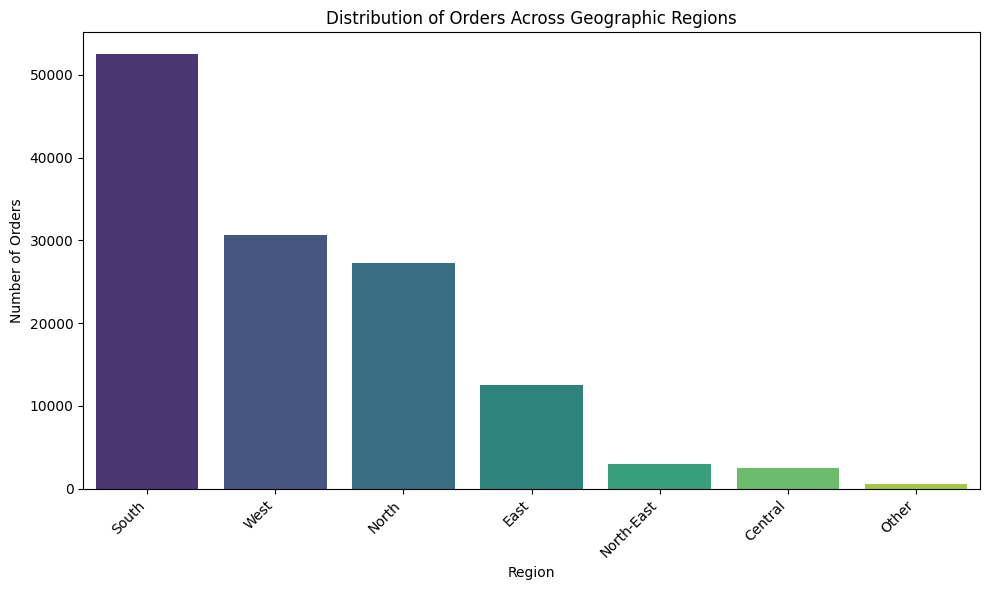

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the counts of each region
region_counts = df_features['Region'].value_counts().reset_index()
region_counts.columns = ['Region', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Count', data=region_counts, palette='viridis')
plt.title('Distribution of Orders Across Geographic Regions')
plt.xlabel('Region')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

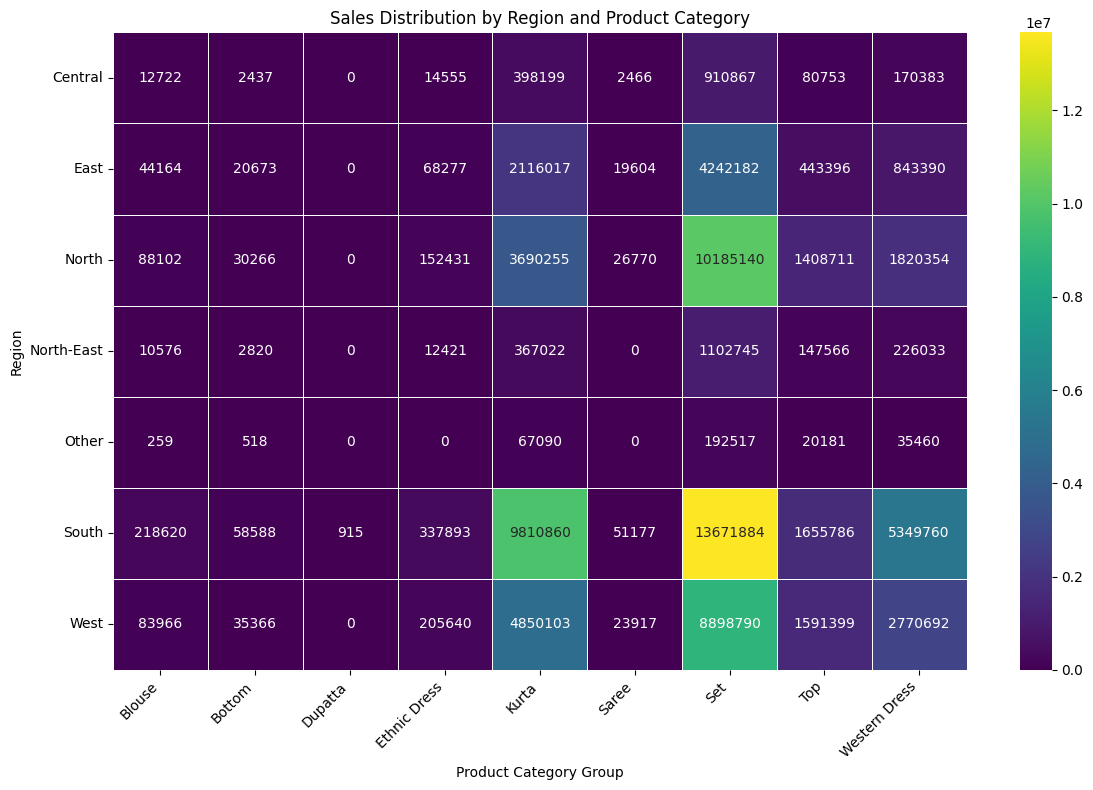

In [ ]:
# Calculate total sales amount by Region and Category_Group
regional_category_sales = df_features.groupby(['Region', 'Category_Group'])['Amount'].sum().unstack(fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(regional_category_sales, annot=True, fmt=".0f", cmap="viridis", linewidths=.5)
plt.title('Sales Distribution by Region and Product Category')
plt.xlabel('Product Category Group')
plt.ylabel('Region')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 7.Create Order Size Segments

**Purpose**

- Segment orders based on purchase value.

**Example**

Amount

- 0–500        - Low Value
- 501–1500     - Medium Value
- 1501–3000    - High Value
- 3000+        - Premium

**New Feature**

Order_Value_Segment

**Business Value**

- Customer purchasing behavior
- Segment-wise revenue analysis
- Premium customer identification

**Error Handling**

- Ignore missing Amount values.
- Handle negative amounts.

In [ ]:
if 'Amount' not in df_features.columns:
    print("Error: 'Amount' column not found in df_features. Cannot create Order Size Segments.")
else:
    # Define the bins and labels for the order value segments
    bins = [0, 500, 1500, 3000, float('inf')]
    labels = ['Low Value', 'Medium Value', 'High Value', 'Premium']

    # Ensure 'Amount' is numeric and handle potential negative values by setting them to 0
    df_features['Amount'] = pd.to_numeric(df_features['Amount'], errors='coerce').fillna(0)
    df_features['Amount'] = df_features['Amount'].apply(lambda x: max(0, x))

    # Create the 'Order_Value_Segment' column
    df_features['Order_Value_Segment'] = pd.cut(
        df_features['Amount'],
        bins=bins,
        labels=labels,
        right=True, # This means the bins include the rightmost edge, e.g., (500, 1500]
        include_lowest=True # This means the first bin includes the lowest value, e.g., [0, 500]
    )

    print("Order_Value_Segment feature created successfully.")
    print("Unique order value segments and their counts:")
    print(df_features['Order_Value_Segment'].value_counts())
    display(df_features[['Amount', 'Order_Value_Segment']].head())

Order_Value_Segment feature created successfully.
Unique order value segments and their counts:
Order_Value_Segment
Medium Value    76802
Low Value       51431
High Value        738
Premium             4
Name: count, dtype: int64


,Amount,Order_Value_Segment
0,647.62,Medium Value
1,406.00,Low Value
2,329.00,Low Value
3,753.33,Medium Value
4,574.00,Medium Value


### 8.Create Quantity Segments

**Purpose**

Categorize orders by quantity purchased.

**Example**

Qty

- 1        Single Item
- 2–3      Small Order
- 4–6      Medium Order
- 7+       Bulk Order


**New Feature**

Quantity_Segment

**Business Value**

- Bulk buying analysis
- Inventory planning
- Demand forecasting

**Error Handling**
- Handle missing quantities.
- Ignore negative values.

In [ ]:
if 'Qty' not in df_features.columns:
    print("Error: 'Qty' column not found in df_features. Cannot create Quantity Segments.")
else:
    # Define the bins and labels for the quantity segments
    # The bins are inclusive on the left, exclusive on the right, except the last bin
    bins = [0, 1, 3, 6, float('inf')]
    labels = ['Single Item', 'Small Order', 'Medium Order', 'Bulk Order']

    # Ensure 'Qty' is numeric and handle potential missing or negative values
    df_features['Qty'] = pd.to_numeric(df_features['Qty'], errors='coerce').fillna(0)
    df_features['Qty'] = df_features['Qty'].apply(lambda x: max(0, x)) # Ignore negative values by setting them to 0

    # Create the 'Quantity_Segment' column
    df_features['Quantity_Segment'] = pd.cut(
        df_features['Qty'],
        bins=bins,
        labels=labels,
        right=True, # (1,3] means 2 and 3. [0,1] means 1 for single item
        include_lowest=True # This means the first bin includes the lowest value, e.g., [0, 1]
    )

    print("Quantity_Segment feature created successfully.")
    print("Unique quantity segments and their counts:")
    print(df_features['Quantity_Segment'].value_counts())
    display(df_features[['Qty', 'Quantity_Segment']].head())

Quantity_Segment feature created successfully.
Unique quantity segments and their counts:
Quantity_Segment
Single Item     128587
Small Order        373
Medium Order        11
Bulk Order           4
Name: count, dtype: int64


,Qty,Quantity_Segment
0,0,Single Item
1,1,Single Item
2,1,Single Item
3,0,Single Item
4,1,Single Item


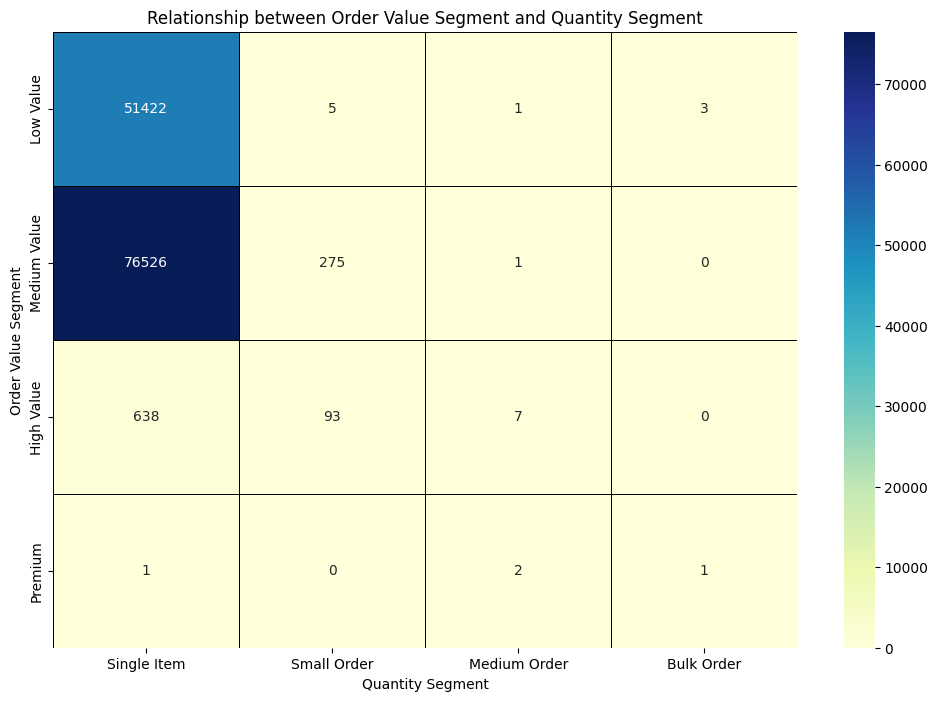

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a cross-tabulation of Order_Value_Segment and Quantity_Segment
segment_crosstab = pd.crosstab(df_features['Order_Value_Segment'], df_features['Quantity_Segment'])

# Plotting the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(segment_crosstab, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5, linecolor='black')
plt.title('Relationship between Order Value Segment and Quantity Segment')
plt.xlabel('Quantity Segment')
plt.ylabel('Order Value Segment')
plt.show()

### 9.Feature Validation

**Purpose**

Verify that every engineered feature was created correctly.

**Checks**
- Missing values
- Duplicate columns
- Data types
- Infinite values
- Unexpected categories

**Display**

- Number of new features
- Updated dataset shape
- Data types
- Sample records

**Error Handling**
- Warn if feature creation failed.
- Replace invalid values where appropriate.

In [ ]:
print("--- Feature Validation Report ---")

# 1. Number of new features
# Get columns from df_clean (before feature engineering) and df_features
original_cols = set(df_clean.columns)
engineered_cols = set(df_features.columns)

new_features = list(engineered_cols - original_cols)
print(f"\nNumber of new features created: {len(new_features)}")
print("New features: ", new_features)

# 2. Updated dataset shape
print(f"\nUpdated df_features shape: {df_features.shape}")

# 3. Check missing values in engineered features
print("\n--- Missing Values in df_features ---")
missing_values_report = df_features.isnull().sum()
missing_values_report = missing_values_report[missing_values_report > 0]
if not missing_values_report.empty:
    print("Missing values found in the following columns after feature engineering:")
    print(missing_values_report)
else:
    print("No missing values found in df_features after feature engineering.")

# 4. Data types check
print("\n--- Data Types of df_features ---")
print(df_features.dtypes)

# 5. Infinite values check (only for numeric columns)
print("\n--- Infinite Values in Numeric Columns ---")
numeric_cols = df_features.select_dtypes(include=np.number)
infinite_values = numeric_cols.apply(lambda x: np.isinf(x).sum())
infinite_values = infinite_values[infinite_values > 0]
if not infinite_values.empty:
    print("Infinite values found in the following numeric columns:")
    print(infinite_values)
else:
    print("No infinite values found in numeric columns.")

# 6. Check for unexpected categories (for new categorical features)
print("\n--- Unique Categories for New Categorical Features ---")
new_categorical_features = [
    'Month Name', 'Day Name', 'Is_Weekend', 'Category_Group',
    'Region', 'Order_Value_Segment', 'Quantity_Segment'
]

for col in new_categorical_features:
    if col in df_features.columns:
        print(f"\nUnique values for '{col}':")
        print(df_features[col].value_counts())
    else:
        print(f"Warning: '{col}' not found in df_features.")

# 7. Sample records
print("\n--- Sample of df_features (first 5 rows) ---")
display(df_features.head())

--- Feature Validation Report ---

Number of new features created: 15
New features:  ['Order_Value_Segment', 'Quarter', 'Category_Group', 'Day', 'Log_Amount', 'Month', 'High_Value_Order', 'Month Name', 'Region', 'Year', 'Revenue_per_Unit', 'Is_Weekend', 'Quantity_Segment', 'Week Number', 'Day Name']

Updated df_features shape: (128975, 37)

--- Missing Values in df_features ---
No missing values found in df_features after feature engineering.

--- Data Types of df_features ---
index                           int64
Order ID                       object
Date                   datetime64[ns]
Status                         object
Fulfilment                     object
Sales Channel                  object
ship-service-level             object
Style                          object
SKU                            object
Category                       object
Size                           object
ASIN                           object
Courier Status                 object
Qty                     

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,Day,Day Name,Is_Weekend,Revenue_per_Unit,Log_Amount,High_Value_Order,Category_Group,Region,Order_Value_Segment,Quantity_Segment
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,30,Saturday,True,0.0,6.474847,0,Set,West,Medium Value,Single Item
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,30,Saturday,True,406.0,6.008813,0,Kurta,South,Low Value,Single Item
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,30,Saturday,True,329.0,5.799093,0,Kurta,West,Low Value,Single Item
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,30,Saturday,True,0.0,6.625830,0,Western Dress,South,Medium Value,Single Item
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,30,Saturday,True,574.0,6.354370,0,Top,South,Medium Value,Single Item


#### 10.Feature Engineering Summary

**Display**

Dataset Summary

- Original Columns
- New Columns Added
- Final Number of Columns
- Dataset Shape

**New Features**

- Year
- Month
- Month_Name
- Quarter
- Week_Number
- Day
- Day_Name
- Is_Weekend
- Revenue_per_Unit
- Log_Amount (Optional)
- High_Value_Order
- Category_Group
- Has_Promotion
- Region
- Order_Value_Segment
- Quantity_Segment

In [ ]:
# Dataset Summary
print("--- Feature Engineering Summary ---")
print("\nDataset Summary:")

# Original Columns (from df_clean)
original_columns_list = df_clean.columns.tolist()
print(f"- Original Columns ({len(original_columns_list)}): {original_columns_list}")

# New Columns Added (difference between df_features and df_clean)
new_features_added = list(set(df_features.columns) - set(df_clean.columns))
print(f"- New Columns Added ({len(new_features_added)}): {new_features_added}")

# Final Number of Columns and Dataset Shape
print(f"- Final Number of Columns: {df_features.shape[1]}")
print(f"- Final Dataset Shape: {df_features.shape}")

# Listing all New Features explicitly mentioned in the task
print("\n--- List of New Features Engineered ---")
all_engineered_features = [
    'Year', 'Month', 'Month Name', 'Quarter', 'Week Number', 'Day', 'Day Name',
    'Is_Weekend', 'Revenue_per_Unit', 'Log_Amount', 'High_Value_Order',
    'Category_Group', 'Region', 'Order_Value_Segment', 'Quantity_Segment'
]

# Check if 'Has_Promotion' was actually created
if 'Has_Promotion' in df_features.columns:
    all_engineered_features.append('Has_Promotion')

for feature in all_engineered_features:
    if feature in df_features.columns:
        print(f"- {feature} (Data Type: {df_features[feature].dtype})")
    else:
        print(f"- {feature} (Not created or renamed)")

print("\nFeature Engineering Summary Completed.")

--- Feature Engineering Summary ---

Dataset Summary:
- Original Columns (22): ['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'B2B', 'fulfilled-by']
- New Columns Added (15): ['Order_Value_Segment', 'Quarter', 'Category_Group', 'Day', 'Log_Amount', 'Month', 'High_Value_Order', 'Month Name', 'Region', 'Year', 'Revenue_per_Unit', 'Is_Weekend', 'Quantity_Segment', 'Week Number', 'Day Name']
- Final Number of Columns: 37
- Final Dataset Shape: (128975, 37)

--- List of New Features Engineered ---
- Year (Data Type: int32)
- Month (Data Type: int32)
- Month Name (Data Type: object)
- Quarter (Data Type: int32)
- Week Number (Data Type: int64)
- Day (Data Type: int32)
- Day Name (Data Type: object)
- Is_Weekend (Data Type: bool)
- Revenue_per_Unit (Data Type: float64)
- Log_Amount (Data Type: f

**Validation Checklist**
- ✓ Date features created
- ✓ Revenue metrics calculated
- ✓ Product categories grouped
- ✓ Geographic regions assigned
- ✓ Order segments created
- ✓ No invalid values introduced
- ✓ Dataset ready for EDA

===============================================================================================

**STEP 3 COMPLETED SUCCESSFULLY**
**Feature Engineering Finished
Dataset Ready for Exploratory Data Analysis (EDA)**
======================================================================================
===================================================================================================

## Step 4: Exploratory Data Analysis (EDA)

Goal: Explore the dataset through descriptive statistics and visualizations to uncover sales trends, customer behavior, product performance, geographical patterns, and relationships between variables before performing statistical analysis.

### 4.1 EDA Setup & Dataset Validation

**Purpose**

Prepare the dataset for analysis and verify that all required features are available.

**Tasks**

- Validate df_features.
- Display dataset shape.
- Check data types.
- Verify key columns.
- Set visualization style.

**Error Handling**

- Stop if dataset is empty.
- Warn about missing required columns.
- Skip unavailable analyses gracefully.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("### 4.1 EDA Setup & Dataset Validation")

# Error Handling: Check if df_features exists and is not empty
if 'df_features' not in locals():
    raise ValueError("Error: 'df_features' DataFrame not found. Please ensure feature engineering was completed successfully.")

if df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame is empty. No data to analyze.")

print("df_features DataFrame is validated and ready for EDA.")

# Display dataset shape
print(f"\nDataset shape: {df_features.shape}")

# Check data types
print("\nData Types:")
print(df_features.dtypes)

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print("\nVisualization style set (seaborn whitegrid).")

### 4.1 EDA Setup & Dataset Validation
df_features DataFrame is validated and ready for EDA.

Dataset shape: (128975, 37)

Data Types:
index                           int64
Order ID                       object
Date                   datetime64[ns]
Status                         object
Fulfilment                     object
Sales Channel                  object
ship-service-level             object
Style                          object
SKU                            object
Category                       object
Size                           object
ASIN                           object
Courier Status                 object
Qty                             int64
currency                       object
Amount                        float64
ship-city                      object
ship-state                     object
ship-postal-code              float64
ship-country                   object
B2B                              bool
fulfilled-by                   object
Year                         

#### 4.2 Overall Business KPIs

**Purpose**

Generate high-level business metrics.

- Calculate
- Total Revenue
- Total Orders
- Total Quantity Sold
- Average Order Value (AOV)
- Average Revenue per Unit
- Total Categories
- Total States
- Total Regions
- Delivered Order Percentage
- Cancellation Rate
- Return Rate

**Business Value**

Provides an executive summary of business performance.

**Error Handling**

- Handle missing values.
- Prevent division by zero.
- Use cleaned dataset only.


In [ ]:
print("### 4.2 Overall Business KPIs")

# Ensure df_features is available and not empty (though already validated in 4.1)
if 'df_features' not in locals() or df_features.empty:
    raise ValueError("Error: df_features not found or is empty. Cannot calculate KPIs.")

# --- Calculations ---

# 1. Total Revenue
total_revenue = df_features['Amount'].sum()

# 2. Total Orders (count unique Order IDs)
total_orders = df_features['Order ID'].nunique()

# 3. Total Quantity Sold
total_quantity_sold = df_features['Qty'].sum()

# 4. Average Order Value (AOV)
aov = total_revenue / total_orders if total_orders > 0 else 0

# 5. Average Revenue per Unit
avg_revenue_per_unit = total_revenue / total_quantity_sold if total_quantity_sold > 0 else 0

# 6. Total Categories (using Category_Group)
total_categories = df_features['Category_Group'].nunique()

# 7. Total States (using ship-state, excluding 'Unknown')
total_states = df_features[df_features['ship-state'] != 'Unknown']['ship-state'].nunique()

# 8. Total Regions (using Region, excluding 'Other' if it's just a placeholder)
total_regions = df_features[df_features['Region'] != 'Other']['Region'].nunique()

# 9. Delivered Order Percentage
total_shipped_delivered = df_features[df_features['Status'] == 'Shipped - Delivered to Buyer'].shape[0]
total_valid_orders = df_features[~df_features['Status'].isin(['Cancelled', 'Return', 'Pending', 'Lost', 'RTO', 'Shipped - Returned to Seller'])].shape[0]

delivered_order_percentage = (total_shipped_delivered / total_valid_orders * 100) if total_valid_orders > 0 else 0

# 10. Cancellation Rate
total_cancelled_orders = df_features[df_features['Status'] == 'Cancelled'].shape[0]
cancellation_rate = (total_cancelled_orders / total_orders * 100) if total_orders > 0 else 0

# 11. Return Rate
# Assuming 'Return' in Status or 'Shipped - Returned to Seller' means a return
total_returned_orders = df_features[df_features['Status'].isin(['Return', 'Shipped - Returned to Seller'])].shape[0]
return_rate = (total_returned_orders / total_orders * 100) if total_orders > 0 else 0

# --- Display KPIs ---
print("\n--- Overall Business Key Performance Indicators (KPIs) ---")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Quantity Sold: {total_quantity_sold:,}")
print(f"Average Order Value (AOV): ₹{aov:,.2f}")
print(f"Average Revenue per Unit: ₹{avg_revenue_per_unit:,.2f}")
print(f"Total Unique Product Categories (Grouped): {total_categories:,}")
print(f"Total Unique States (Excluding Unknown): {total_states:,}")
print(f"Total Unique Regions (Excluding Other): {total_regions:,}")
print(f"Delivered Order Percentage: {delivered_order_percentage:,.2f}%")
print(f"Cancellation Rate: {cancellation_rate:,.2f}%")
print(f"Return Rate: {return_rate:,.2f}%")

### 4.2 Overall Business KPIs

--- Overall Business Key Performance Indicators (KPIs) ---
Total Revenue: ₹43,229,795.09
Total Orders: 66,951
Total Quantity Sold: 64,653
Average Order Value (AOV): ₹645.69
Average Revenue per Unit: ₹668.64
Total Unique Product Categories (Grouped): 8
Total Unique States (Excluding Unknown): 62
Total Unique Regions (Excluding Other): 6
Delivered Order Percentage: 29.83%
Cancellation Rate: 15.19%
Return Rate: 2.00%


#### 4.3 Univariate Analysis (Numerical Variables)

**Purpose**

Understand the distribution of numerical variables.

- Variables
- Amount
- Qty
- Revenue_per_Unit
- Visualizations
- Histogram
- KDE Plot
- Boxplot

**Display**
- Mean
- Median
- Standard Deviation
- Skewness
- Kurtosis

**Business Value**

- Detect skewness
- Identify outliers
- Understand sales distribution

**Error Handling**

- Skip columns with all missing values.
- Handle datasets with insufficient observations.

### 4.3 Univariate Analysis (Numerical Variables)

--- Analyzing: Amount ---
Mean: 609.36
Median: 583.00
Standard Deviation: 313.35
Skewness: 0.44
Kurtosis: 1.90


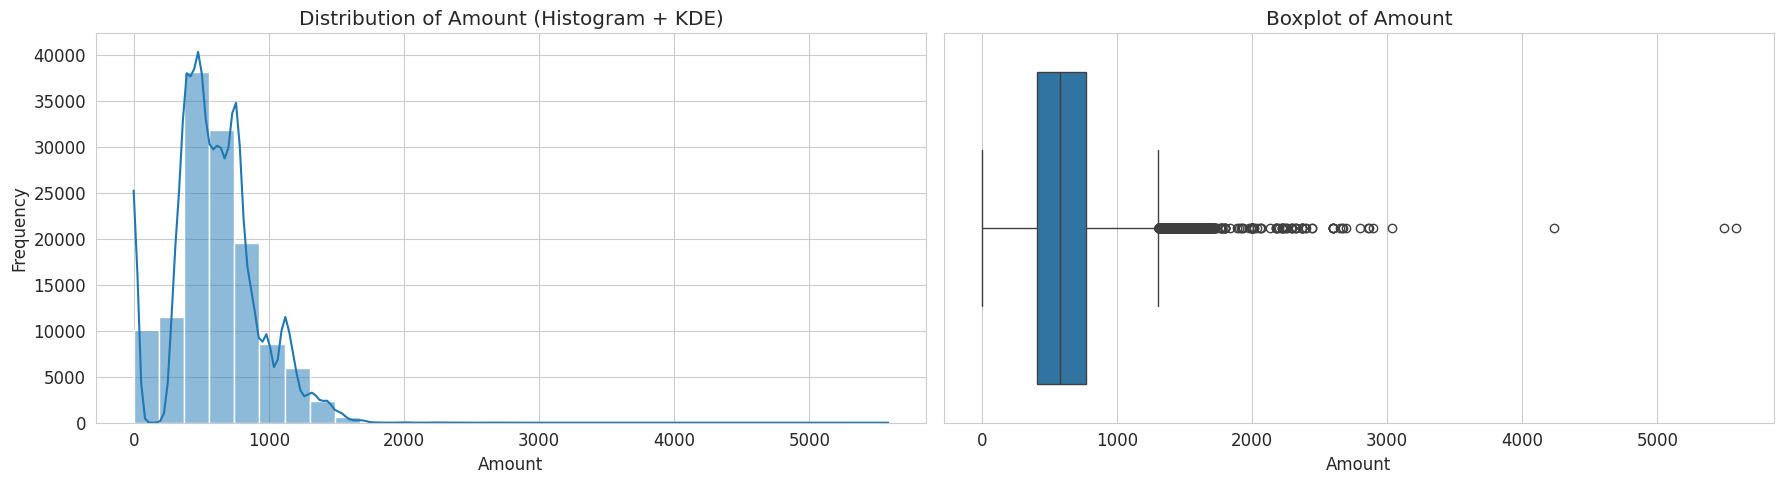


--- Analyzing: Qty ---
Mean: 0.90
Median: 1.00
Standard Deviation: 0.31
Skewness: -0.70
Kurtosis: 60.36


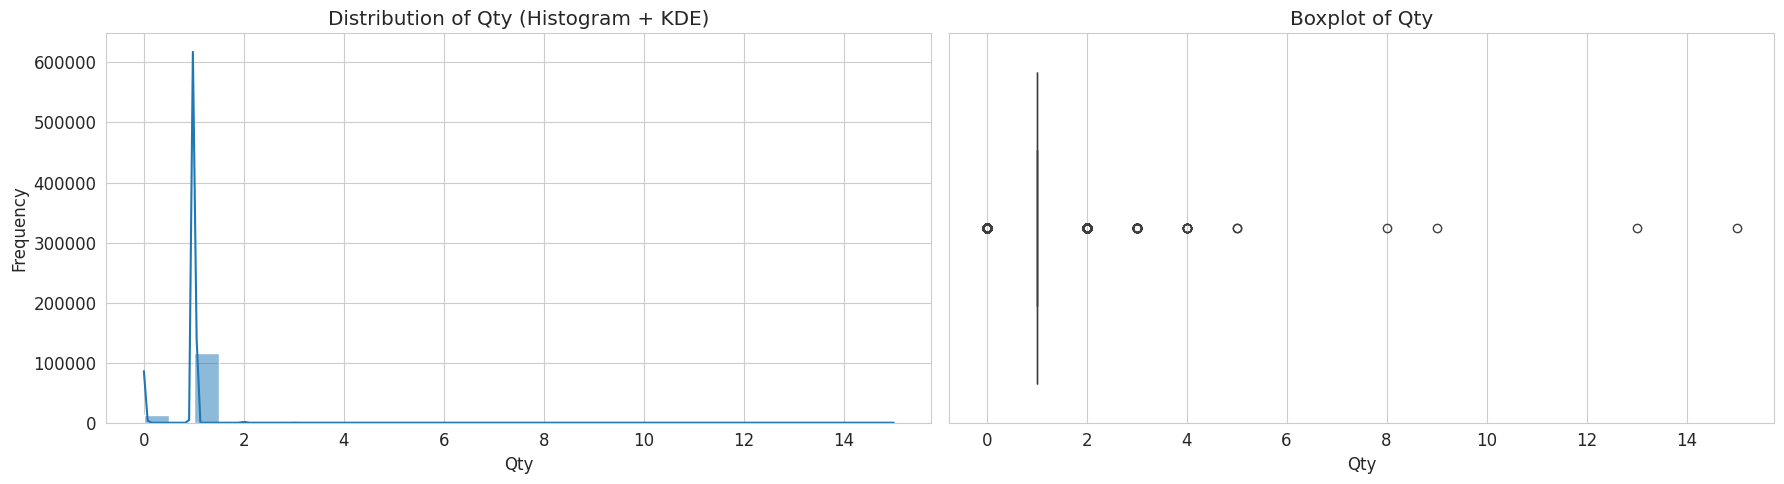


--- Analyzing: Revenue_per_Unit ---
Mean: 582.60
Median: 568.00
Standard Deviation: 328.06
Skewness: 0.22
Kurtosis: 0.26


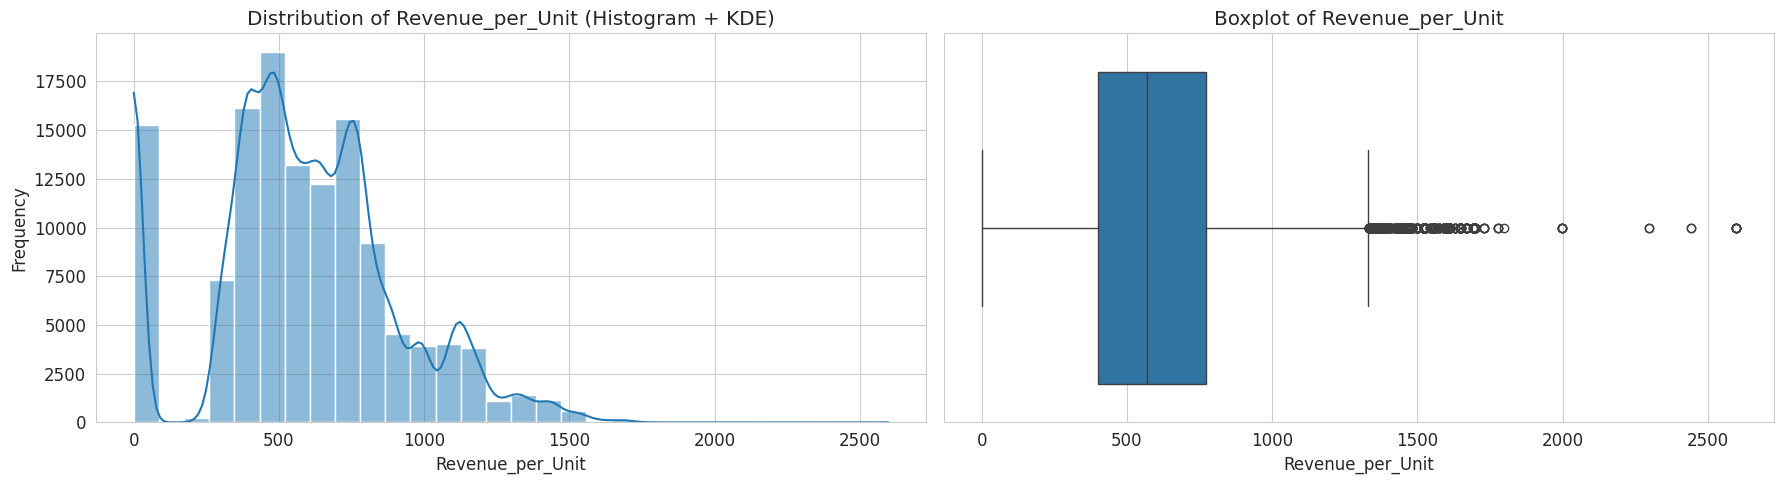

In [ ]:
print("### 4.3 Univariate Analysis (Numerical Variables)")

# Define the numerical variables for analysis
numerical_vars = ['Amount', 'Qty', 'Revenue_per_Unit']

# Ensure df_features is available
if 'df_features' not in locals() or df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame not found or is empty. Cannot perform univariate analysis.")

for col in numerical_vars:
    print(f"\n--- Analyzing: {col} ---")

    if col not in df_features.columns:
        print(f"Warning: Column '{col}' not found in df_features. Skipping analysis for this column.")
        continue

    # Convert to numeric, coercing errors to NaN
    df_features[col] = pd.to_numeric(df_features[col], errors='coerce')

    # Drop rows with NaN values for the current column for accurate statistics
    # We create a temporary series for this analysis to avoid modifying the original df_features
    series_to_analyze = df_features[col].dropna()

    if series_to_analyze.empty:
        print(f"Warning: Column '{col}' has no valid observations after dropping NaNs. Skipping analysis.")
        continue

    # --- Display Statistical Summary ---
    mean_val = series_to_analyze.mean()
    median_val = series_to_analyze.median()
    std_val = series_to_analyze.std()
    skew_val = series_to_analyze.skew()
    kurt_val = series_to_analyze.kurt()

    print(f"Mean: {mean_val:,.2f}")
    print(f"Median: {median_val:,.2f}")
    print(f"Standard Deviation: {std_val:,.2f}")
    print(f"Skewness: {skew_val:,.2f}")
    print(f"Kurtosis: {kurt_val:,.2f}")

    # --- Visualizations ---
    plt.figure(figsize=(18, 5)) # Adjusted figure size for better readability

    # Histogram and KDE Plot
    plt.subplot(1, 2, 1)
    sns.histplot(series_to_analyze, kde=True, bins=30)
    plt.title(f'Distribution of {col} (Histogram + KDE)')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=series_to_analyze)
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

### 4.4 Univariate Analysis (Categorical Variables)

**Purpose**

Analyze frequency distributions of categorical variables.

**Variables**

- Category
- Category_Group
- Size
- Fulfilment
- Sales Channel
- Status
- B2B
- Region

**Visualizations**

- Count Plot
- Horizontal Bar Chart
- Percentage Distribution

**Business Value**

- Identify best-selling categories
- Understand fulfillment mix
- Analyze sales channels

**Error Handling**

- Show only the Top 10 categories for - - high-cardinality columns.
- Handle missing values appropriately.

### Analyzing: B2B

--- Value Counts for B2B ---
B2B
False    128104
True        871
Name: count, dtype: int64

--- Value Percentages (%) for B2B ---
B2B
False    99.32
True      0.68
Name: proportion, dtype: float64


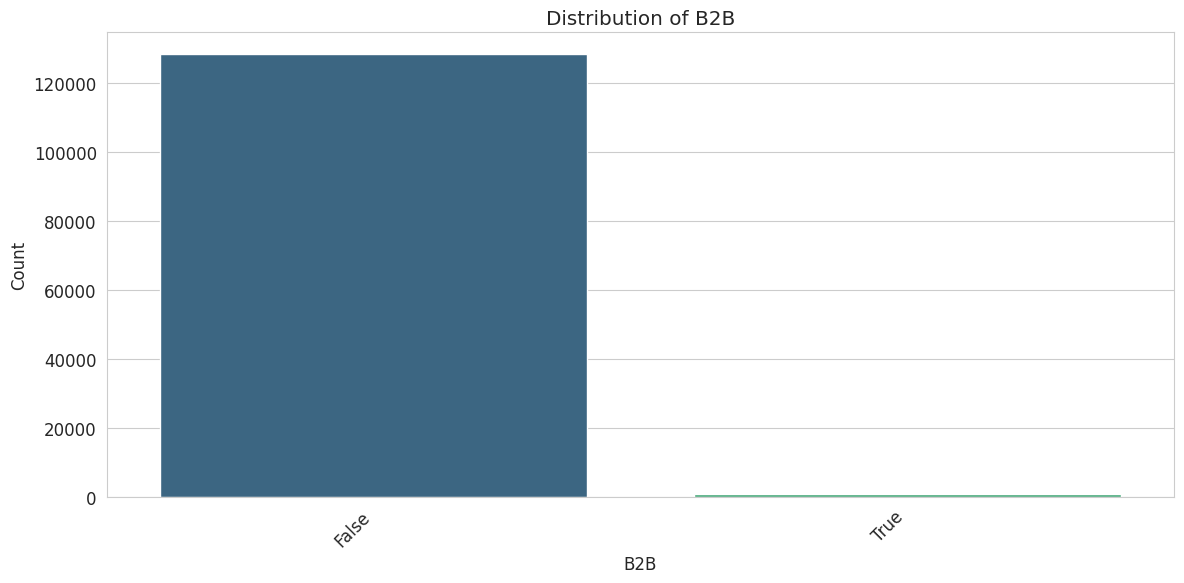

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the categorical variable for this analysis
col = 'B2B'

print(f"### Analyzing: {col}")

# Ensure df_features is available
if 'df_features' not in locals() or df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame not found or is empty. Cannot perform univariate analysis.")

if col not in df_features.columns:
    print(f"Warning: Column '{col}' not found in df_features. Skipping analysis for this column.")
elif df_features[col].isnull().all():
    print(f"Warning: Column '{col}' contains all missing values. Skipping analysis.")
else:
    # Drop rows with NaN values for the current column for accurate counts
    series_to_analyze = df_features[col].dropna()

    if series_to_analyze.empty:
        print(f"Warning: Column '{col}' has no valid observations after dropping NaNs. Skipping analysis.")
    else:
        # Calculate value counts and percentages
        value_counts = series_to_analyze.value_counts()
        value_percentages = series_to_analyze.value_counts(normalize=True) * 100

        # For 'B2B', all categories will be displayed as it has low cardinality.
        print(f"\n--- Value Counts for {col} ---")
        print(value_counts)
        print(f"\n--- Value Percentages (%) for {col} ---")
        print(value_percentages.round(2))
        plot_data = value_counts

        # Visualization: Bar Plot
        plt.figure(figsize=(12, 6))
        sns.barplot(x=plot_data.index.astype(str), y=plot_data.values, palette='viridis') # Convert index to string for plotting
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

### Analyzing: Region

--- Value Counts for Region ---
Region
South         52504
West          30597
North         27313
East          12578
North-East     2949
Central        2529
Other           505
Name: count, dtype: int64

--- Value Percentages (%) for Region ---
Region
South         40.71
West          23.72
North         21.18
East           9.75
North-East     2.29
Central        1.96
Other          0.39
Name: proportion, dtype: float64


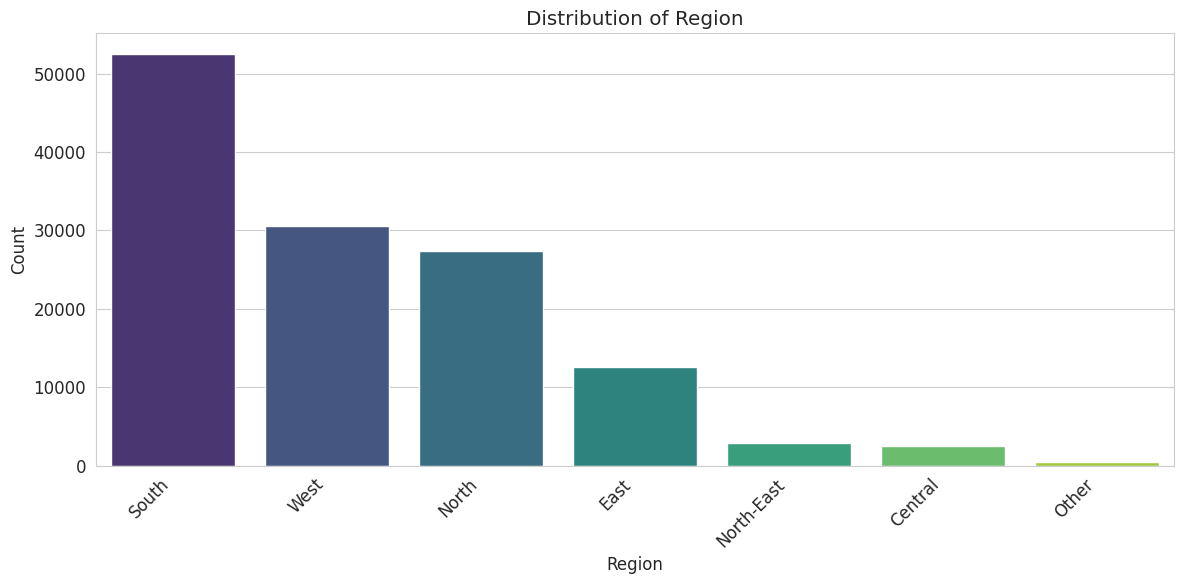

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the categorical variable for this analysis
col = 'Region'

print(f"### Analyzing: {col}")

# Ensure df_features is available
if 'df_features' not in locals() or df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame not found or is empty. Cannot perform univariate analysis.")

if col not in df_features.columns:
    print(f"Warning: Column '{col}' not found in df_features. Skipping analysis for this column.")
elif df_features[col].isnull().all():
    print(f"Warning: Column '{col}' contains all missing values. Skipping analysis.")
else:
    # Drop rows with NaN values for the current column for accurate counts
    series_to_analyze = df_features[col].dropna()

    if series_to_analyze.empty:
        print(f"Warning: Column '{col}' has no valid observations after dropping NaNs. Skipping analysis.")
    else:
        # Calculate value counts and percentages
        value_counts = series_to_analyze.value_counts()
        value_percentages = series_to_analyze.value_counts(normalize=True) * 100

        # Determine if we need to show only top 10
        display_top_n = 10
        if len(value_counts) > display_top_n:
            print(f"\n--- Top {display_top_n} Value Counts for {col} ---")
            print(value_counts.head(display_top_n))
            print(f"\n--- Top {display_top_n} Value Percentages (%) for {col} ---")
            print(value_percentages.head(display_top_n).round(2))
            plot_data = value_counts.head(display_top_n)
        else:
            print(f"\n--- Value Counts for {col} ---")
            print(value_counts)
            print(f"\n--- Value Percentages (%) for {col} ---")
            print(value_percentages.round(2))
            plot_data = value_counts

        # Visualization: Bar Plot
        plt.figure(figsize=(12, 6))
        sns.barplot(x=plot_data.index.astype(str), y=plot_data.values, palette='viridis')
        plt.title(f'Distribution of {col}' + (f' (Top {display_top_n})' if len(value_counts) > display_top_n else ''))
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

### Analyzing: Category_Group

--- Value Counts for Category_Group ---
Category_Group
Set              50284
Kurta            49877
Western Dress    15500
Top              10622
Ethnic Dress      1159
Blouse             926
Bottom             440
Saree              164
Dupatta              3
Name: count, dtype: int64

--- Value Percentages (%) for Category_Group ---
Category_Group
Set              38.99
Kurta            38.67
Western Dress    12.02
Top               8.24
Ethnic Dress      0.90
Blouse            0.72
Bottom            0.34
Saree             0.13
Dupatta           0.00
Name: proportion, dtype: float64


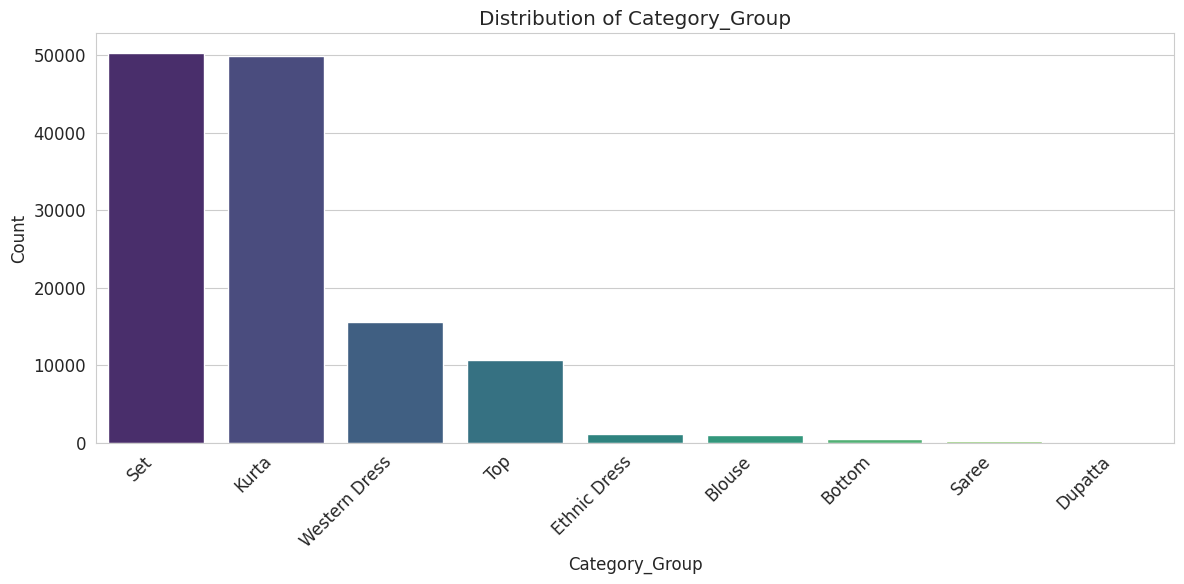

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the categorical variable for this analysis
col = 'Category_Group'

print(f"### Analyzing: {col}")

# Ensure df_features is available
if 'df_features' not in locals() or df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame not found or is empty. Cannot perform univariate analysis.")

if col not in df_features.columns:
    print(f"Warning: Column '{col}' not found in df_features. Skipping analysis for this column.")
elif df_features[col].isnull().all():
    print(f"Warning: Column '{col}' contains all missing values. Skipping analysis.")
else:
    # Drop rows with NaN values for the current column for accurate counts
    series_to_analyze = df_features[col].dropna()

    if series_to_analyze.empty:
        print(f"Warning: Column '{col}' has no valid observations after dropping NaNs. Skipping analysis.")
    else:
        # Calculate value counts and percentages
        value_counts = series_to_analyze.value_counts()
        value_percentages = series_to_analyze.value_counts(normalize=True) * 100

        # Determine if we need to show only top 10
        display_top_n = 10
        if len(value_counts) > display_top_n:
            print(f"\n--- Top {display_top_n} Value Counts for {col} ---")
            print(value_counts.head(display_top_n))
            print(f"\n--- Top {display_top_n} Value Percentages (%) for {col} ---")
            print(value_percentages.head(display_top_n).round(2))
            plot_data = value_counts.head(display_top_n)
        else:
            print(f"\n--- Value Counts for {col} ---")
            print(value_counts)
            print(f"\n--- Value Percentages (%) for {col} ---")
            print(value_percentages.round(2))
            plot_data = value_counts

        # Visualization: Bar Plot
        plt.figure(figsize=(12, 6))
        sns.barplot(x=plot_data.index, y=plot_data.values, palette='viridis')
        plt.title(f'Distribution of {col}' + (f' (Top {display_top_n})' if len(value_counts) > display_top_n else ''))
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

### Analyzing: Size

--- Top 10 Value Counts for Size ---
Size
M      22711
L      22132
XL     20876
XXL    18096
S      17090
3XL    14816
XS     11161
6XL      738
5XL      550
4XL      427
Name: count, dtype: int64

--- Top 10 Value Percentages (%) for Size ---
Size
M      17.61
L      17.16
XL     16.19
XXL    14.03
S      13.25
3XL    11.49
XS      8.65
6XL     0.57
5XL     0.43
4XL     0.33
Name: proportion, dtype: float64


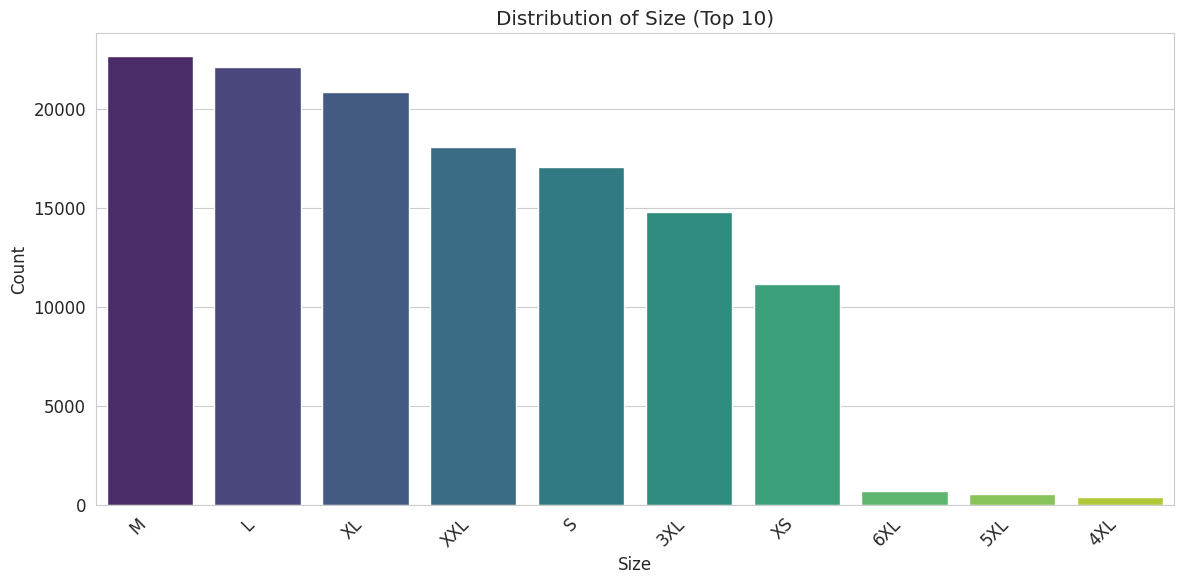

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the categorical variable for this analysis
col = 'Size'

print(f"### Analyzing: {col}")

# Ensure df_features is available
if 'df_features' not in locals() or df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame not found or is empty. Cannot perform univariate analysis.")

if col not in df_features.columns:
    print(f"Warning: Column '{col}' not found in df_features. Skipping analysis for this column.")
elif df_features[col].isnull().all():
    print(f"Warning: Column '{col}' contains all missing values. Skipping analysis.")
else:
    # Drop rows with NaN values for the current column for accurate counts
    series_to_analyze = df_features[col].dropna()

    if series_to_analyze.empty:
        print(f"Warning: Column '{col}' has no valid observations after dropping NaNs. Skipping analysis.")
    else:
        # Calculate value counts and percentages
        value_counts = series_to_analyze.value_counts()
        value_percentages = series_to_analyze.value_counts(normalize=True) * 100

        # Determine if we need to show only top 10 (though 'Size' usually has fewer)
        display_top_n = 10
        if len(value_counts) > display_top_n:
            print(f"\n--- Top {display_top_n} Value Counts for {col} ---")
            print(value_counts.head(display_top_n))
            print(f"\n--- Top {display_top_n} Value Percentages (%) for {col} ---")
            print(value_percentages.head(display_top_n).round(2))
            plot_data = value_counts.head(display_top_n)
        else:
            print(f"\n--- Value Counts for {col} ---")
            print(value_counts)
            print(f"\n--- Value Percentages (%) for {col} ---")
            print(value_percentages.round(2))
            plot_data = value_counts

        # Visualization: Bar Plot
        plt.figure(figsize=(12, 6))
        sns.barplot(x=plot_data.index, y=plot_data.values, palette='viridis')
        plt.title(f'Distribution of {col}' + (f' (Top {display_top_n})' if len(value_counts) > display_top_n else ''))
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

### Analyzing: Fulfilment

--- Value Counts for Fulfilment ---
Fulfilment
Amazon      89698
Merchant    39277
Name: count, dtype: int64

--- Value Percentages (%) for Fulfilment ---
Fulfilment
Amazon      69.55
Merchant    30.45
Name: proportion, dtype: float64


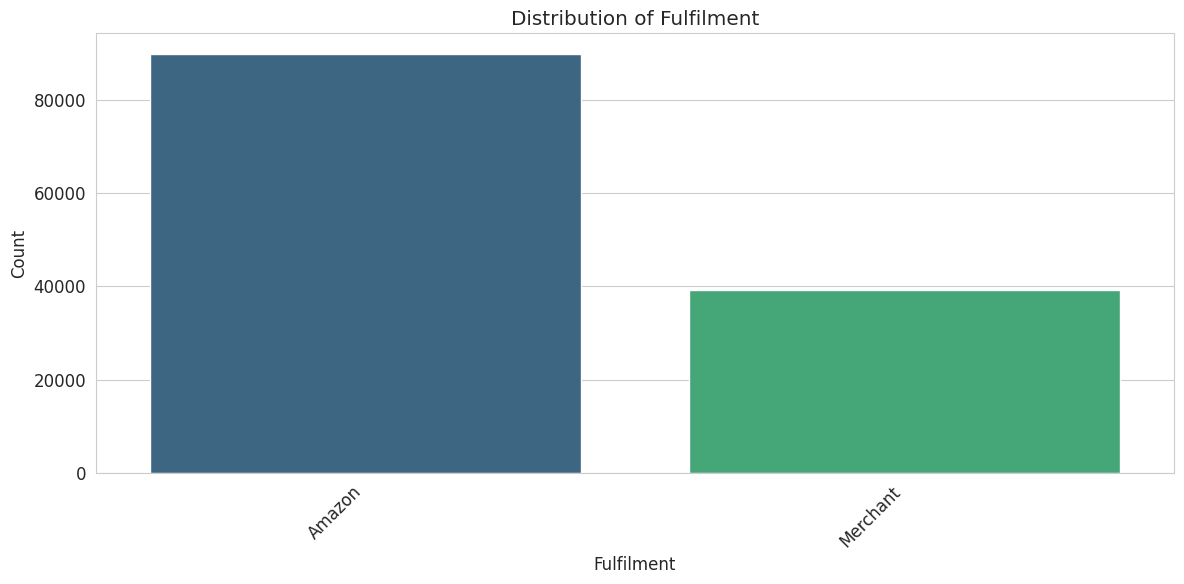

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the categorical variable for this analysis
col = 'Fulfilment'

print(f"### Analyzing: {col}")

# Ensure df_features is available
if 'df_features' not in locals() or df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame not found or is empty. Cannot perform univariate analysis.")

if col not in df_features.columns:
    print(f"Warning: Column '{col}' not found in df_features. Skipping analysis for this column.")
elif df_features[col].isnull().all():
    print(f"Warning: Column '{col}' contains all missing values. Skipping analysis.")
else:
    # Drop rows with NaN values for the current column for accurate counts
    series_to_analyze = df_features[col].dropna()

    if series_to_analyze.empty:
        print(f"Warning: Column '{col}' has no valid observations after dropping NaNs. Skipping analysis.")
    else:
        # Calculate value counts and percentages
        value_counts = series_to_analyze.value_counts()
        value_percentages = series_to_analyze.value_counts(normalize=True) * 100

        # Determine if we need to show only top 10 (Fulfilment is usually low cardinality)
        display_top_n = 10
        if len(value_counts) > display_top_n:
            print(f"\n--- Top {display_top_n} Value Counts for {col} ---")
            print(value_counts.head(display_top_n))
            print(f"\n--- Top {display_top_n} Value Percentages (%) for {col} ---")
            print(value_percentages.head(display_top_n).round(2))
            plot_data = value_counts.head(display_top_n)
        else:
            print(f"\n--- Value Counts for {col} ---")
            print(value_counts)
            print(f"\n--- Value Percentages (%) for {col} ---")
            print(value_percentages.round(2))
            plot_data = value_counts

        # Visualization: Bar Plot
        plt.figure(figsize=(12, 6))
        sns.barplot(x=plot_data.index, y=plot_data.values, palette='viridis')
        plt.title(f'Distribution of {col}' + (f' (Top {display_top_n})' if len(value_counts) > display_top_n else ''))
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

### Analyzing: Sales Channel 

--- Value Counts for Sales Channel  ---
Sales Channel 
Amazon.in     128851
Non-Amazon       124
Name: count, dtype: int64

--- Value Percentages (%) for Sales Channel  ---
Sales Channel 
Amazon.in     99.9
Non-Amazon     0.1
Name: proportion, dtype: float64


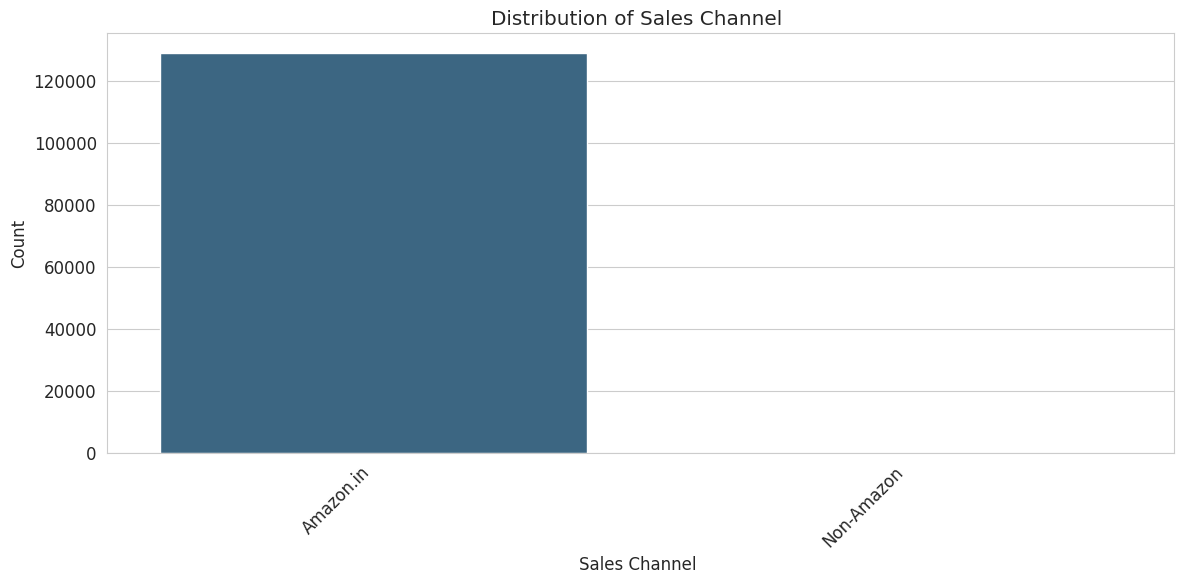

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the categorical variable for this analysis
col = 'Sales Channel '

print(f"### Analyzing: {col}")

# Ensure df_features is available
if 'df_features' not in locals() or df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame not found or is empty. Cannot perform univariate analysis.")

if col not in df_features.columns:
    print(f"Warning: Column '{col}' not found in df_features. Skipping analysis for this column.")
elif df_features[col].isnull().all():
    print(f"Warning: Column '{col}' contains all missing values. Skipping analysis.")
else:
    # Drop rows with NaN values for the current column for accurate counts
    series_to_analyze = df_features[col].dropna()

    if series_to_analyze.empty:
        print(f"Warning: Column '{col}' has no valid observations after dropping NaNs. Skipping analysis.")
    else:
        # Calculate value counts and percentages
        value_counts = series_to_analyze.value_counts()
        value_percentages = series_to_analyze.value_counts(normalize=True) * 100

        # Determine if we need to show only top 10 (Sales Channel is usually low cardinality)
        display_top_n = 10
        if len(value_counts) > display_top_n:
            print(f"\n--- Top {display_top_n} Value Counts for {col} ---")
            print(value_counts.head(display_top_n))
            print(f"\n--- Top {display_top_n} Value Percentages (%) for {col} ---")
            print(value_percentages.head(display_top_n).round(2))
            plot_data = value_counts.head(display_top_n)
        else:
            print(f"\n--- Value Counts for {col} ---")
            print(value_counts)
            print(f"\n--- Value Percentages (%) for {col} ---")
            print(value_percentages.round(2))
            plot_data = value_counts

        # Visualization: Bar Plot
        plt.figure(figsize=(12, 6))
        sns.barplot(x=plot_data.index, y=plot_data.values, palette='viridis')
        plt.title(f'Distribution of {col}' + (f' (Top {display_top_n})' if len(value_counts) > display_top_n else ''))
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

### Analyzing: Status

--- Top 10 Value Counts for Status ---
Status
Shipped                          77804
Shipped - Delivered to Buyer     28769
Cancelled                        18332
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Name: count, dtype: int64

--- Top 10 Value Percentages (%) for Status ---
Status
Shipped                          60.32
Shipped - Delivered to Buyer     22.31
Cancelled                        14.21
Shipped - Returned to Seller      1.51
Shipped - Picked Up               0.75
Pending                           0.51
Pending - Waiting for Pick Up     0.22
Shipped - Returning to Seller     0.11
Shipped - Out for Delivery        0.03
Shipped - Rejected by Buyer       0.01
Name: proportion, dtype: float64


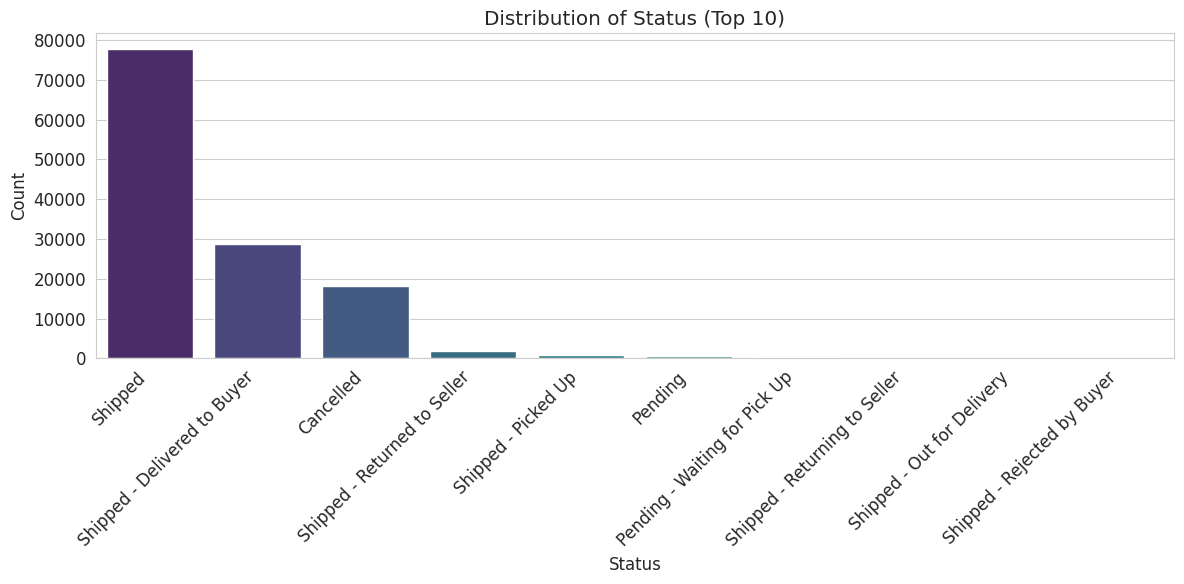

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the categorical variable for this analysis
col = 'Status'

print(f"### Analyzing: {col}")

# Ensure df_features is available
if 'df_features' not in locals() or df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame not found or is empty. Cannot perform univariate analysis.")

if col not in df_features.columns:
    print(f"Warning: Column '{col}' not found in df_features. Skipping analysis for this column.")
elif df_features[col].isnull().all():
    print(f"Warning: Column '{col}' contains all missing values. Skipping analysis.")
else:
    # Drop rows with NaN values for the current column for accurate counts
    series_to_analyze = df_features[col].dropna()

    if series_to_analyze.empty:
        print(f"Warning: Column '{col}' has no valid observations after dropping NaNs. Skipping analysis.")
    else:
        # Calculate value counts and percentages
        value_counts = series_to_analyze.value_counts()
        value_percentages = series_to_analyze.value_counts(normalize=True) * 100

        # Determine if we need to show only top 10
        display_top_n = 10
        if len(value_counts) > display_top_n:
            print(f"\n--- Top {display_top_n} Value Counts for {col} ---")
            print(value_counts.head(display_top_n))
            print(f"\n--- Top {display_top_n} Value Percentages (%) for {col} ---")
            print(value_percentages.head(display_top_n).round(2))
            plot_data = value_counts.head(display_top_n)
        else:
            print(f"\n--- Value Counts for {col} ---")
            print(value_counts)
            print(f"\n--- Value Percentages (%) for {col} ---")
            print(value_percentages.round(2))
            plot_data = value_counts

        # Visualization: Bar Plot
        plt.figure(figsize=(12, 6))
        sns.barplot(x=plot_data.index, y=plot_data.values, palette='viridis')
        plt.title(f'Distribution of {col}' + (f' (Top {display_top_n})' if len(value_counts) > display_top_n else ''))
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

##### 4.5 Sales Performance Analysis

**Purpose**

Evaluate sales across different business dimensions.

- Analysis
- Revenue by Category
- Revenue by Category Group
- Revenue by Size
- Revenue by Fulfilment
- Revenue by Sales Channel
- Revenue by B2B vs B2C

**Visualizations**

- Bar Charts
- Sorted Revenue Charts

**Business Value**

Identify high-performing products and channels.

**Error Handling**

- Exclude missing categories.
- Warn if groups contain too few observations.

### Analyzing: Revenue by Category Group

--- Total Revenue by Category Group ---
Category_Group
Set              ₹39,204,124.03
Kurta            ₹21,299,546.70
Western Dress    ₹11,216,072.69
Top               ₹5,347,792.30
Ethnic Dress        ₹791,217.66
Blouse              ₹458,408.18
Bottom              ₹150,667.98
Saree               ₹123,933.76
Dupatta                 ₹915.00
Name: Amount, dtype: object


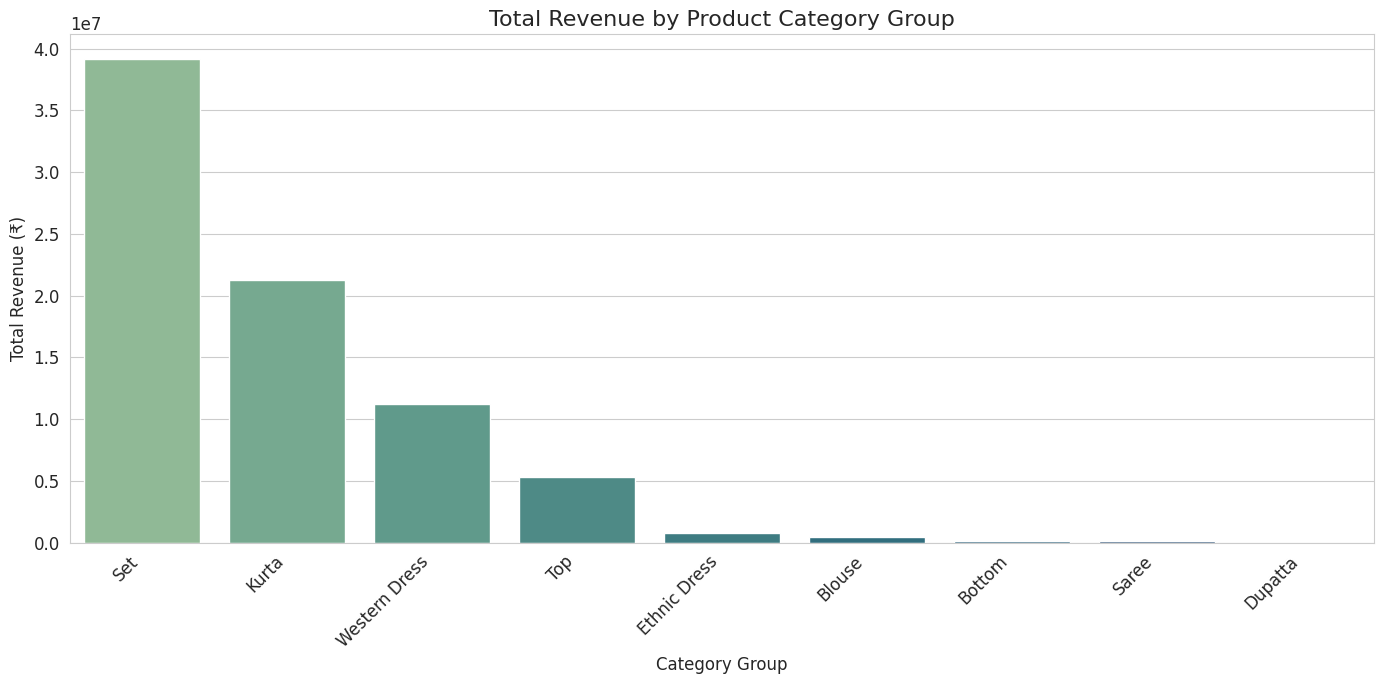

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("### Analyzing: Revenue by Category Group")

# Ensure df_features is available
if 'df_features' not in locals() or df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame not found or is empty. Cannot perform sales performance analysis.")

required_cols = ['Category_Group', 'Amount']
for col in required_cols:
    if col not in df_features.columns:
        print(f"Warning: Column '{col}' not found in df_features. Skipping analysis.")
        # Exit early if a required column is missing
        exit()

# Exclude missing categories (if any exist, though already handled in feature engineering)
df_sales_category = df_features.dropna(subset=['Category_Group', 'Amount']).copy()

# Calculate total revenue by Category_Group
revenue_by_category = df_sales_category.groupby('Category_Group')['Amount'].sum().sort_values(ascending=False)

print("\n--- Total Revenue by Category Group ---")
print(revenue_by_category.apply(lambda x: f'₹{x:,.2f}'))

# Visualization: Bar Chart of Revenue by Category_Group
plt.figure(figsize=(14, 7))
sns.barplot(x=revenue_by_category.index, y=revenue_by_category.values, palette='crest')
plt.title('Total Revenue by Product Category Group', fontsize=16)
plt.xlabel('Category Group', fontsize=12)
plt.ylabel('Total Revenue (₹)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Analyzing: Revenue by Size

--- Total Revenue by Size ---
Size
M       ₹13,906,754.37
L       ₹13,234,886.19
XL      ₹12,464,965.86
XXL     ₹10,636,288.45
S       ₹10,629,210.18
3XL      ₹9,157,147.68
XS       ₹7,022,375.20
6XL        ₹576,249.33
5XL        ₹425,156.63
4XL        ₹334,451.64
Free       ₹205,192.77
Name: Amount, dtype: object


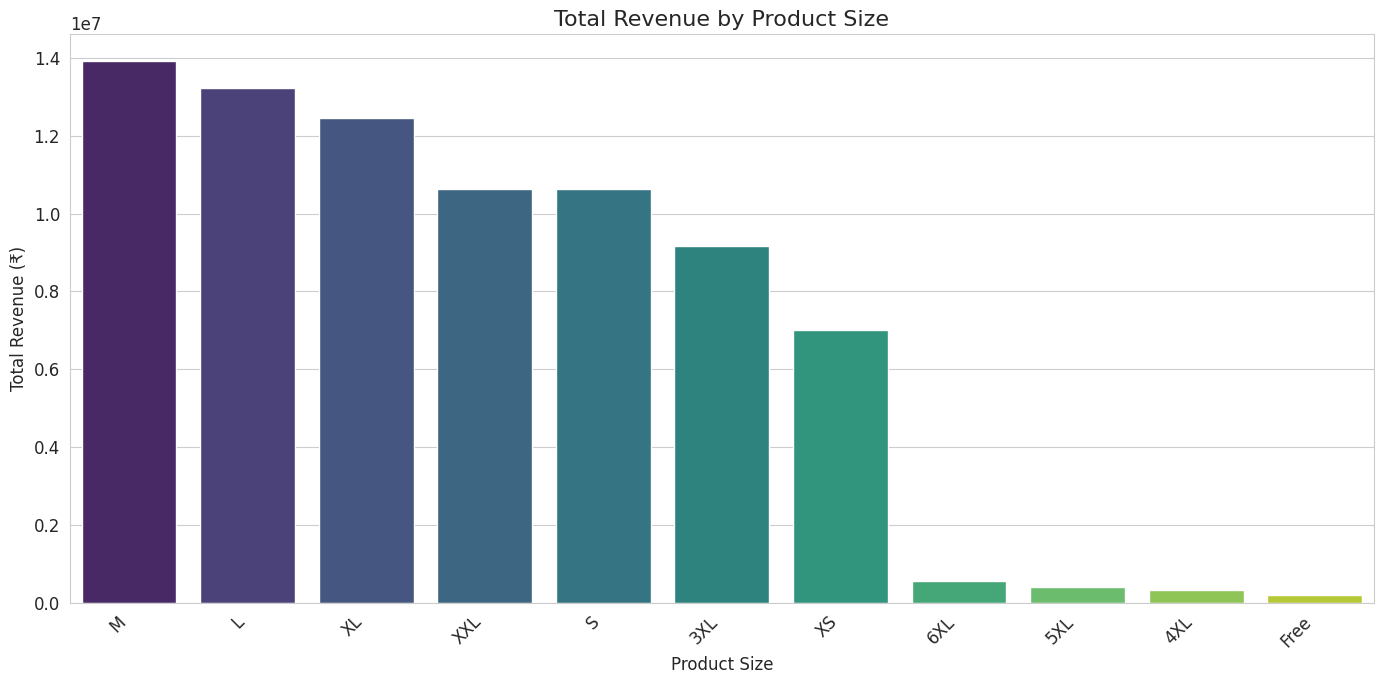

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("### Analyzing: Revenue by Size")

# Ensure df_features is available
if 'df_features' not in locals() or df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame not found or is empty. Cannot perform sales performance analysis.")

required_cols = ['Size', 'Amount']
for col in required_cols:
    if col not in df_features.columns:
        print(f"Warning: Column '{col}' not found in df_features. Skipping analysis.")
        # Exit early if a required column is missing
        exit()

# Exclude missing Size or Amount values
df_sales_size = df_features.dropna(subset=['Size', 'Amount']).copy()

# Calculate total revenue by Size
revenue_by_size = df_sales_size.groupby('Size')['Amount'].sum().sort_values(ascending=False)

print("\n--- Total Revenue by Size ---")
print(revenue_by_size.apply(lambda x: f'₹{x:,.2f}'))

# Visualization: Bar Chart of Revenue by Size
plt.figure(figsize=(14, 7))
sns.barplot(x=revenue_by_size.index, y=revenue_by_size.values, palette='viridis')
plt.title('Total Revenue by Product Size', fontsize=16)
plt.xlabel('Product Size', fontsize=12)
plt.ylabel('Total Revenue (₹)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Analyzing: Revenue by Fulfilment

--- Total Revenue by Fulfilment ---
Fulfilment
Amazon      ₹54,322,151.00
Merchant    ₹24,270,527.30
Name: Amount, dtype: object


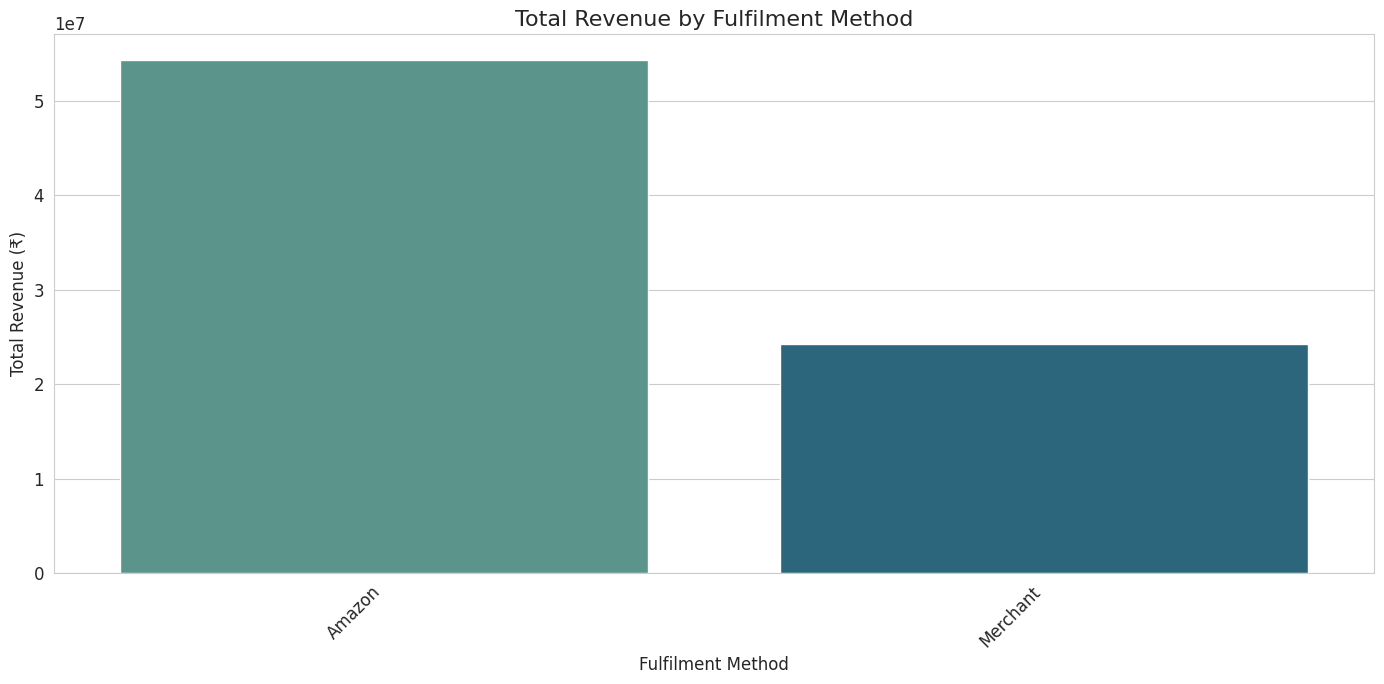

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("### Analyzing: Revenue by Fulfilment")

# Ensure df_features is available
if 'df_features' not in locals() or df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame not found or is empty. Cannot perform sales performance analysis.")

required_cols = ['Fulfilment', 'Amount']
for col in required_cols:
    if col not in df_features.columns:
        print(f"Warning: Column '{col}' not found in df_features. Skipping analysis.")
        # Exit early if a required column is missing
        exit()

# Exclude missing Fulfilment or Amount values
df_sales_fulfilment = df_features.dropna(subset=['Fulfilment', 'Amount']).copy()

# Calculate total revenue by Fulfilment
revenue_by_fulfilment = df_sales_fulfilment.groupby('Fulfilment')['Amount'].sum().sort_values(ascending=False)

print("\n--- Total Revenue by Fulfilment ---")
print(revenue_by_fulfilment.apply(lambda x: f'₹{x:,.2f}'))

# Visualization: Bar Chart of Revenue by Fulfilment
plt.figure(figsize=(14, 7))
sns.barplot(x=revenue_by_fulfilment.index, y=revenue_by_fulfilment.values, palette='crest')
plt.title('Total Revenue by Fulfilment Method', fontsize=16)
plt.xlabel('Fulfilment Method', fontsize=12)
plt.ylabel('Total Revenue (₹)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Analyzing: Revenue by Sales Channel

--- Total Revenue by Sales Channel ---
Sales Channel 
Amazon.in     ₹78,592,678.30
Non-Amazon             ₹0.00
Name: Amount, dtype: object


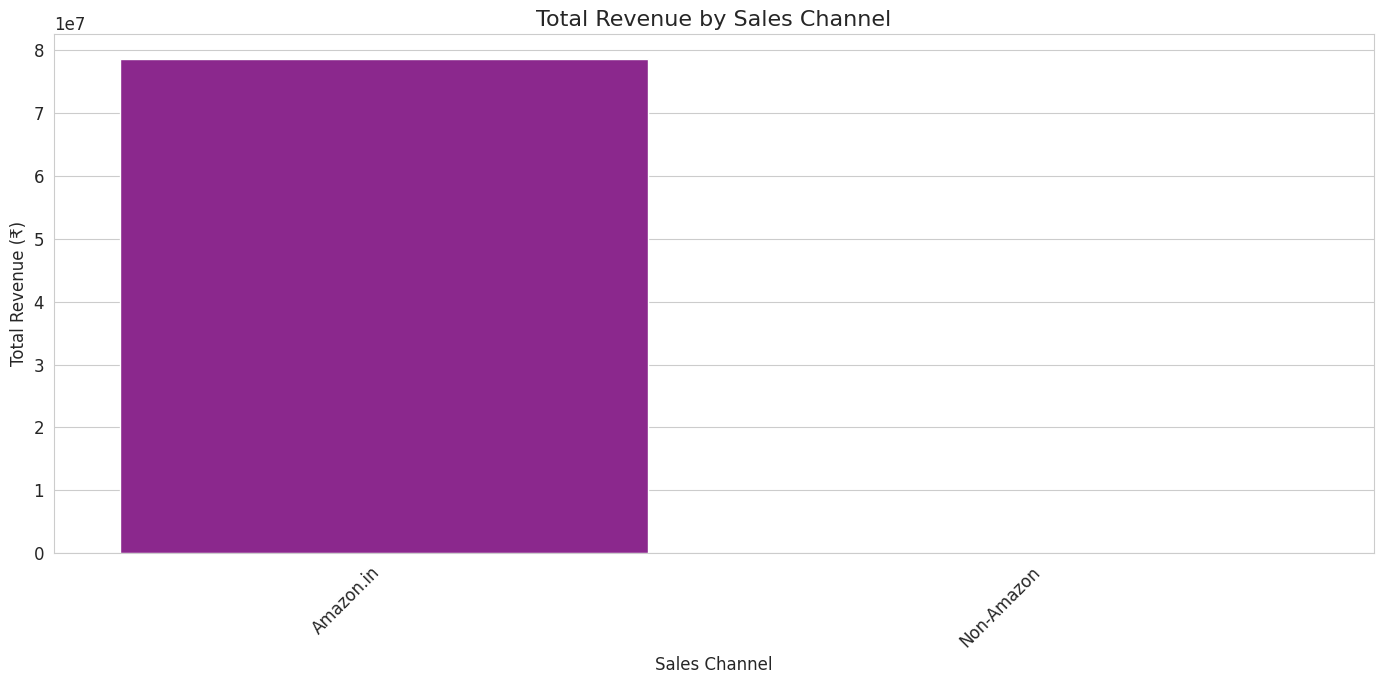

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("### Analyzing: Revenue by Sales Channel")

# Ensure df_features is available
if 'df_features' not in locals() or df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame not found or is empty. Cannot perform sales performance analysis.")

required_cols = ['Sales Channel ', 'Amount'] # Note the space in 'Sales Channel '
for col in required_cols:
    if col not in df_features.columns:
        print(f"Warning: Column '{col}' not found in df_features. Skipping analysis.")
        # Exit early if a required column is missing
        exit()

# Exclude missing Sales Channel or Amount values
df_sales_channel = df_features.dropna(subset=['Sales Channel ', 'Amount']).copy()

# Calculate total revenue by Sales Channel
revenue_by_sales_channel = df_sales_channel.groupby('Sales Channel ')['Amount'].sum().sort_values(ascending=False)

print("\n--- Total Revenue by Sales Channel ---")
print(revenue_by_sales_channel.apply(lambda x: f'₹{x:,.2f}'))

# Visualization: Bar Chart of Revenue by Sales Channel
plt.figure(figsize=(14, 7))
sns.barplot(x=revenue_by_sales_channel.index, y=revenue_by_sales_channel.values, palette='plasma')
plt.title('Total Revenue by Sales Channel', fontsize=16)
plt.xlabel('Sales Channel', fontsize=12)
plt.ylabel('Total Revenue (₹)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Analyzing: Revenue by B2B vs B2C

--- Total Revenue by B2B vs B2C ---
B2B_Type
B2C    ₹78,001,457.51
B2B       ₹591,220.79
Name: Amount, dtype: object


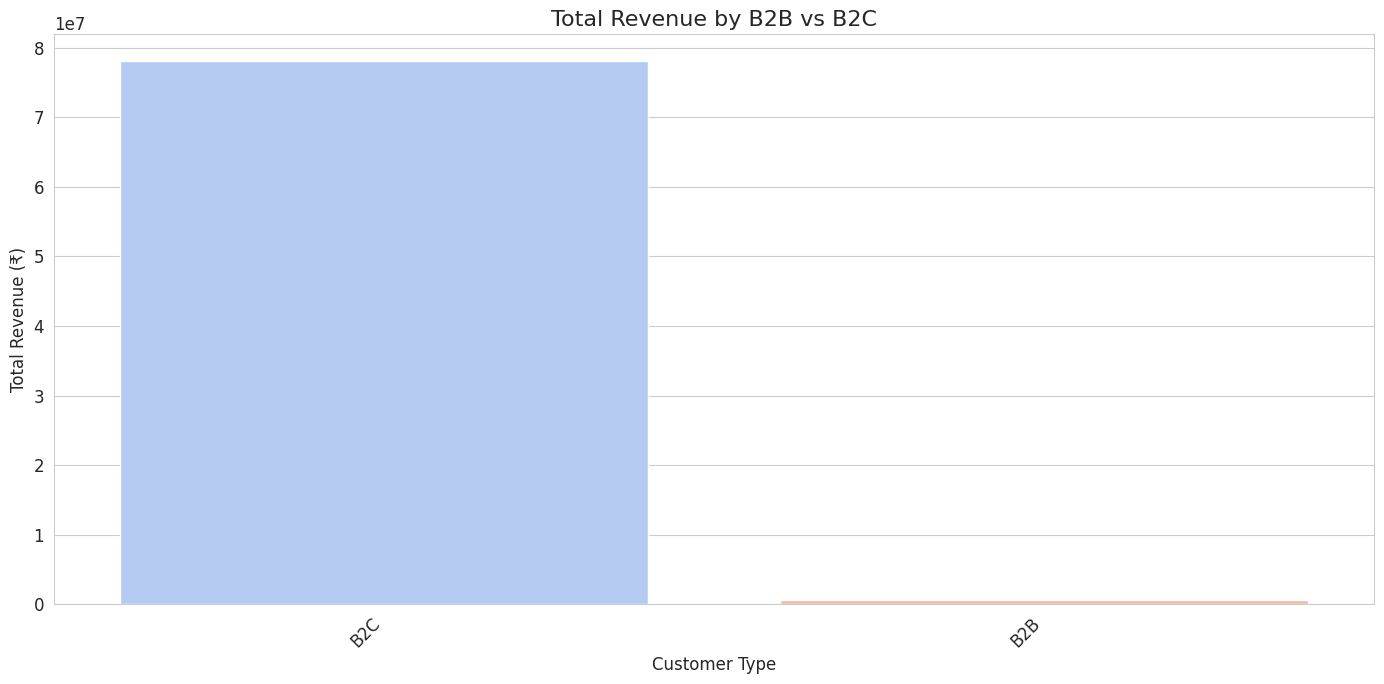

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("### Analyzing: Revenue by B2B vs B2C")

# Ensure df_features is available
if 'df_features' not in locals() or df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame not found or is empty. Cannot perform sales performance analysis.")

required_cols = ['B2B', 'Amount']
for col in required_cols:
    if col not in df_features.columns:
        print(f"Warning: Column '{col}' not found in df_features. Skipping analysis.")
        # Exit early if a required column is missing
        exit()

# Exclude missing B2B or Amount values
df_sales_b2b = df_features.dropna(subset=['B2B', 'Amount']).copy()

# Convert B2B to a more descriptive string for plotting
df_sales_b2b['B2B_Type'] = df_sales_b2b['B2B'].apply(lambda x: 'B2B' if x else 'B2C')

# Calculate total revenue by B2B_Type
revenue_by_b2b_type = df_sales_b2b.groupby('B2B_Type')['Amount'].sum().sort_values(ascending=False)

print("\n--- Total Revenue by B2B vs B2C ---")
print(revenue_by_b2b_type.apply(lambda x: f'₹{x:,.2f}'))

# Visualization: Bar Chart of Revenue by B2B_Type
plt.figure(figsize=(14, 7))
sns.barplot(x=revenue_by_b2b_type.index, y=revenue_by_b2b_type.values, palette='coolwarm')
plt.title('Total Revenue by B2B vs B2C', fontsize=16)
plt.xlabel('Customer Type', fontsize=12)
plt.ylabel('Total Revenue (₹)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 4.6 Geographic Analysis

**Purpose**

Analyze sales performance across locations.

- Analysis
- Revenue by State
- Orders by State
- Revenue by Region
- Top 10 States
- Bottom 10 States

**Visualizations**

- Horizontal Bar Charts
- Region Comparison Charts
- (Optional) India Choropleth Map

**Business Value**

- Identify strong and weak markets.
- Support regional marketing strategies.

**Error Handling**

- Standardize inconsistent state names.
- Skip map if geographic libraries are unavailable.

### Analyzing: Revenue by State

--- Total Revenue by State ---
ship-state
MAHARASHTRA      ₹13,335,534.14
KARNATAKA        ₹10,481,114.37
TELANGANA         ₹6,916,615.65
UTTAR PRADESH     ₹6,816,642.08
TAMIL NADU        ₹6,515,650.11
                      ...      
rajsthan                ₹521.00
AR                      ₹493.00
Rajsthan                ₹443.00
PB                      ₹399.00
APO                       ₹0.00
Name: Amount, Length: 69, dtype: object


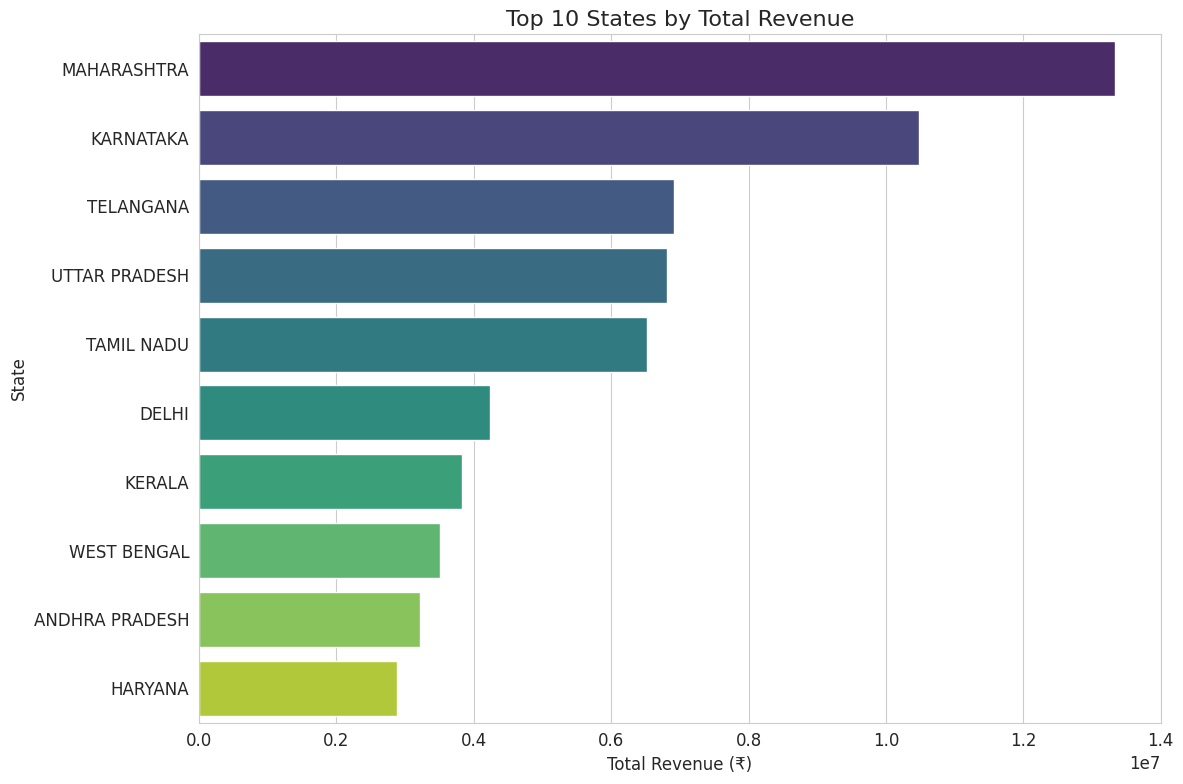

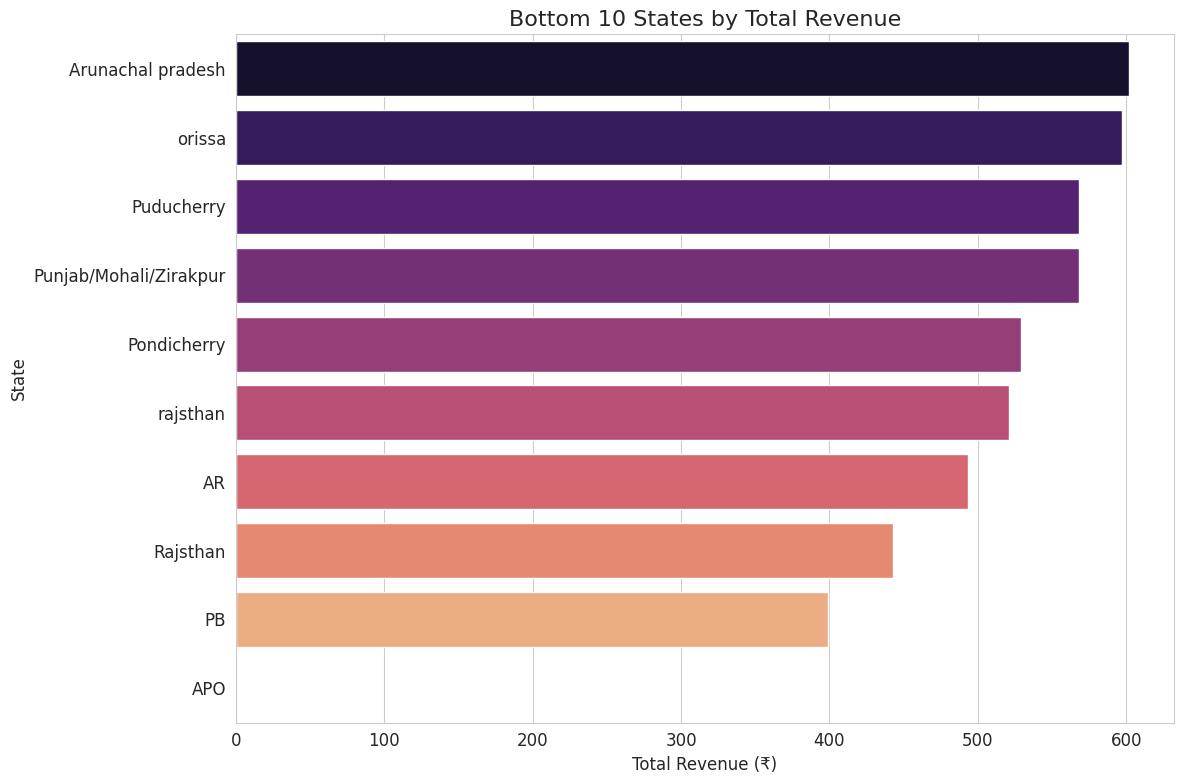

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("### Analyzing: Revenue by State")

# Ensure df_features is available
if 'df_features' not in locals() or df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame not found or is empty. Cannot perform geographic analysis.")

required_cols = ['ship-state', 'Amount']
for col in required_cols:
    if col not in df_features.columns:
        print(f"Warning: Column '{col}' not found in df_features. Skipping analysis.")
        # Exit early if a required column is missing
        exit()

# Exclude missing ship-state or Amount values and 'Unknown' states
df_state_revenue = df_features.dropna(subset=['ship-state', 'Amount']).copy()
df_state_revenue = df_state_revenue[df_state_revenue['ship-state'] != 'Unknown']

if df_state_revenue.empty:
    print("No valid state data for revenue analysis after cleaning. Skipping.")
else:
    # Calculate total revenue by state
    revenue_by_state = df_state_revenue.groupby('ship-state')['Amount'].sum().sort_values(ascending=False)

    print("\n--- Total Revenue by State ---")
    print(revenue_by_state.apply(lambda x: f'₹{x:,.2f}'))

    # Visualization: Horizontal Bar Chart for Top 10 States
    plt.figure(figsize=(12, 8))
    sns.barplot(x=revenue_by_state.head(10).values, y=revenue_by_state.head(10).index, palette='viridis')
    plt.title('Top 10 States by Total Revenue', fontsize=16)
    plt.xlabel('Total Revenue (₹)', fontsize=12)
    plt.ylabel('State', fontsize=12)
    plt.tight_layout()
    plt.show()

    # Visualization: Horizontal Bar Chart for Bottom 10 States
    if len(revenue_by_state) > 10:
        plt.figure(figsize=(12, 8))
        sns.barplot(x=revenue_by_state.tail(10).values, y=revenue_by_state.tail(10).index, palette='magma')
        plt.title('Bottom 10 States by Total Revenue', fontsize=16)
        plt.xlabel('Total Revenue (₹)', fontsize=12)
        plt.ylabel('State', fontsize=12)
        plt.tight_layout()
        plt.show()

### Analyzing: Orders by State

--- Total Unique Orders by State ---
ship-state
MAHARASHTRA      20,780 orders
KARNATAKA        16,182 orders
TAMIL NADU       10,519 orders
TELANGANA        10,405 orders
UTTAR PRADESH    10,062 orders
                     ...      
PB                    1 orders
Rajsthan              1 orders
bihar                 1 orders
orissa                1 orders
rajsthan              1 orders
Name: Order ID, Length: 69, dtype: object


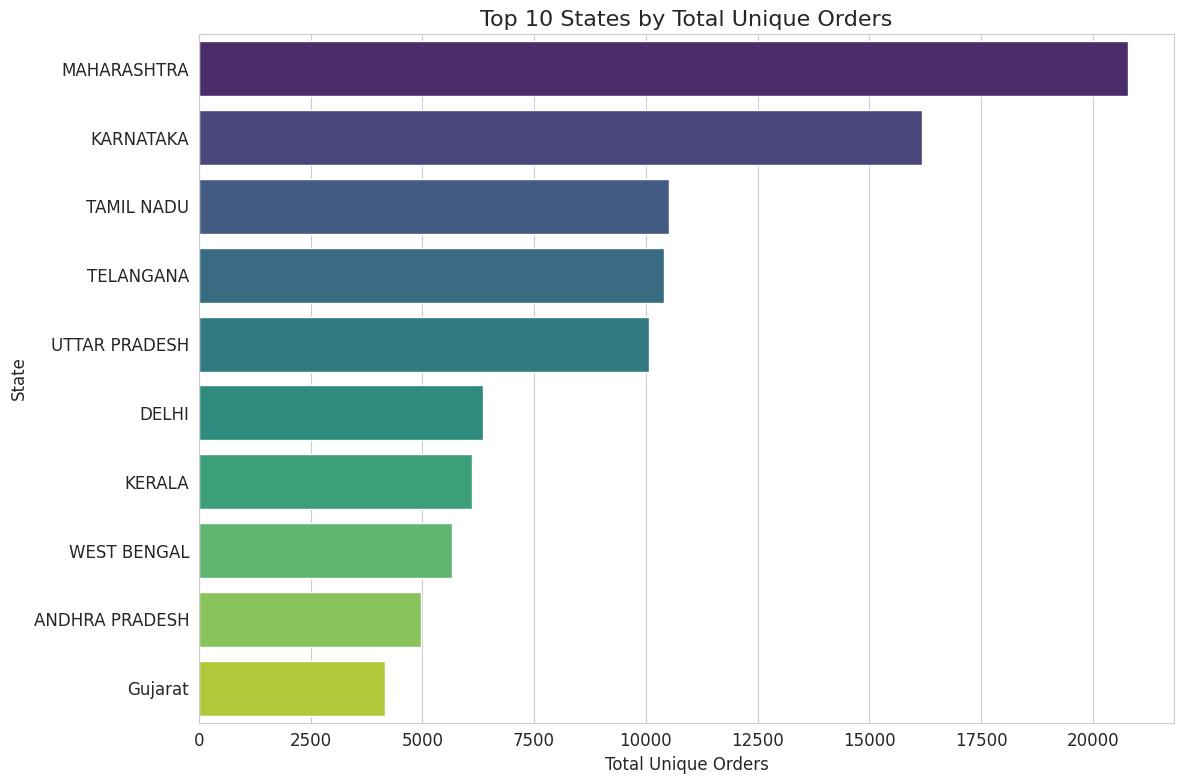

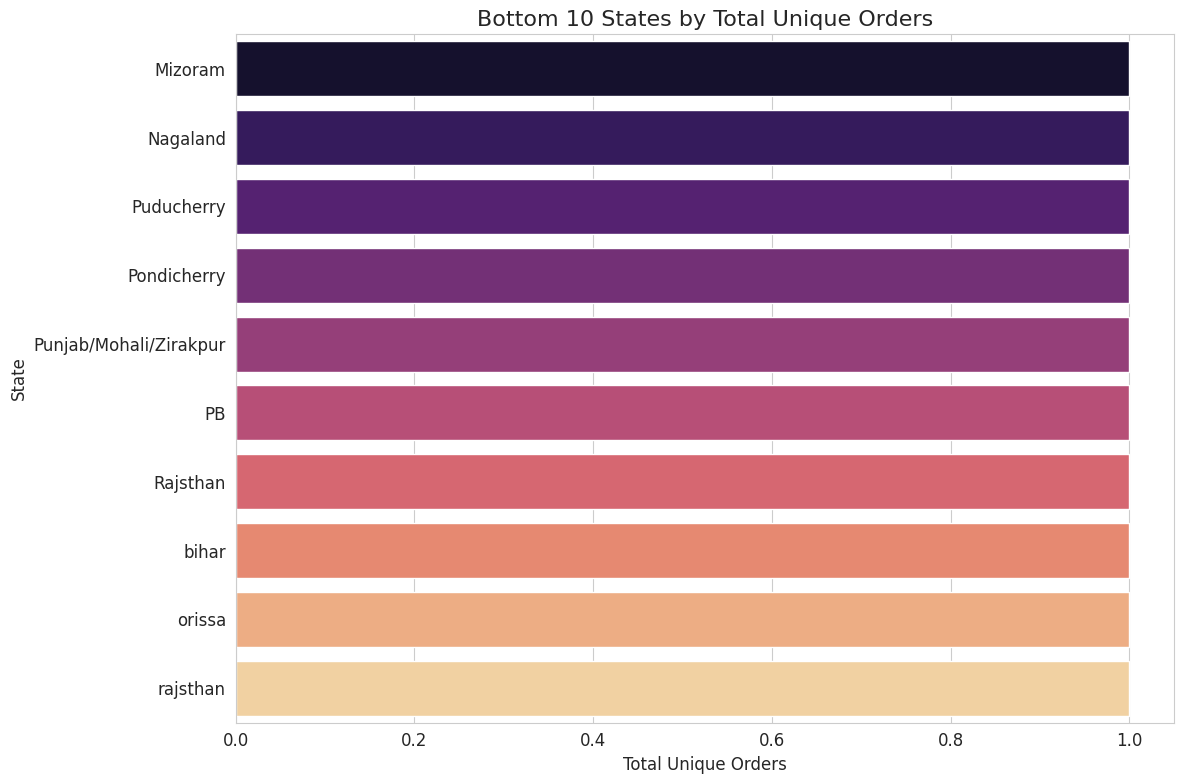

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("### Analyzing: Orders by State")

# Ensure df_features is available
if 'df_features' not in locals() or df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame not found or is empty. Cannot perform geographic analysis.")

required_cols = ['ship-state', 'Order ID']
for col in required_cols:
    if col not in df_features.columns:
        print(f"Warning: Column '{col}' not found in df_features. Skipping analysis.")
        # Exit early if a required column is missing
        exit()

# Exclude missing ship-state values and 'Unknown' states
df_state_orders = df_features.dropna(subset=['ship-state', 'Order ID']).copy()
df_state_orders = df_state_orders[df_state_orders['ship-state'] != 'Unknown']

if df_state_orders.empty:
    print("No valid state data for order analysis after cleaning. Skipping.")
else:
    # Calculate total unique orders by state
    orders_by_state = df_state_orders.groupby('ship-state')['Order ID'].nunique().sort_values(ascending=False)

    print("\n--- Total Unique Orders by State ---")
    print(orders_by_state.apply(lambda x: f'{x:,} orders'))

    # Visualization: Horizontal Bar Chart for Top 10 States by Orders
    plt.figure(figsize=(12, 8))
    sns.barplot(x=orders_by_state.head(10).values, y=orders_by_state.head(10).index, palette='viridis')
    plt.title('Top 10 States by Total Unique Orders', fontsize=16)
    plt.xlabel('Total Unique Orders', fontsize=12)
    plt.ylabel('State', fontsize=12)
    plt.tight_layout()
    plt.show()

    # Visualization: Horizontal Bar Chart for Bottom 10 States by Orders
    if len(orders_by_state) > 10:
        plt.figure(figsize=(12, 8))
        sns.barplot(x=orders_by_state.tail(10).values, y=orders_by_state.tail(10).index, palette='magma')
        plt.title('Bottom 10 States by Total Unique Orders', fontsize=16)
        plt.xlabel('Total Unique Orders', fontsize=12)
        plt.ylabel('State', fontsize=12)
        plt.tight_layout()
        plt.show()

### Analyzing: Revenue by Region

--- Total Revenue by Region ---
Region
South         ₹31,155,483.67
West          ₹18,459,872.97
North         ₹17,402,028.84
East           ₹7,797,703.19
North-East     ₹1,869,182.44
Central        ₹1,592,382.98
Other            ₹316,024.21
Name: Amount, dtype: object


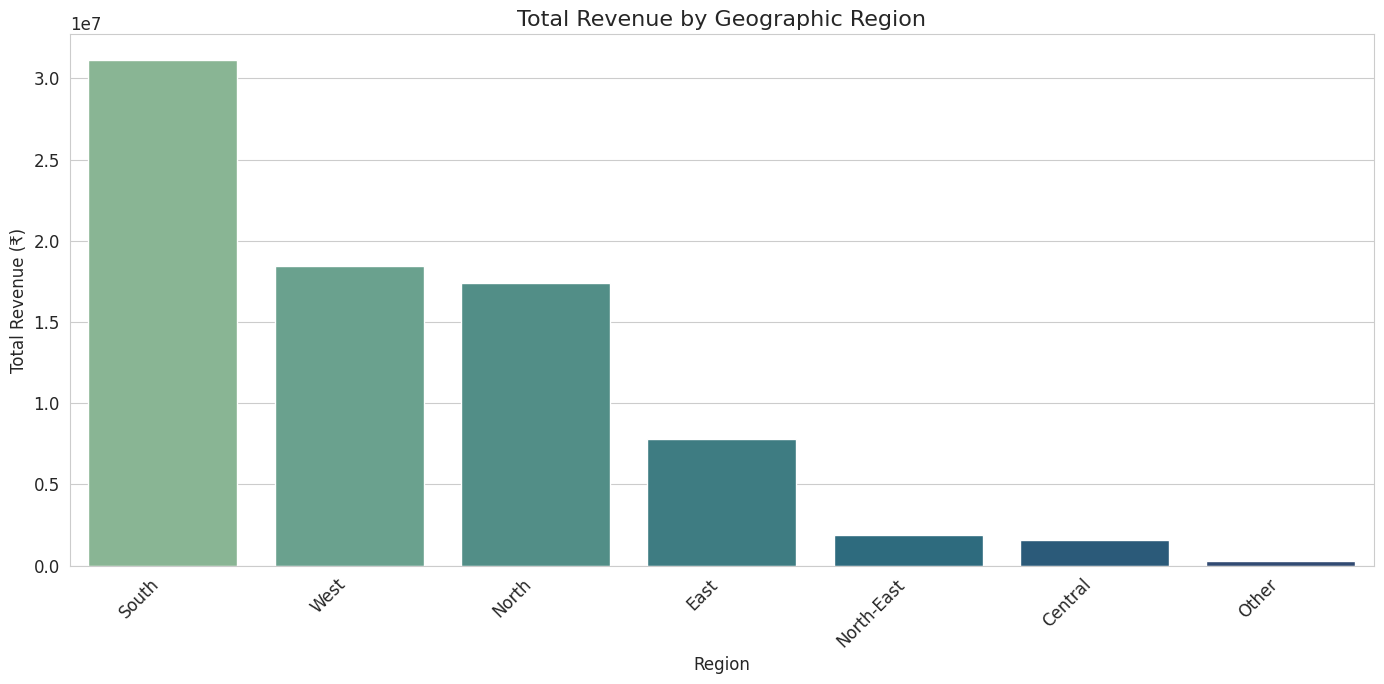

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("### Analyzing: Revenue by Region")

# Ensure df_features is available
if 'df_features' not in locals() or df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame not found or is empty. Cannot perform geographic analysis.")

required_cols = ['Region', 'Amount']
for col in required_cols:
    if col not in df_features.columns:
        print(f"Warning: Column '{col}' not found in df_features. Skipping analysis.")
        # Exit early if a required column is missing
        exit()

# Exclude missing Region or Amount values
df_region_revenue = df_features.dropna(subset=['Region', 'Amount']).copy()

# Calculate total revenue by Region
revenue_by_region = df_region_revenue.groupby('Region')['Amount'].sum().sort_values(ascending=False)

print("\n--- Total Revenue by Region ---")
print(revenue_by_region.apply(lambda x: f'₹{x:,.2f}'))

# Visualization: Bar Chart of Revenue by Region
plt.figure(figsize=(14, 7))
sns.barplot(x=revenue_by_region.index, y=revenue_by_region.values, palette='crest')
plt.title('Total Revenue by Geographic Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Revenue (₹)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Analyzing: Orders by Region

### Analyzing: Orders by Region

--- Total Unique Orders by Region ---
Region
South         48,499 orders
West          28,536 orders
North         25,759 orders
East          11,946 orders
North-East     2,795 orders
Central        2,375 orders
Other            468 orders
Name: Order ID, dtype: object


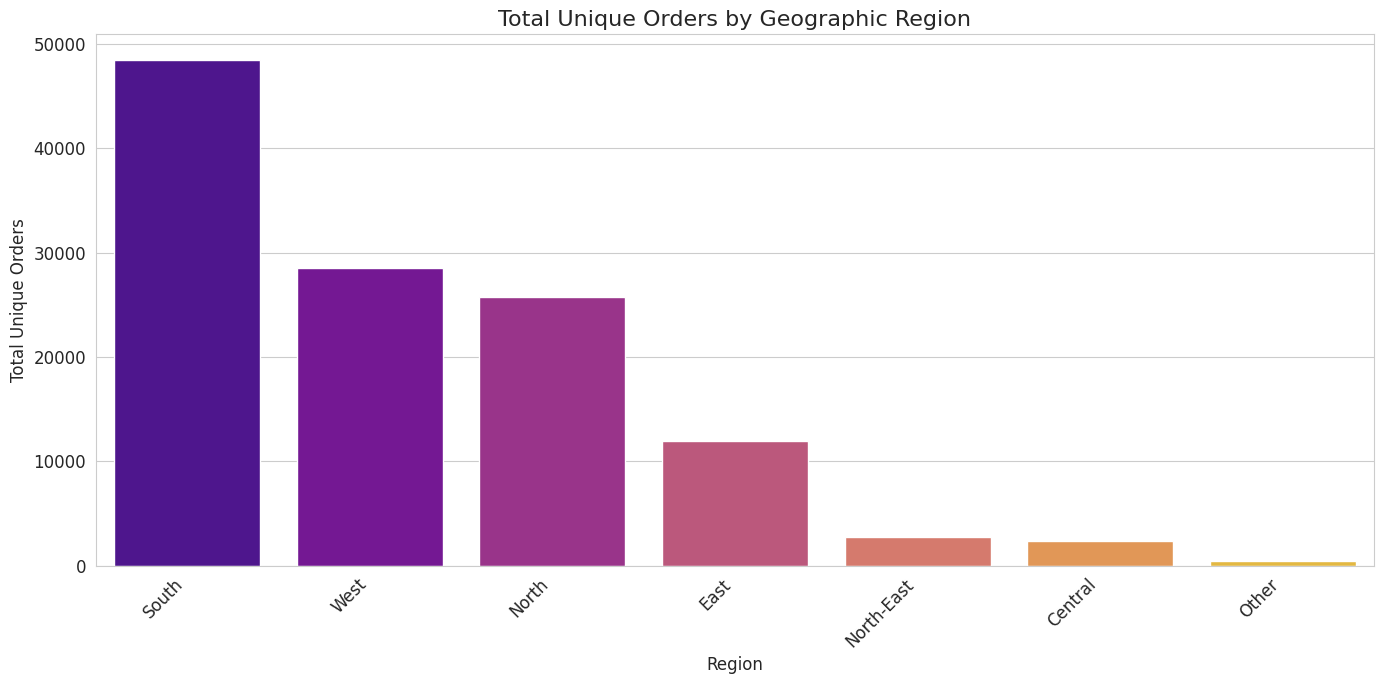

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("### Analyzing: Orders by Region")

# Ensure df_features is available
if 'df_features' not in locals() or df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame not found or is empty. Cannot perform geographic analysis.")

required_cols = ['Region', 'Order ID']
for col in required_cols:
    if col not in df_features.columns:
        print(f"Warning: Column '{col}' not found in df_features. Skipping analysis.")
        # Exit early if a required column is missing
        exit()

# Exclude missing Region or Order ID values
df_region_orders = df_features.dropna(subset=['Region', 'Order ID']).copy()

# Calculate total unique orders by Region
orders_by_region = df_region_orders.groupby('Region')['Order ID'].nunique().sort_values(ascending=False)

print("\n--- Total Unique Orders by Region ---")
print(orders_by_region.apply(lambda x: f'{x:,} orders'))

# Visualization: Bar Chart of Orders by Region
plt.figure(figsize=(14, 7))
sns.barplot(x=orders_by_region.index, y=orders_by_region.values, palette='plasma')
plt.title('Total Unique Orders by Geographic Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Unique Orders', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 4.7 Time Series Analysis

**Purpose**

Analyze sales trends over time.

- Analysis
- Daily Revenue
- Weekly Revenue
- Monthly Revenue
- Quarterly Revenue
- Weekday Performance
- Weekend vs Weekday Sales

**Visualizations**
- Line Charts
- Area Charts
- Monthly Trend Plot

**Business Value**

- Identify seasonality.
- Detect sales spikes.
- Monitor business growth.

**Error Handling**

- Sort dates before plotting.
- Handle missing dates without interrupting execution.

### 4.7 Time Series Analysis

--- Daily Revenue ---
Top 5 Days by Revenue:
Date
2022-05-04    ₹1,209,364.17
2022-05-03    ₹1,190,672.59
2022-05-02    ₹1,172,327.06
2022-04-14    ₹1,113,487.56
2022-04-23    ₹1,093,536.62
Name: Amount, dtype: object

Bottom 5 Days by Revenue:
Date
2022-03-31    ₹101,683.85
2022-06-29    ₹411,530.76
2022-06-24    ₹630,349.29
2022-06-25    ₹654,234.58
2022-06-23    ₹654,729.48
Name: Amount, dtype: object


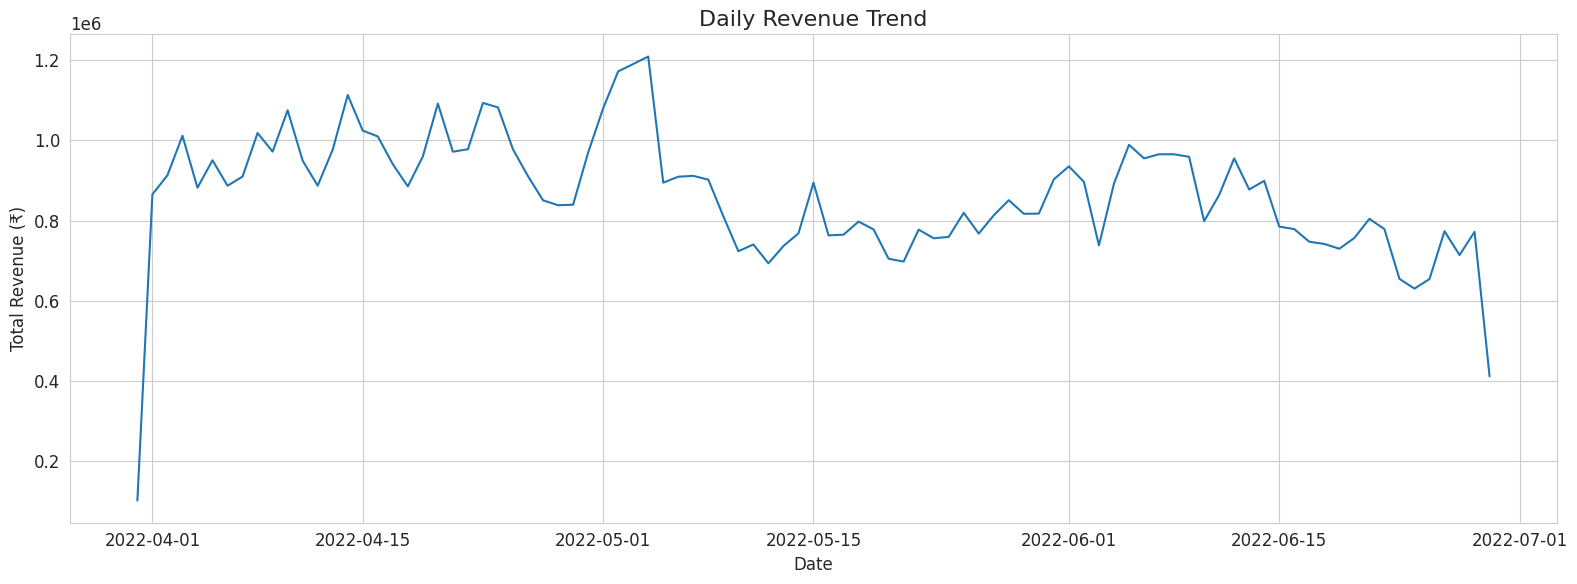


--- Weekly Revenue ---
Top 5 Weeks by Revenue:
Year  Week Number
2022  18             ₹7,190,464.94
      16             ₹7,063,406.00
      15             ₹6,902,700.42
      14             ₹6,695,415.95
      17             ₹6,466,799.96
Name: Amount, dtype: object


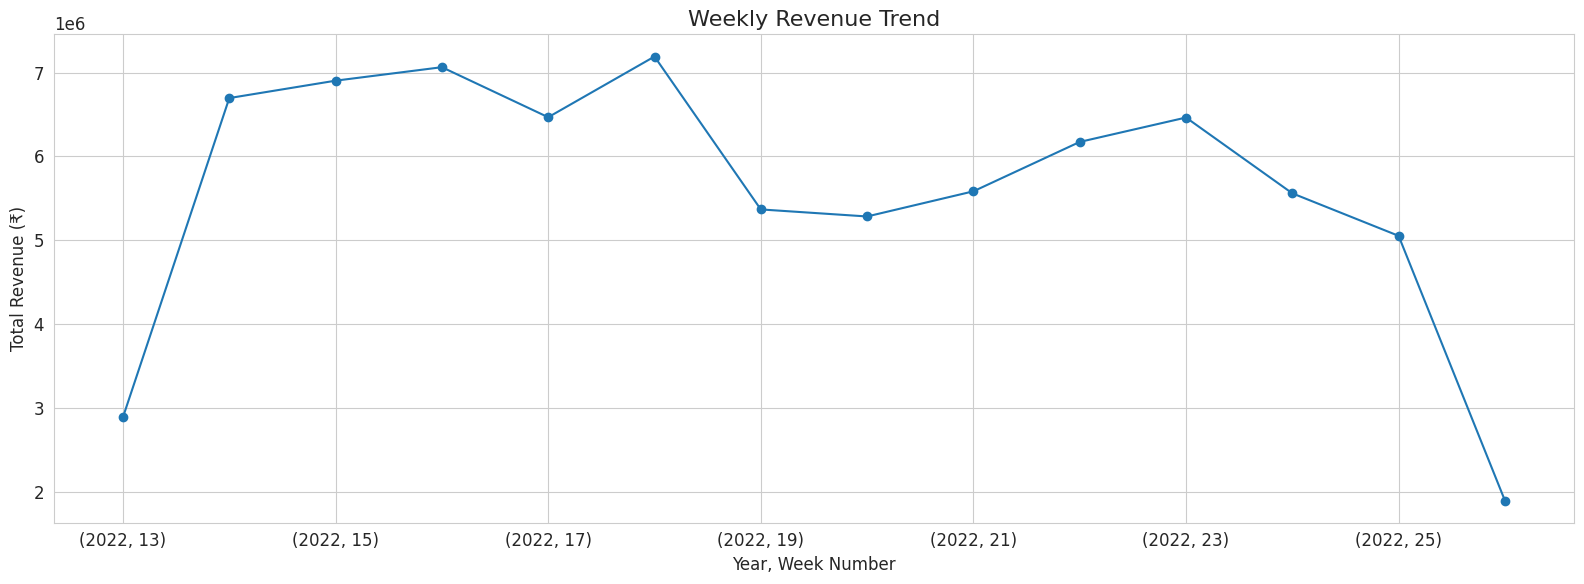


--- Monthly Revenue ---
Top 5 Months by Revenue:
MonthYear
April 2022    ₹28,838,708.32
May 2022      ₹26,226,476.75
June 2022     ₹23,425,809.38
March 2022       ₹101,683.85
Name: Amount, dtype: object


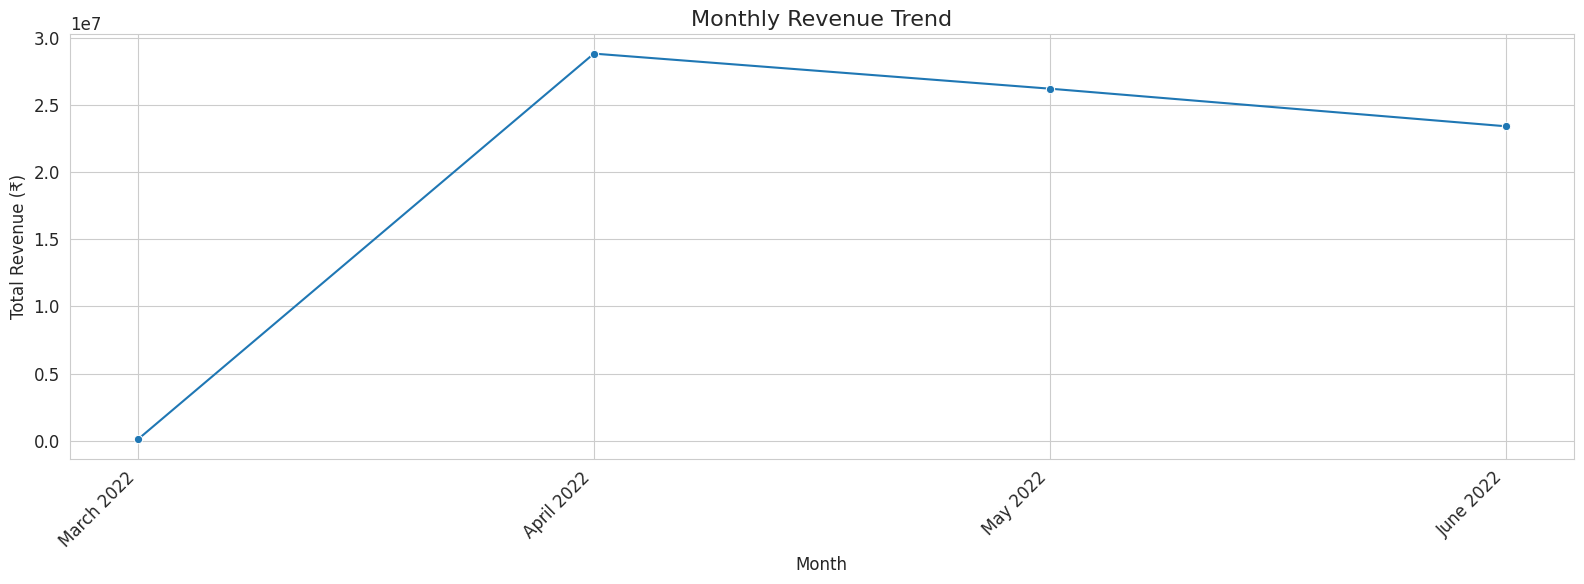


--- Quarterly Revenue ---
Revenue by Quarter:
Year  Quarter
2022  1             ₹101,683.85
      2          ₹78,490,994.45
Name: Amount, dtype: object


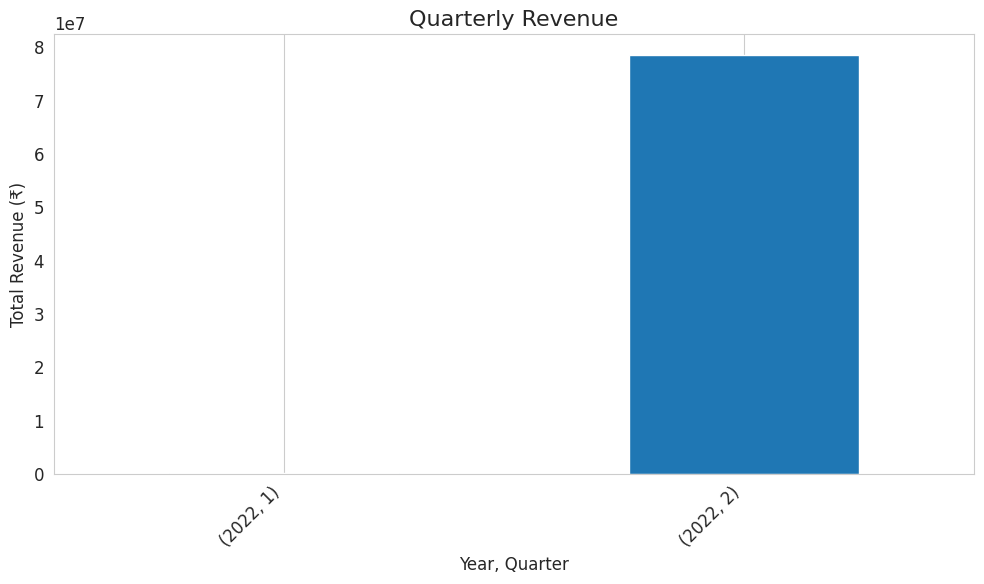


--- Weekday Performance ---
Revenue by Day of Week:
Day Name
Monday       ₹11,318,441.14
Tuesday      ₹11,491,626.07
Wednesday    ₹11,249,823.35
Thursday     ₹10,358,594.27
Friday       ₹10,805,394.60
Saturday     ₹11,339,357.57
Sunday       ₹12,029,441.30
Name: Amount, dtype: object


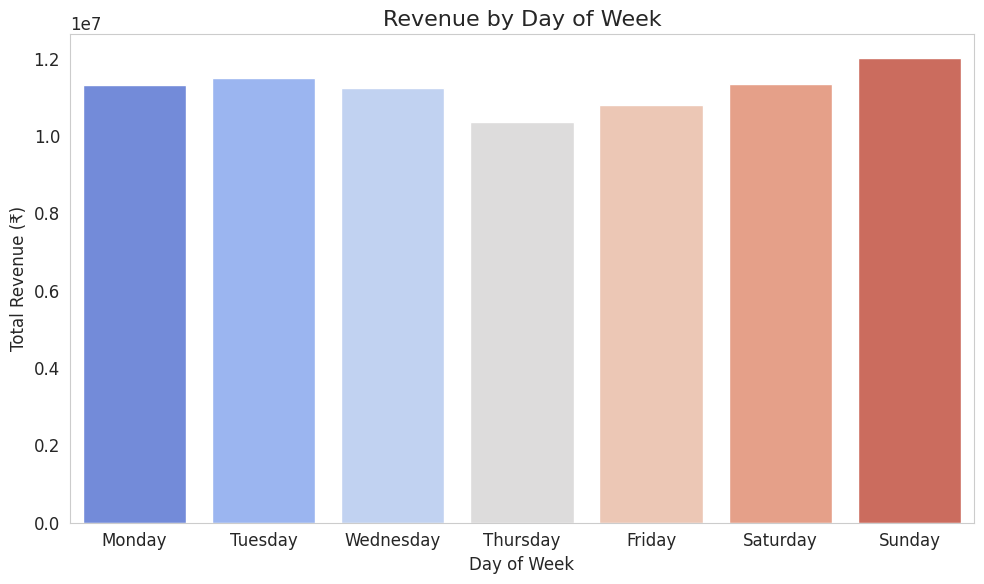


--- Weekend vs Weekday Sales ---
Revenue for Weekend vs. Weekday:
Is_Weekend
False    ₹55,223,879.43
True     ₹23,368,798.87
Name: Amount, dtype: object


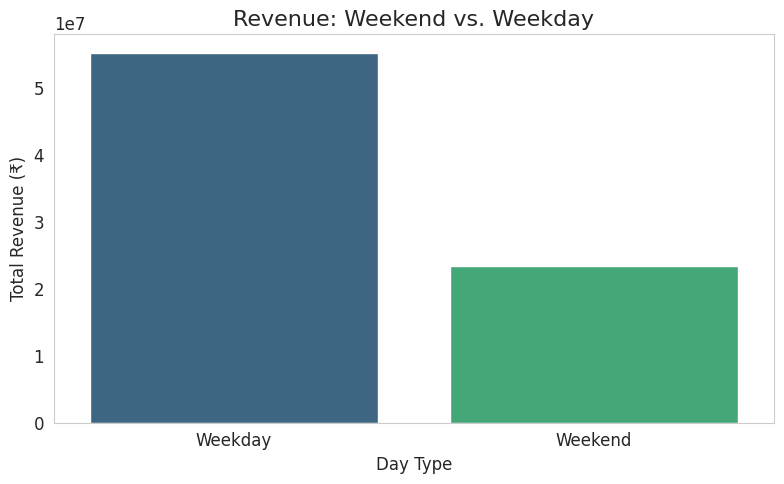


Time Series Analysis Completed.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("### 4.7 Time Series Analysis")

# Ensure df_features is available and not empty
if 'df_features' not in locals() or df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame not found or is empty. Cannot perform time series analysis.")

# Ensure 'Date' and 'Amount' columns exist and are of correct types
required_cols_time_series = ['Date', 'Amount', 'Year', 'Month', 'Month Name', 'Week Number', 'Quarter', 'Day Name', 'Is_Weekend']
for col in required_cols_time_series:
    if col not in df_features.columns:
        print(f"Warning: Required column '{col}' not found in df_features. Skipping relevant analysis.")
        # If a critical column like 'Date' or 'Amount' is missing, stop further time series analysis
        if col in ['Date', 'Amount']:
            raise ValueError(f"Critical column '{col}' missing for time series analysis.")

# --- Daily Revenue Analysis ---
print("\n--- Daily Revenue ---")
df_time_series = df_features.dropna(subset=['Date', 'Amount']).copy()

if not df_time_series.empty:
    daily_revenue = df_time_series.groupby('Date')['Amount'].sum().sort_index()

    print("Top 5 Days by Revenue:")
    print(daily_revenue.nlargest(5).apply(lambda x: f'₹{x:,.2f}'))
    print("\nBottom 5 Days by Revenue:")
    print(daily_revenue.nsmallest(5).apply(lambda x: f'₹{x:,.2f}'))

    plt.figure(figsize=(16, 6))
    sns.lineplot(x=daily_revenue.index, y=daily_revenue.values)
    plt.title('Daily Revenue Trend', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Total Revenue (₹)', fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No valid daily data for revenue analysis after cleaning.")

# --- Weekly Revenue Analysis ---
print("\n--- Weekly Revenue ---")
if all(col in df_features.columns for col in ['Year', 'Week Number', 'Amount']):
    weekly_revenue = df_features.dropna(subset=['Year', 'Week Number', 'Amount']).groupby(['Year', 'Week Number'])['Amount'].sum().sort_index()

    if not weekly_revenue.empty:
        print("Top 5 Weeks by Revenue:")
        print(weekly_revenue.nlargest(5).apply(lambda x: f'₹{x:,.2f}'))

        plt.figure(figsize=(16, 6))
        weekly_revenue.plot(kind='line', marker='o')
        plt.title('Weekly Revenue Trend', fontsize=16)
        plt.xlabel('Year, Week Number', fontsize=12)
        plt.ylabel('Total Revenue (₹)', fontsize=12)
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print("No valid weekly data for revenue analysis after cleaning.")
else:
    print("Skipping Weekly Revenue analysis due to missing 'Year', 'Week Number', or 'Amount' columns.")

# --- Monthly Revenue Analysis ---
print("\n--- Monthly Revenue ---")
if all(col in df_features.columns for col in ['Year', 'Month', 'Month Name', 'Amount']):
    # Group by year and month number to ensure correct chronological order, then month name for display
    monthly_revenue = df_features.dropna(subset=['Year', 'Month', 'Amount']).groupby(['Year', 'Month', 'Month Name'])['Amount'].sum()
    monthly_revenue = monthly_revenue.reset_index().sort_values(by=['Year', 'Month'])
    monthly_revenue['MonthYear'] = monthly_revenue['Month Name'] + ' ' + monthly_revenue['Year'].astype(str)

    if not monthly_revenue.empty:
        print("Top 5 Months by Revenue:")
        print(monthly_revenue.set_index('MonthYear')['Amount'].nlargest(5).apply(lambda x: f'₹{x:,.2f}'))

        plt.figure(figsize=(16, 6))
        sns.lineplot(x='MonthYear', y='Amount', data=monthly_revenue, marker='o')
        plt.title('Monthly Revenue Trend', fontsize=16)
        plt.xlabel('Month', fontsize=12)
        plt.ylabel('Total Revenue (₹)', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print("No valid monthly data for revenue analysis after cleaning.")
else:
    print("Skipping Monthly Revenue analysis due to missing 'Year', 'Month', 'Month Name', or 'Amount' columns.")

# --- Quarterly Revenue Analysis ---
print("\n--- Quarterly Revenue ---")
if all(col in df_features.columns for col in ['Year', 'Quarter', 'Amount']):
    quarterly_revenue = df_features.dropna(subset=['Year', 'Quarter', 'Amount']).groupby(['Year', 'Quarter'])['Amount'].sum().sort_index()

    if not quarterly_revenue.empty:
        print("Revenue by Quarter:")
        print(quarterly_revenue.apply(lambda x: f'₹{x:,.2f}'))

        plt.figure(figsize=(10, 6))
        quarterly_revenue.plot(kind='bar')
        plt.title('Quarterly Revenue', fontsize=16)
        plt.xlabel('Year, Quarter', fontsize=12)
        plt.ylabel('Total Revenue (₹)', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y')
        plt.tight_layout()
        plt.show()
    else:
        print("No valid quarterly data for revenue analysis after cleaning.")
else:
    print("Skipping Quarterly Revenue analysis due to missing 'Year', 'Quarter', or 'Amount' columns.")

# --- Weekday Performance Analysis ---
print("\n--- Weekday Performance ---")
if all(col in df_features.columns for col in ['Day Name', 'Amount']):
    weekday_performance = df_features.dropna(subset=['Day Name', 'Amount']).groupby('Day Name')['Amount'].sum()
    # Define order for weekdays for better visualization
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    weekday_performance = weekday_performance.reindex(day_order, fill_value=0)

    if not weekday_performance.empty:
        print("Revenue by Day of Week:")
        print(weekday_performance.apply(lambda x: f'₹{x:,.2f}'))

        plt.figure(figsize=(10, 6))
        sns.barplot(x=weekday_performance.index, y=weekday_performance.values, palette='coolwarm')
        plt.title('Revenue by Day of Week', fontsize=16)
        plt.xlabel('Day of Week', fontsize=12)
        plt.ylabel('Total Revenue (₹)', fontsize=12)
        plt.grid(axis='y')
        plt.tight_layout()
        plt.show()
    else:
        print("No valid day name data for revenue analysis after cleaning.")
else:
    print("Skipping Weekday Performance analysis due to missing 'Day Name' or 'Amount' columns.")

# --- Weekend vs Weekday Sales Analysis ---
print("\n--- Weekend vs Weekday Sales ---")
if all(col in df_features.columns for col in ['Is_Weekend', 'Amount']):
    weekend_sales = df_features.dropna(subset=['Is_Weekend', 'Amount']).groupby('Is_Weekend')['Amount'].sum()

    if not weekend_sales.empty:
        print("Revenue for Weekend vs. Weekday:")
        print(weekend_sales.apply(lambda x: f'₹{x:,.2f}'))

        plt.figure(figsize=(8, 5))
        sns.barplot(x=weekend_sales.index.map({True: 'Weekend', False: 'Weekday'}), y=weekend_sales.values, palette='viridis')
        plt.title('Revenue: Weekend vs. Weekday', fontsize=16)
        plt.xlabel('Day Type', fontsize=12)
        plt.ylabel('Total Revenue (₹)', fontsize=12)
        plt.grid(axis='y')
        plt.tight_layout()
        plt.show()
    else:
        print("No valid weekend/weekday data for revenue analysis after cleaning.")
else:
    print("Skipping Weekend vs Weekday Sales analysis due to missing 'Is_Weekend' or 'Amount' columns.")

print("\nTime Series Analysis Completed.")

#### 4.8 Bivariate Analysis

**Purpose**

Study relationships between variables.

- Analysis
- Amount vs Qty
- Amount by Category
- Amount by Fulfilment
- Amount by Region
- Revenue by Order Value Segment
- Revenue by Quantity Segment

**Visualizations**

- Scatter Plot
- Boxplot
- Violin Plot

**Business Value**

- Compare product performance.
- Evaluate pricing differences.
- Understand purchasing behavior.

**Error Handling**

- Remove invalid numeric values.
- Skip empty groups.

### 4.8 Bivariate Analysis

--- Analyzing: Amount vs Qty ---


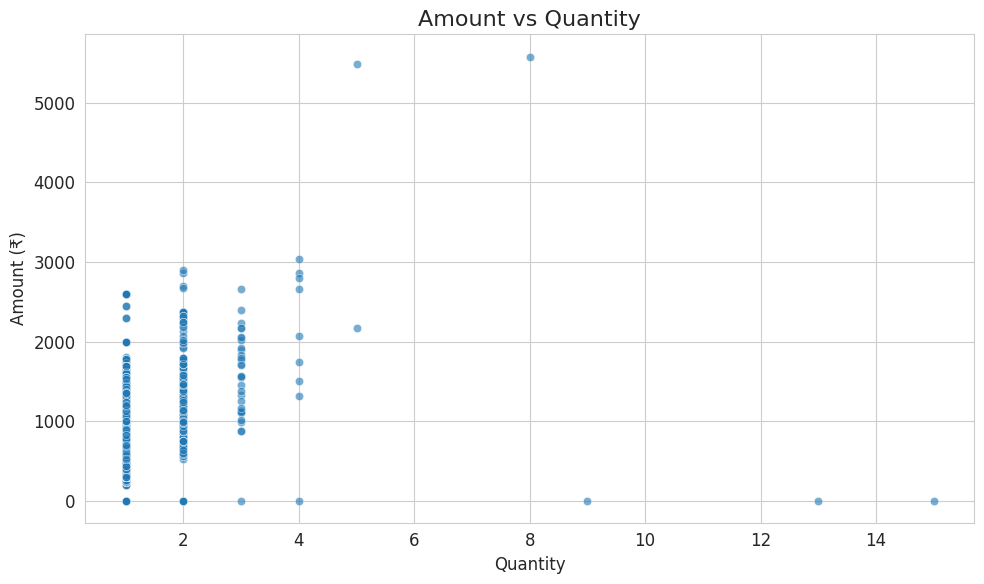


--- Analyzing: Amount by Category Group ---


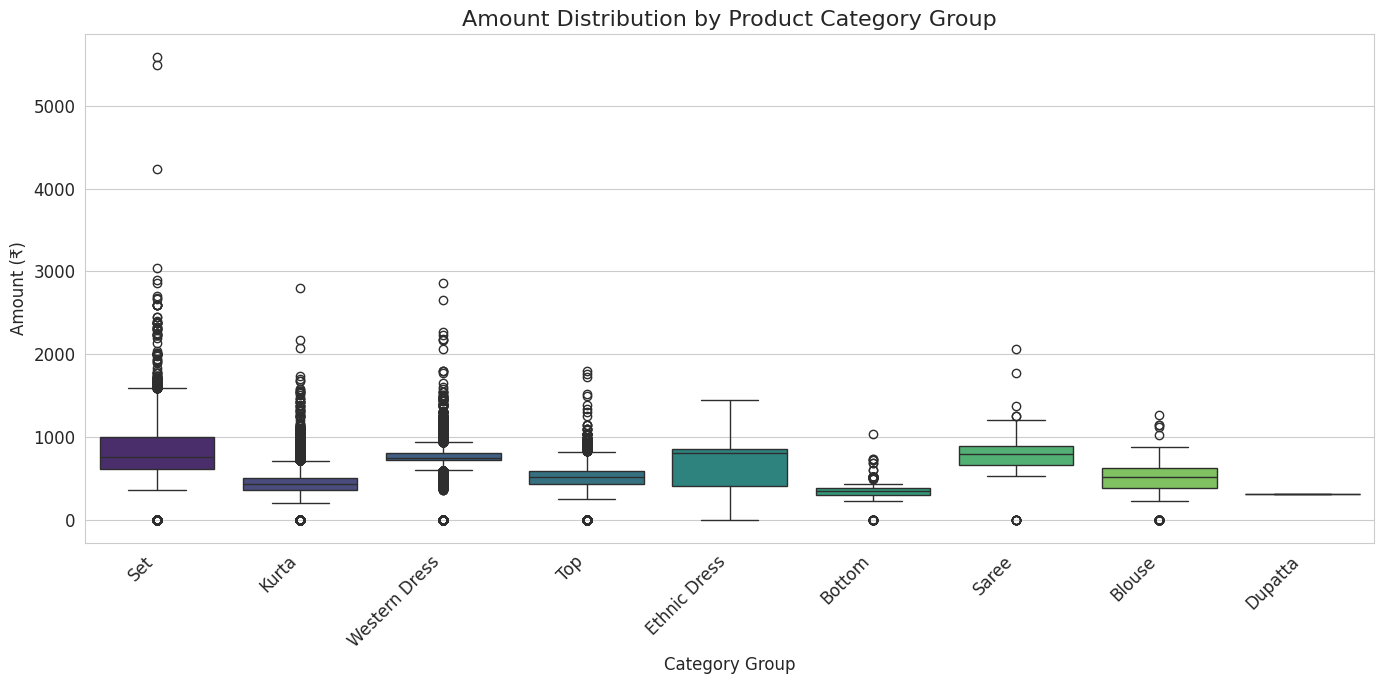


--- Analyzing: Amount by Fulfilment ---


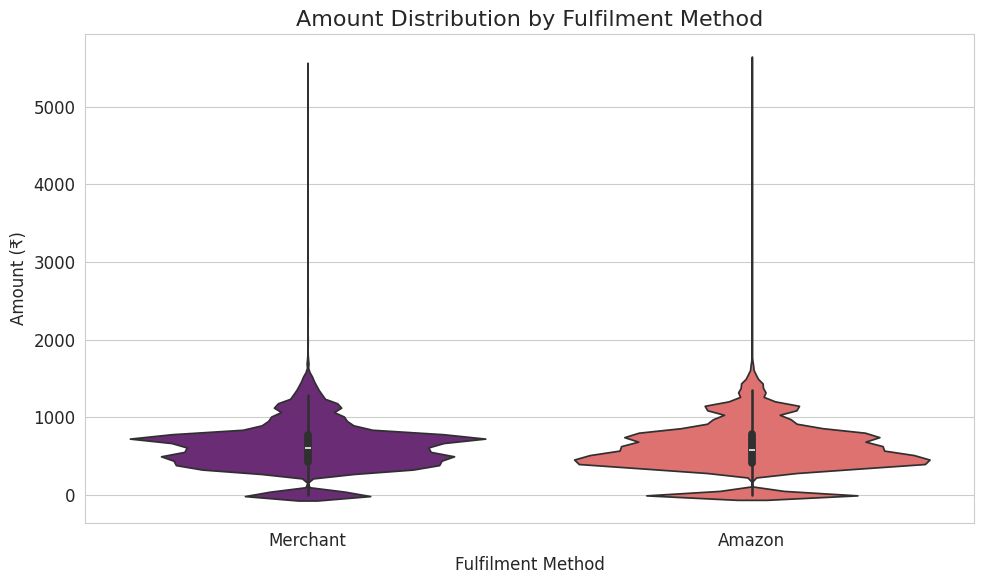


--- Analyzing: Amount by Region ---


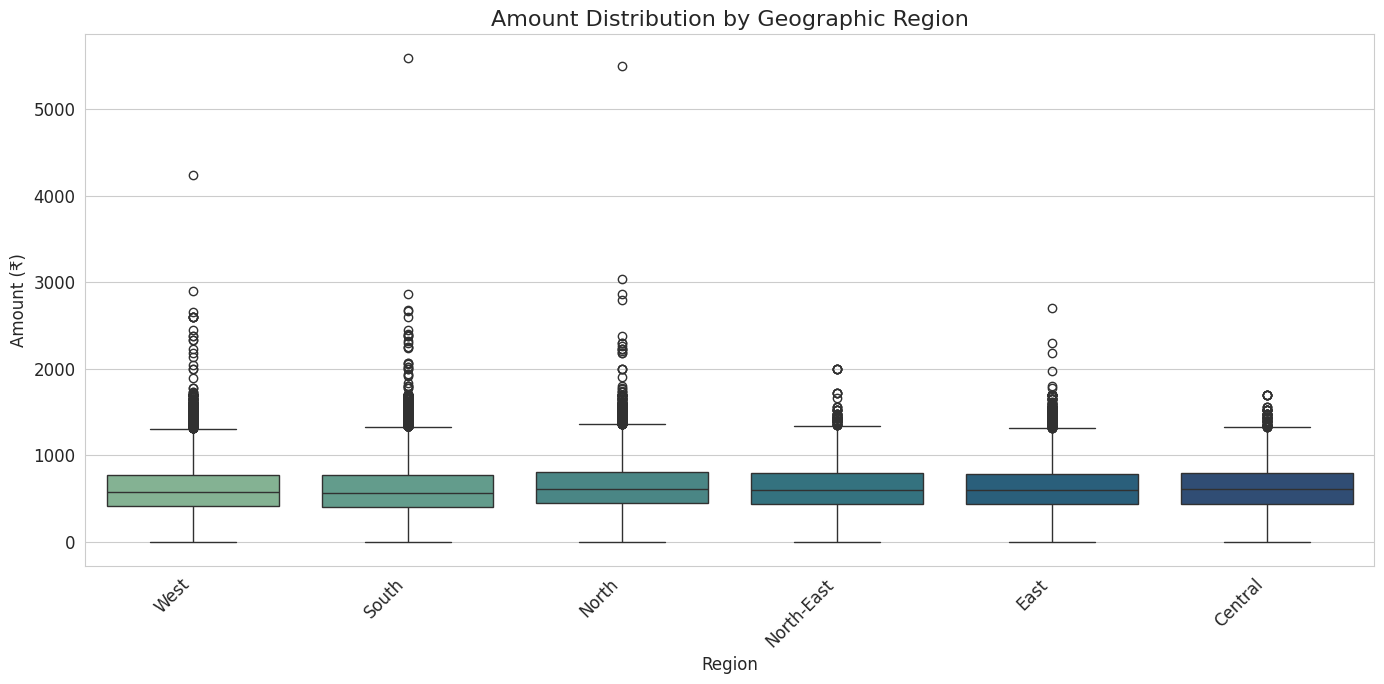


--- Analyzing: Revenue by Order Value Segment ---


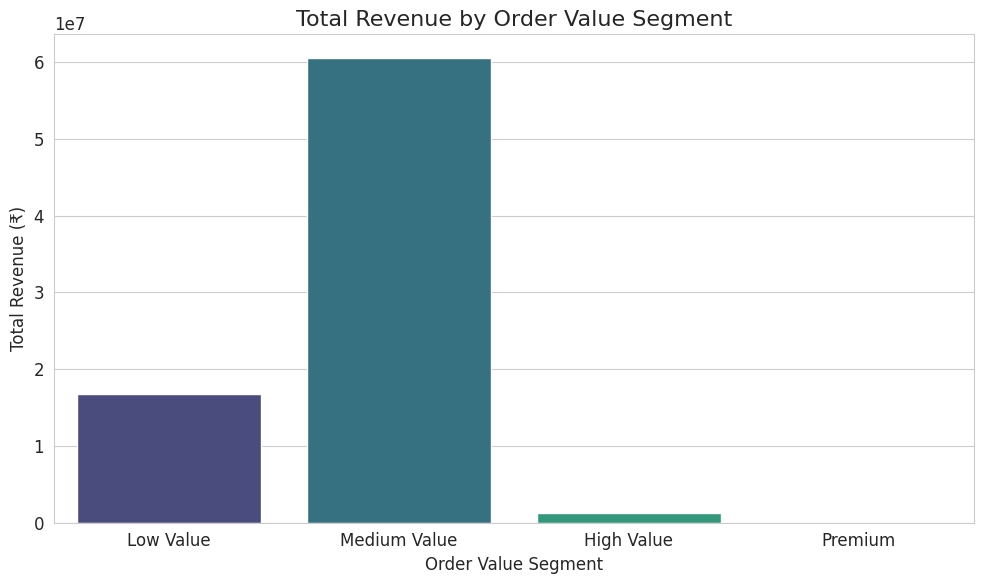


--- Analyzing: Revenue by Quantity Segment ---


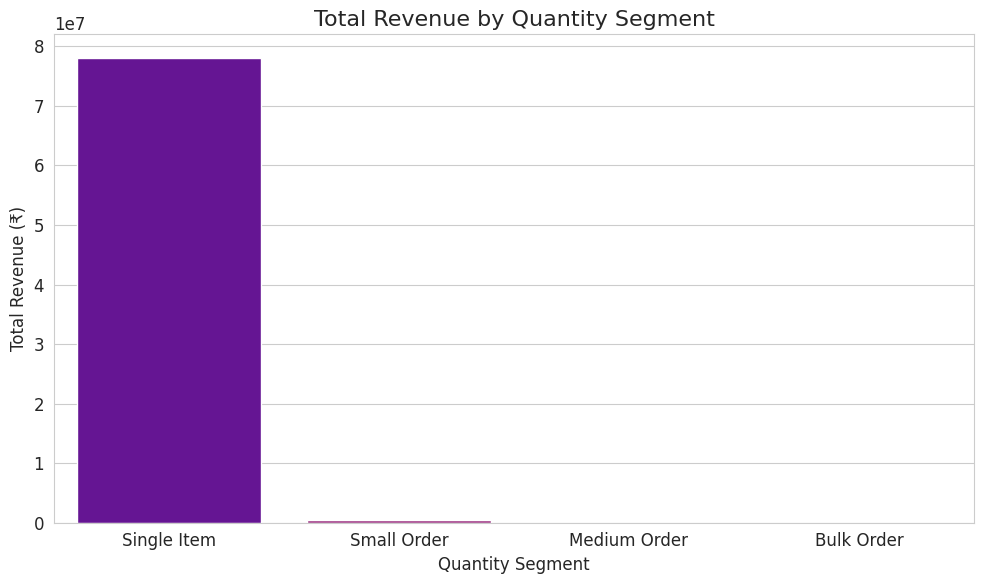


Bivariate Analysis Completed.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("### 4.8 Bivariate Analysis")

# Ensure df_features is available and not empty
if 'df_features' not in locals() or df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame not found or is empty. Cannot perform bivariate analysis.")

# --- 1. Amount vs Qty ---
print("\n--- Analyzing: Amount vs Qty ---")
required_cols_amount_qty = ['Amount', 'Qty']
if all(col in df_features.columns for col in required_cols_amount_qty):
    df_plot = df_features.dropna(subset=required_cols_amount_qty).copy()
    df_plot = df_plot[df_plot['Qty'] > 0] # Filter out Qty = 0 for meaningful scatter

    if not df_plot.empty:
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x='Qty', y='Amount', data=df_plot, alpha=0.6)
        plt.title('Amount vs Quantity', fontsize=16)
        plt.xlabel('Quantity', fontsize=12)
        plt.ylabel('Amount (₹)', fontsize=12)
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print("No valid data for 'Amount vs Qty' after cleaning. Skipping.")
else:
    print(f"Skipping 'Amount vs Qty' analysis due to missing column(s): {', '.join([col for col in required_cols_amount_qty if col not in df_features.columns])}.")

# --- 2. Amount by Category Group ---
print("\n--- Analyzing: Amount by Category Group ---")
required_cols_category = ['Category_Group', 'Amount']
if all(col in df_features.columns for col in required_cols_category):
    df_plot = df_features.dropna(subset=required_cols_category).copy()

    if not df_plot.empty and df_plot['Category_Group'].nunique() > 1:
        plt.figure(figsize=(14, 7))
        sns.boxplot(x='Category_Group', y='Amount', data=df_plot, palette='viridis')
        plt.title('Amount Distribution by Product Category Group', fontsize=16)
        plt.xlabel('Category Group', fontsize=12)
        plt.ylabel('Amount (₹)', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough valid data or unique categories for 'Amount by Category Group' after cleaning. Skipping.")
else:
    print(f"Skipping 'Amount by Category Group' analysis due to missing column(s): {', '.join([col for col in required_cols_category if col not in df_features.columns])}.")

# --- 3. Amount by Fulfilment ---
print("\n--- Analyzing: Amount by Fulfilment ---")
required_cols_fulfilment = ['Fulfilment', 'Amount']
if all(col in df_features.columns for col in required_cols_fulfilment):
    df_plot = df_features.dropna(subset=required_cols_fulfilment).copy()

    if not df_plot.empty and df_plot['Fulfilment'].nunique() > 1:
        plt.figure(figsize=(10, 6))
        sns.violinplot(x='Fulfilment', y='Amount', data=df_plot, palette='magma')
        plt.title('Amount Distribution by Fulfilment Method', fontsize=16)
        plt.xlabel('Fulfilment Method', fontsize=12)
        plt.ylabel('Amount (₹)', fontsize=12)
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough valid data or unique fulfilment methods for 'Amount by Fulfilment' after cleaning. Skipping.")
else:
    print(f"Skipping 'Amount by Fulfilment' analysis due to missing column(s): {', '.join([col for col in required_cols_fulfilment if col not in df_features.columns])}.")

# --- 4. Amount by Region ---
print("\n--- Analyzing: Amount by Region ---")
required_cols_region = ['Region', 'Amount']
if all(col in df_features.columns for col in required_cols_region):
    df_plot = df_features.dropna(subset=required_cols_region).copy()
    df_plot = df_plot[df_plot['Region'] != 'Other'] # Exclude 'Other' if it's a catch-all

    if not df_plot.empty and df_plot['Region'].nunique() > 1:
        plt.figure(figsize=(14, 7))
        sns.boxplot(x='Region', y='Amount', data=df_plot, palette='crest')
        plt.title('Amount Distribution by Geographic Region', fontsize=16)
        plt.xlabel('Region', fontsize=12)
        plt.ylabel('Amount (₹)', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough valid data or unique regions for 'Amount by Region' after cleaning. Skipping.")
else:
    print(f"Skipping 'Amount by Region' analysis due to missing column(s): {', '.join([col for col in required_cols_region if col not in df_features.columns])}.")

# --- 5. Revenue by Order Value Segment ---
print("\n--- Analyzing: Revenue by Order Value Segment ---")
required_cols_order_value = ['Order_Value_Segment', 'Amount']
if all(col in df_features.columns for col in required_cols_order_value):
    df_plot = df_features.dropna(subset=required_cols_order_value).copy()

    if not df_plot.empty and df_plot['Order_Value_Segment'].nunique() > 1:
        revenue_by_segment = df_plot.groupby('Order_Value_Segment')['Amount'].sum().sort_values(ascending=False)

        plt.figure(figsize=(10, 6))
        sns.barplot(x=revenue_by_segment.index, y=revenue_by_segment.values, palette='viridis')
        plt.title('Total Revenue by Order Value Segment', fontsize=16)
        plt.xlabel('Order Value Segment', fontsize=12)
        plt.ylabel('Total Revenue (₹)', fontsize=12)
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough valid data or unique segments for 'Revenue by Order Value Segment' after cleaning. Skipping.")
else:
    print(f"Skipping 'Revenue by Order Value Segment' analysis due to missing column(s): {', '.join([col for col in required_cols_order_value if col not in df_features.columns])}.")

# --- 6. Revenue by Quantity Segment ---
print("\n--- Analyzing: Revenue by Quantity Segment ---")
required_cols_qty_segment = ['Quantity_Segment', 'Amount']
if all(col in df_features.columns for col in required_cols_qty_segment):
    df_plot = df_features.dropna(subset=required_cols_qty_segment).copy()

    if not df_plot.empty and df_plot['Quantity_Segment'].nunique() > 1:
        revenue_by_qty_segment = df_plot.groupby('Quantity_Segment')['Amount'].sum().sort_values(ascending=False)

        plt.figure(figsize=(10, 6))
        sns.barplot(x=revenue_by_qty_segment.index, y=revenue_by_qty_segment.values, palette='plasma')
        plt.title('Total Revenue by Quantity Segment', fontsize=16)
        plt.xlabel('Quantity Segment', fontsize=12)
        plt.ylabel('Total Revenue (₹)', fontsize=12)
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough valid data or unique segments for 'Revenue by Quantity Segment' after cleaning. Skipping.")
else:
    print(f"Skipping 'Revenue by Quantity Segment' analysis due to missing column(s): {', '.join([col for col in required_cols_qty_segment if col not in df_features.columns])}.")

print("\nBivariate Analysis Completed.")

#### 4.9 Correlation Analysis

**Purpose**

Measure relationships among numerical variables.

- Variables
- Amount
- Qty
- Revenue_per_Unit

**Visualizations**

- Correlation Matrix
- Heatmap

**Business Value**

- Identify strong relationships.
- Detect multicollinearity.
- Support feature selection.

**Error Handling**

- Exclude non-numeric columns.
- Handle constant-value columns.

### 4.9 Correlation Analysis

--- Correlation Matrix ---
                    Amount       Qty  Revenue_per_Unit
Amount            1.000000  0.391096          0.908686
Qty               0.391096  1.000000          0.561396
Revenue_per_Unit  0.908686  0.561396          1.000000


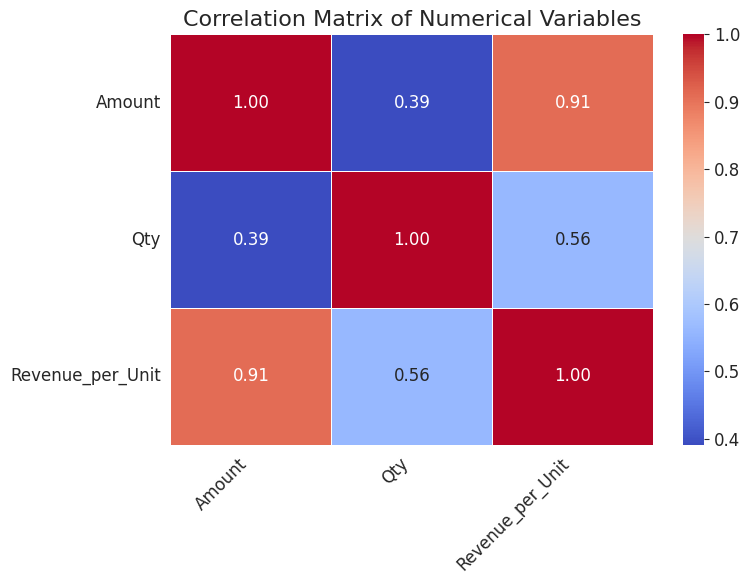


Correlation Analysis Completed.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("### 4.9 Correlation Analysis")

# Ensure df_features is available and not empty
if 'df_features' not in locals() or df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame not found or is empty. Cannot perform correlation analysis.")

# Define the numerical variables for correlation analysis
numerical_vars_corr = ['Amount', 'Qty', 'Revenue_per_Unit']

# Filter df_features to include only the relevant numerical columns and drop rows with NaNs in these columns
df_corr = df_features[numerical_vars_corr].dropna().copy()

# Ensure all columns are numeric, coercing errors
for col in numerical_vars_corr:
    df_corr[col] = pd.to_numeric(df_corr[col], errors='coerce')

# Drop columns that became all NaN after coercion or were already all NaN
df_corr.dropna(axis=1, how='all', inplace=True)

# Check for constant-value columns and remove them for correlation calculation
# A column with constant value will result in NaN correlation with other variables
constant_cols = [col for col in df_corr.columns if df_corr[col].nunique() == 1]
if constant_cols:
    print(f"Warning: The following columns have constant values and will be excluded from correlation: {constant_cols}")
    df_corr.drop(columns=constant_cols, inplace=True)

if df_corr.empty or df_corr.shape[1] < 2:
    print("Not enough valid numerical data (at least two non-constant columns) for correlation analysis after cleaning. Skipping.")
else:
    # Calculate the correlation matrix
    correlation_matrix = df_corr.corr()

    print("\n--- Correlation Matrix ---")
    print(correlation_matrix)

    # Visualization: Heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Correlation Matrix of Numerical Variables', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

print("\nCorrelation Analysis Completed.")

#### 4.10 Distribution & Outlier Review

**Purpose**

Validate the impact of cleaning and feature engineering.

- Review
- Amount before vs capped
- Revenue distribution
- Quantity distribution
- Extreme observations

**Visualizations**

- Boxplots
- Histograms

**Business Value**

- Confirms whether outlier treatment - improved data quality.

**Error Handling**

- Skip comparison if capped values do not exist.

### 4.10 Distribution & Outlier Review

--- Reviewing Distribution and Outliers for: Amount ---


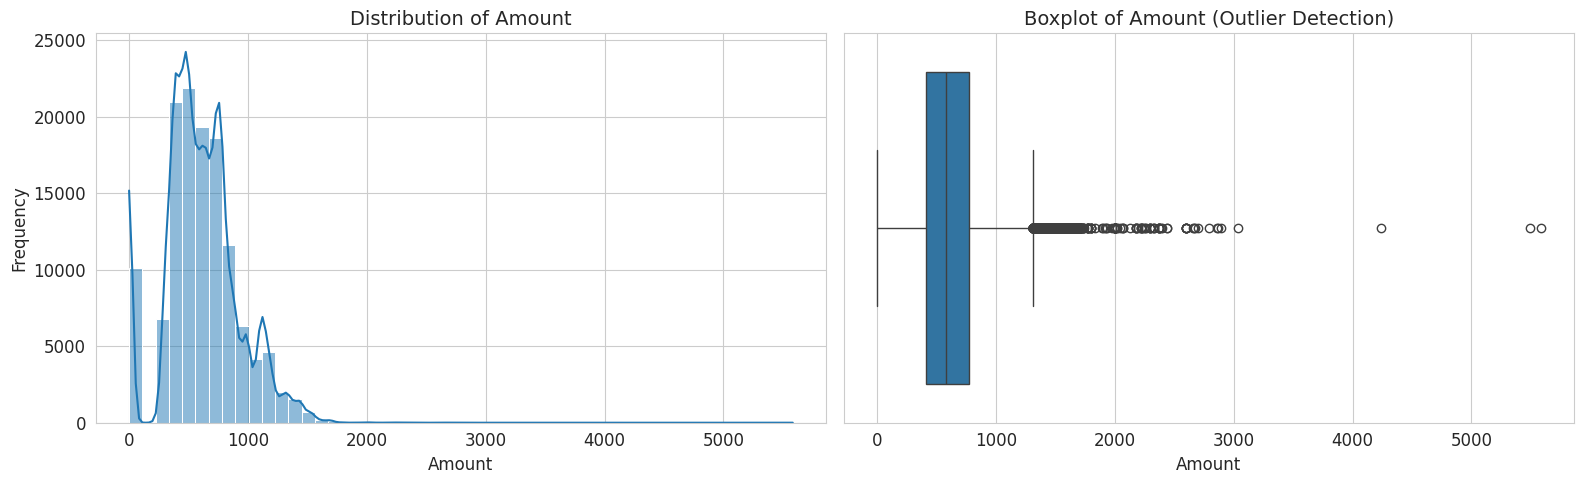

Top 5 extreme observations (potential outliers) for Amount:
42039     5584.00
11160     5495.00
24494     4235.72
89150     3036.00
121225    2894.00
Name: Amount, dtype: float64

--- Reviewing Distribution and Outliers for: Qty ---


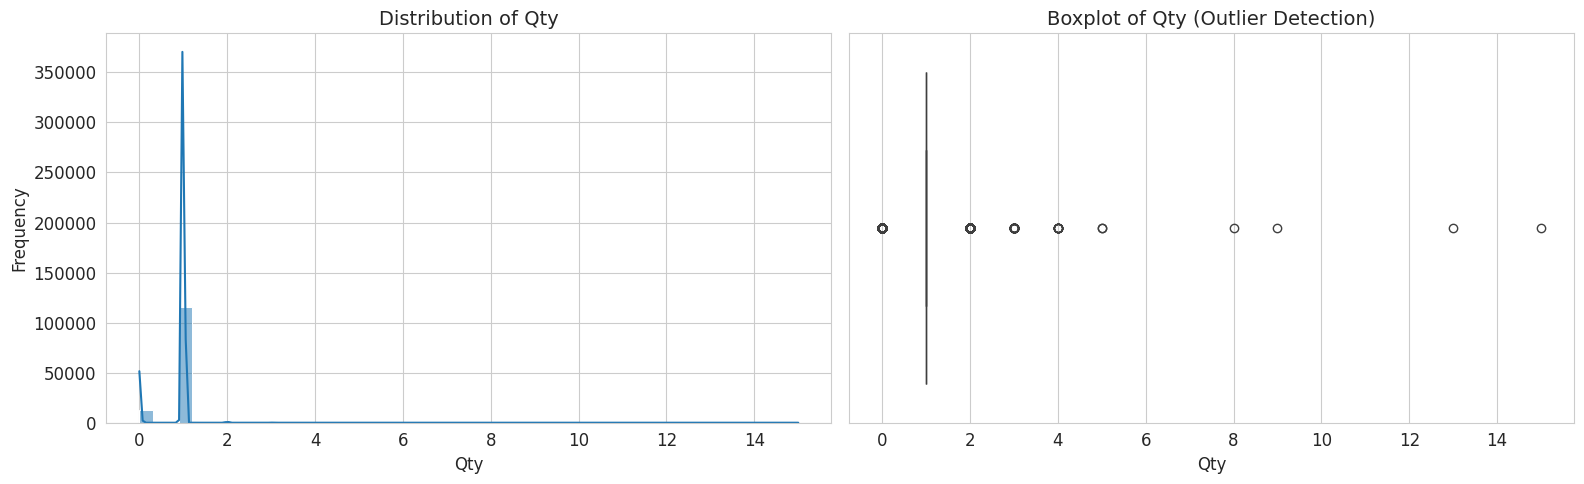


--- Reviewing Distribution and Outliers for: Revenue_per_Unit ---


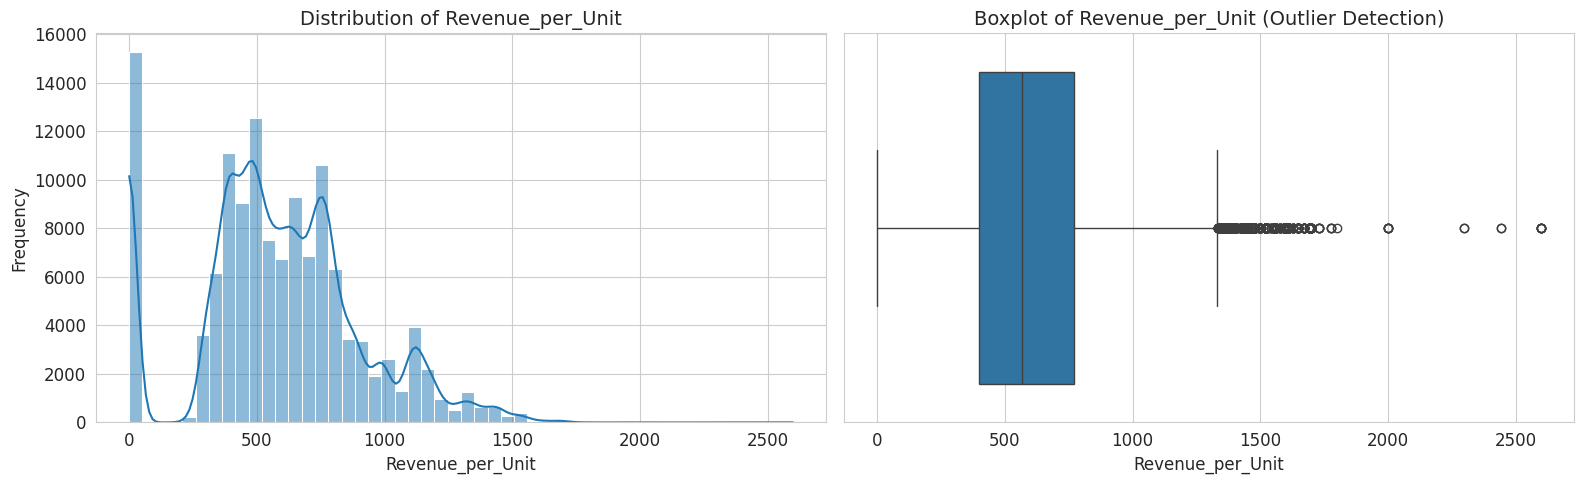

Top 5 extreme observations (potential outliers) for Revenue_per_Unit:
56307     2598.0
67764     2598.0
69527     2598.0
112946    2598.0
114176    2598.0
Name: Revenue_per_Unit, dtype: float64

Distribution & Outlier Review Completed.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("### 4.10 Distribution & Outlier Review")

# Ensure df_features is available and not empty
if 'df_features' not in locals() or df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame not found or is empty. Cannot perform distribution and outlier review.")

# Define the numerical variables for distribution and outlier review
numerical_vars_review = ['Amount', 'Qty', 'Revenue_per_Unit']

for col in numerical_vars_review:
    print(f"\n--- Reviewing Distribution and Outliers for: {col} ---")

    if col not in df_features.columns:
        print(f"Warning: Column '{col}' not found in df_features. Skipping review for this column.")
        continue

    # Convert to numeric, coercing errors to NaN
    # Use a temporary series for plotting to avoid modifying the original df_features['Amount'] further here
    series_to_analyze = pd.to_numeric(df_features[col], errors='coerce').dropna()

    if series_to_analyze.empty:
        print(f"Warning: Column '{col}' has no valid observations after dropping NaNs. Skipping analysis.")
        continue

    # --- Visualizations --- (Histogram and Boxplot)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Histogram
    sns.histplot(series_to_analyze, kde=True, bins=50, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}', fontsize=14)
    axes[0].set_xlabel(col, fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)

    # Boxplot
    sns.boxplot(x=series_to_analyze, ax=axes[1])
    axes[1].set_title(f'Boxplot of {col} (Outlier Detection)', fontsize=14)
    axes[1].set_xlabel(col, fontsize=12)

    plt.tight_layout()
    plt.show()

    # Quick summary of extreme observations (for `Amount` and `Revenue_per_Unit`)
    if col in ['Amount', 'Revenue_per_Unit']:
        q1 = series_to_analyze.quantile(0.25)
        q3 = series_to_analyze.quantile(0.75)
        iqr = q3 - q1
        upper_bound = q3 + 1.5 * iqr
        outliers = series_to_analyze[series_to_analyze > upper_bound]
        if not outliers.empty:
            print(f"Top 5 extreme observations (potential outliers) for {col}:")
            print(outliers.nlargest(5))
        else:
            print(f"No obvious extreme high outliers detected for {col} using IQR method.")

print("\nDistribution & Outlier Review Completed.")


#### 4.11 Automated Business Insights

**Purpose**

Generate descriptive business findings from the EDA.

- Example Insights
- Highest revenue category
- Best-performing region
- Top-selling state
- Most common order size
- Highest average order value category
- Fulfilment method with highest revenue
- Weekend vs weekday performance
- Promotion effectiveness (if available)

**Business Value**

- Transforms descriptive analysis into actionable insights

**Error Handling**

- Base findings only on available data.
- Avoid reporting metrics with insufficient observations.

In [ ]:
print("### 4.11 Automated Business Insights")

# Ensure df_features is available and not empty
if 'df_features' not in locals() or df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame not found or is empty. Cannot generate business insights.")

print("\n--- Key Business Insights ---")

# 1. Highest revenue category
if 'revenue_by_category' in globals() and not revenue_by_category.empty:
    highest_revenue_category = revenue_by_category.index[0]
    revenue_val = revenue_by_category.iloc[0]
    print(f"- **Highest Revenue Category**: {highest_revenue_category} with total revenue of ₹{revenue_val:,.2f}")
else:
    print("- Could not determine highest revenue category (data not available).")

# 2. Best-performing region
if 'revenue_by_region' in globals() and not revenue_by_region.empty:
    best_performing_region = revenue_by_region.index[0]
    revenue_val = revenue_by_region.iloc[0]
    print(f"- **Best-Performing Region**: {best_performing_region} with total revenue of ₹{revenue_val:,.2f}")
else:
    print("- Could not determine best-performing region (data not available).")

# 3. Top-selling state
if 'revenue_by_state' in globals() and not revenue_by_state.empty:
    top_selling_state = revenue_by_state.index[0]
    revenue_val = revenue_by_state.iloc[0]
    print(f"- **Top-Selling State**: {top_selling_state} with total revenue of ₹{revenue_val:,.2f}")
else:
    print("- Could not determine top-selling state (data not available).")

# 4. Most common order size (based on Quantity Segment)
if 'Quantity_Segment' in df_features.columns and not df_features['Quantity_Segment'].empty:
    most_common_qty_segment = df_features['Quantity_Segment'].value_counts().index[0]
    count_val = df_features['Quantity_Segment'].value_counts().iloc[0]
    print(f"- **Most Common Quantity Segment**: '{most_common_qty_segment}' representing {count_val:,} orders.")
else:
    print("- Could not determine most common quantity segment (data not available).")

# 5. Highest average order value category (based on Amount per Category_Group)
if 'Category_Group' in df_features.columns and 'Amount' in df_features.columns and not df_features[['Category_Group', 'Amount']].dropna().empty:
    avg_amount_by_category = df_features.groupby('Category_Group')['Amount'].mean().sort_values(ascending=False)
    if not avg_amount_by_category.empty:
        highest_avg_order_category = avg_amount_by_category.index[0]
        avg_val = avg_amount_by_category.iloc[0]
        print(f"- **Highest Average Order Value Category**: {highest_avg_order_category} with an average amount of ₹{avg_val:,.2f}.")
    else:
        print("- Could not determine highest average order value category (data not available).")
else:
    print("- Could not determine highest average order value category (required columns not available).")

# 6. Fulfilment method with highest revenue
if 'revenue_by_fulfilment' in globals() and not revenue_by_fulfilment.empty:
    best_fulfilment_method = revenue_by_fulfilment.index[0]
    revenue_val = revenue_by_fulfilment.iloc[0]
    print(f"- **Fulfilment Method with Highest Revenue**: {best_fulfilment_method} generating ₹{revenue_val:,.2f}.")
else:
    print("- Could not determine fulfilment method with highest revenue (data not available).")

# 7. Weekend vs weekday performance
if 'weekend_sales' in globals() and not weekend_sales.empty:
    weekday_revenue = weekend_sales.get(False, 0)
    weekend_revenue = weekend_sales.get(True, 0)
    if weekday_revenue > weekend_revenue:
        print(f"- **Weekend vs Weekday Performance**: Weekdays generated more revenue (₹{weekday_revenue:,.2f}) than weekends (₹{weekend_revenue:,.2f}).")
    elif weekend_revenue > weekday_revenue:
        print(f"- **Weekend vs Weekday Performance**: Weekends generated more revenue (₹{weekend_revenue:,.2f}) than weekdays (₹{weekday_revenue:,.2f}).")
    else:
        print(f"- **Weekend vs Weekday Performance**: Weekday and weekend revenue are approximately equal (Weekday: ₹{weekday_revenue:,.2f}, Weekend: ₹{weekend_revenue:,.2f}).")
else:
    print("- Could not compare weekend vs weekday performance (data not available).")

# 8. Promotion effectiveness (check if 'Has_Promotion' was created and analyze)
if 'Has_Promotion' in df_features.columns and 'Amount' in df_features.columns:
    promo_sales = df_features[df_features['Has_Promotion'] == True]['Amount'].sum()
    non_promo_sales = df_features[df_features['Has_Promotion'] == False]['Amount'].sum()

    if promo_sales > 0 or non_promo_sales > 0:
        total_sales = promo_sales + non_promo_sales
        promo_percentage = (promo_sales / total_sales * 100) if total_sales > 0 else 0
        non_promo_percentage = (non_promo_sales / total_sales * 100) if total_sales > 0 else 0
        print(f"- **Promotion Effectiveness**: Orders with promotions accounted for ₹{promo_sales:,.2f} ({promo_percentage:,.2f}%) of total sales, while non-promotional orders accounted for ₹{non_promo_sales:,.2f} ({non_promo_percentage:,.2f}%).")
    else:
        print("- Promotion effectiveness could not be determined due to insufficient sales data.")
else:
    print("- Promotion effectiveness analysis skipped: 'Has_Promotion' column not available (it was not created in feature engineering).")

print("\n--- Insights Generation Completed ---")

### 4.11 Automated Business Insights

--- Key Business Insights ---
- **Highest Revenue Category**: Set with total revenue of ₹39,204,124.03
- **Best-Performing Region**: South with total revenue of ₹31,155,483.67
- **Top-Selling State**: MAHARASHTRA with total revenue of ₹13,335,534.14
- **Most Common Quantity Segment**: 'Single Item' representing 128,587 orders.
- **Highest Average Order Value Category**: Set with an average amount of ₹779.65.
- **Fulfilment Method with Highest Revenue**: Amazon generating ₹54,322,151.00.
- **Weekend vs Weekday Performance**: Weekdays generated more revenue (₹55,223,879.43) than weekends (₹23,368,798.87).
- Promotion effectiveness analysis skipped: 'Has_Promotion' column not available (it was not created in feature engineering).

--- Insights Generation Completed ---


#### 4.12 EDA Summary Report

- Include
- Dataset Overview
- Total Records
- Total Features
- Numeric Variables
- Categorical Variables

**Key KPIs**

- Total Revenue
- Total Orders
- Average Order Value
- Total Quantity Sold

**Major Findings**

- Top Category
- Top State
- Top Region
- Best Fulfilment Method
- Best Sales Channel

**Data Quality Confirmation**

- No duplicate rows
- Missing values handled
- Engineered features available
- Dataset ready for statistical testing

In [ ]:
print("### 4.12 EDA Summary Report")

# Ensure df_features is available and not empty
if 'df_features' not in locals() and 'df_features' not in globals():
    raise ValueError("Error: 'df_features' DataFrame not found. Cannot generate business insights.")
if df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame is empty. No data for business insights.")

# Recalculate KPIs needed for the summary report if they are not in global scope
# (This is to handle cases where cells might be run out of order or variables aren't globally persistent)

# 1. Total Revenue
total_revenue = df_features['Amount'].sum()

# 2. Total Orders (count unique Order IDs)
total_orders = df_features['Order ID'].nunique()

# 3. Total Quantity Sold
total_quantity_sold = df_features['Qty'].sum()

# 4. Average Order Value (AOV)
aov = total_revenue / total_orders if total_orders > 0 else 0

print("\n--- Dataset Overview ---")
print(f"Total Records: {df_features.shape[0]:,}")
print(f"Total Features: {df_features.shape[1]:,}")
print(f"Numeric Variables: {df_features.select_dtypes(include=np.number).shape[1]:,}")
print(f"Categorical Variables: {df_features.select_dtypes(include='object').shape[1]:,}")

print("\n--- Key KPIs ---")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: ₹{aov:,.2f}")
print(f"Total Quantity Sold: {total_quantity_sold:,}")

print("\n--- Major Findings ---")
if 'highest_revenue_category' in globals():
    print(f"Top Category: {highest_revenue_category}")
else:
    print("Top Category: Not available (could not be determined).")

if 'top_selling_state' in globals():
    print(f"Top State: {top_selling_state}")
else:
    print("Top State: Not available (could not be determined).")

if 'best_performing_region' in globals():
    print(f"Top Region: {best_performing_region}")
else:
    print("Top Region: Not available (could not be determined).")

if 'best_fulfilment_method' in globals():
    print(f"Best Fulfilment Method: {best_fulfilment_method}")
else:
    print("Best Fulfilment Method: Not available (could not be determined).")

if 'revenue_by_sales_channel' in globals() and not revenue_by_sales_channel.empty:
    best_sales_channel = revenue_by_sales_channel.index[0]
    print(f"Best Sales Channel: {best_sales_channel}")
else:
    print("Best Sales Channel: Not available (could not be determined).")

print("\n--- Data Quality Confirmation ---")
if 'duplicate_rows' in globals() and duplicate_rows.empty:
    print("- No entirely duplicate rows found.")
else:
    # If duplicate_rows is not in globals or not empty, assume duplicates were found or check incomplete.
    # More robust check if duplicate_rows is expected to be a DataFrame after previous steps
    if 'duplicate_rows' in globals():
        if duplicate_rows.empty:
            print("- No entirely duplicate rows found.")
        else:
            print("- Duplicate rows found. Check 'duplicate_rows' variable for details.")
    else:
        print("- Duplicate rows check incomplete or 'duplicate_rows' variable not found.")

if 'missing_report_final' in globals():
    remaining_missing = missing_report_final[missing_report_final['Number of Missing Values'] > 0]
    if remaining_missing.empty:
        print("- Missing values handled (no missing values remaining). ")
    else:
        print("- Missing values handling incomplete. Remaining missing values in: ")
        print(remaining_missing)
else:
    print("- Missing values check incomplete or 'missing_report_final' variable not found.")

if 'new_features_added' in globals() and new_features_added:
    print(f"- Engineered features available (e.g., {', '.join(new_features_added[:3])}, etc.).")
else:
    print("- Engineered features check incomplete or no new features added.")

print("- Dataset is ready for statistical testing and further analysis.")

print("\nEDA Summary Report Completed.")

### 4.12 EDA Summary Report

--- Dataset Overview ---
Total Records: 128,975
Total Features: 37
Numeric Variables: 12
Categorical Variables: 20

--- Key KPIs ---
Total Revenue: ₹78,592,678.30
Total Orders: 120,378
Average Order Value: ₹652.88
Total Quantity Sold: 116,649

--- Major Findings ---
Top Category: Set
Top State: MAHARASHTRA
Top Region: South
Best Fulfilment Method: Amazon
Best Sales Channel: Amazon.in

--- Data Quality Confirmation ---
- No entirely duplicate rows found.
- Missing values handled (no missing values remaining). 
- Engineered features available (e.g., Order_Value_Segment, Quarter, Category_Group, etc.).
- Dataset is ready for statistical testing and further analysis.

EDA Summary Report Completed.


=========================================================
=========================================================
***STEP 4 COMPLETED SUCCESSFULLY
Exploratory Data Analysis Completed
Dataset Ready for Statistical Analysis***
=========================================================
=========================================================
=========================================================

## Step 5: Statistical Analysis

Goal: Apply statistical techniques to validate business assumptions, identify significant differences between groups, measure relationships among variables, and provide statistically supported business recommendations. Every test should begin with assumption checks and include interpretation of results.

#### 5.1 Statistical Analysis Setup & Assumption Checks

**Purpose**

Prepare the dataset for hypothesis testing.

**Tasks**
- Validate df_features.
- Select variables required for statistical analysis.
- Remove invalid or missing observations only for the relevant test.
- Display sample size for each variable.

**Required Variables**

- Amount
- Qty
- Category
- Fulfilment
- Region
- Status
- Weekday
- Revenue_per_Unit

**Error Handling**

- Ensure minimum sample size.
- Skip unavailable variables.
- Warn if groups contain insufficient observations.

In [ ]:
import pandas as pd
import numpy as np

print("#### 5.1 Statistical Analysis Setup & Assumption Checks")

# --- 1. Validate df_features ---
if 'df_features' not in locals() and 'df_features' not in globals():
    raise NameError("Error: 'df_features' DataFrame not found. Please ensure feature engineering was completed successfully.")

if df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame is empty. No data for statistical analysis.")

print("\nDataset 'df_features' is validated and available.")
print(f"Initial df_features shape: {df_features.shape}")

# --- 2. Select variables for statistical analysis ---
# Map user-friendly names to actual DataFrame column names if they were renamed during feature engineering
variable_mapping = {
    'Amount': 'Amount',
    'Qty': 'Qty',
    'Category': 'Category_Group', # Mapped from 'Category' to 'Category_Group'
    'Fulfilment': 'Fulfilment',
    'Region': 'Region',
    'Status': 'Status',
    'Weekday': 'Day Name',      # Mapped from 'Weekday' to 'Day Name'
    'Revenue_per_Unit': 'Revenue_per_Unit'
}

required_vars = [
    'Amount', 'Qty', 'Category_Group', 'Fulfilment', 'Region', 'Status',
    'Day Name', 'Revenue_per_Unit'
]

analysis_vars = []
missing_vars = []

for user_var, df_var in variable_mapping.items():
    if df_var in df_features.columns:
        analysis_vars.append(df_var)
    else:
        missing_vars.append(user_var)

if missing_vars:
    print(f"\nWarning: The following required variables were not found in df_features and will be skipped: {', '.join(missing_vars)}.")

if not analysis_vars:
    raise ValueError("Error: No valid variables remaining for statistical analysis. Aborting setup.")

print(f"\nVariables selected for statistical analysis: {', '.join(analysis_vars)}")

# --- 3. Prepare a subset DataFrame for relevant tests (dropping NaNs for selected columns) ---
# Create a copy to avoid modifying the original df_features for this step
df_analysis = df_features[analysis_vars].copy()
initial_rows_analysis = df_analysis.shape[0]
df_analysis.dropna(inplace=True)

rows_dropped = initial_rows_analysis - df_analysis.shape[0]
if rows_dropped > 0:
    print(f"Dropped {rows_dropped:,} rows with missing values in the selected variables for statistical analysis.")

print(f"Shape of DataFrame for analysis after dropping NaNs: {df_analysis.shape}")

# --- 4. Display sample size for each selected variable & check minimum sample size ---
min_overall_sample_size = 30 # A common heuristic for many parametric tests
min_group_size = 10 # A common heuristic for group comparisons

print("\n--- Sample Sizes and Sufficiency Checks ---")
for col in analysis_vars:
    sample_size = df_analysis[col].count()
    print(f"- Variable '{col}': Sample Size = {sample_size:,}")

    if sample_size < min_overall_sample_size:
        print(f"  Warning: Sample size for '{col}' is {sample_size}, which is less than the recommended minimum of {min_overall_sample_size} for robust statistical tests.")

    # Check for group sizes in categorical variables
    if df_analysis[col].dtype == 'object' or pd.api.types.is_categorical_dtype(df_analysis[col]):
        value_counts = df_analysis[col].value_counts()
        insufficient_groups = value_counts[value_counts < min_group_size]
        if not insufficient_groups.empty:
            print(f"  Warning: The following groups in '{col}' have fewer than {min_group_size} observations:")
            for group, count in insufficient_groups.items():
                print(f"    - Group '{group}': {count:,} observations")


print("\nStatistical Analysis Setup & Assumption Checks Completed.")
print("The 'df_analysis' DataFrame is ready for hypothesis testing based on selected variables.")

#### 5.1 Statistical Analysis Setup & Assumption Checks

Dataset 'df_features' is validated and available.
Initial df_features shape: (128975, 37)

Variables selected for statistical analysis: Amount, Qty, Category_Group, Fulfilment, Region, Status, Day Name, Revenue_per_Unit
Shape of DataFrame for analysis after dropping NaNs: (128975, 8)

--- Sample Sizes and Sufficiency Checks ---
- Variable 'Amount': Sample Size = 128,975
- Variable 'Qty': Sample Size = 128,975
- Variable 'Category_Group': Sample Size = 128,975
    - Group 'Dupatta': 3 observations
- Variable 'Fulfilment': Sample Size = 128,975
- Variable 'Region': Sample Size = 128,975
- Variable 'Status': Sample Size = 128,975
    - Group 'Shipping': 8 observations
    - Group 'Shipped - Lost in Transit': 5 observations
    - Group 'Shipped - Damaged': 1 observations
- Variable 'Day Name': Sample Size = 128,975
- Variable 'Revenue_per_Unit': Sample Size = 128,975

Statistical Analysis Setup & Assumption Checks Completed.
The 'df_

#### 5.2 Descriptive Statistics

**Purpose**

Generate statistical summaries before hypothesis testing.

- Calculate
- Count
- Mean
- Median
- Mode
- Standard Deviation
- Variance
- Minimum
- Maximum
- Range
- Interquartile Range (IQR)
- Coefficient of Variation (CV)
- Skewness
- Kurtosis

**Business Value**

- Provides a numerical understanding of sales distribution before formal statistical testing.

**Error Handling**

- Ignore missing values.
- Skip statistics that cannot be computed.


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import mode

print("### 5.2 Descriptive Statistics")

# Ensure df_analysis is available
if 'df_analysis' not in locals() and 'df_analysis' not in globals():
    raise NameError("Error: 'df_analysis' DataFrame not found. Please ensure statistical analysis setup was completed successfully.")

if df_analysis.empty:
    raise ValueError("Error: 'df_analysis' DataFrame is empty. No data for descriptive statistics.")

# Define the numerical variables from df_analysis for descriptive statistics
numerical_vars = ['Amount', 'Qty', 'Revenue_per_Unit']

print("\n--- Descriptive Statistics for Numerical Variables ---")

for col in numerical_vars:
    if col not in df_analysis.columns:
        print(f"\nWarning: Column '{col}' not found in df_analysis. Skipping descriptive statistics for this column.")
        continue

    # Ensure the column is numeric and drop NaNs for accurate calculation
    series = pd.to_numeric(df_analysis[col], errors='coerce').dropna()

    if series.empty:
        print(f"\nWarning: Column '{col}' has no valid numerical observations after cleaning. Skipping statistics.")
        continue

    print(f"\n### Variable: {col}")

    count = series.count()
    mean = series.mean()
    median = series.median()
    std_dev = series.std()
    variance = series.var()
    minimum = series.min()
    maximum = series.max()
    skewness = series.skew()
    kurtosis = series.kurt()

    # Mode: Handle multiple modes and cases with no unique mode gracefully
    try:
        modes = series.mode().tolist()
        if len(modes) == 1:
            mode_val = modes[0]
        elif len(modes) > 1:
            mode_val = f"{modes} (Multiple Modes)"
        else:
            mode_val = "N/A (No unique mode)"
    except Exception:
        mode_val = "N/A (Could not compute mode)"

    # Range
    data_range = maximum - minimum

    # IQR
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    iqr = Q3 - Q1

    # Coefficient of Variation (CV)
    cv = (std_dev / mean) if mean != 0 else np.nan

    print(f"  Count: {count:,.0f}")
    print(f"  Mean: {mean:,.2f}")
    print(f"  Median: {median:,.2f}")
    print(f"  Mode: {mode_val}")
    print(f"  Standard Deviation: {std_dev:,.2f}")
    print(f"  Variance: {variance:,.2f}")
    print(f"  Minimum: {minimum:,.2f}")
    print(f"  Maximum: {maximum:,.2f}")
    print(f"  Range: {data_range:,.2f}")
    print(f"  Interquartile Range (IQR): {iqr:,.2f}")
    if not np.isnan(cv):
        print(f"  Coefficient of Variation (CV): {cv:.2f}")
    else:
        print("  Coefficient of Variation (CV): N/A (Mean is zero)")
    print(f"  Skewness: {skewness:,.2f}")
    print(f"  Kurtosis: {kurtosis:,.2f}")

print("\nDescriptive Statistics generation completed.")

### 5.2 Descriptive Statistics

--- Descriptive Statistics for Numerical Variables ---

### Variable: Amount
  Count: 128,975
  Mean: 609.36
  Median: 583.00
  Mode: 0.0
  Standard Deviation: 313.35
  Variance: 98,186.43
  Minimum: 0.00
  Maximum: 5,584.00
  Range: 5,584.00
  Interquartile Range (IQR): 358.00
  Coefficient of Variation (CV): 0.51
  Skewness: 0.44
  Kurtosis: 1.90

### Variable: Qty
  Count: 128,975
  Mean: 0.90
  Median: 1.00
  Mode: 1
  Standard Deviation: 0.31
  Variance: 0.10
  Minimum: 0.00
  Maximum: 15.00
  Range: 15.00
  Interquartile Range (IQR): 0.00
  Coefficient of Variation (CV): 0.35
  Skewness: -0.70
  Kurtosis: 60.36

### Variable: Revenue_per_Unit
  Count: 128,975
  Mean: 582.60
  Median: 568.00
  Mode: 0.0
  Standard Deviation: 328.06
  Variance: 107,620.10
  Minimum: 0.00
  Maximum: 2,598.00
  Range: 2,598.00
  Interquartile Range (IQR): 372.00
  Coefficient of Variation (CV): 0.56
  Skewness: 0.22
  Kurtosis: 0.26

Descriptive Statistics generation c

#### 5.3 Normality Test

**Purpose**

Determine whether numerical variables follow a normal distribution.

- Variables
- Amount
- Qty
- Revenue_per_Unit
- Statistical Tests
- Shapiro-Wilk Test (recommended for smaller samples)
- Kolmogorov-Smirnov Test (optional for larger samples)

**Visualizations**

- Histogram
- Q-Q Plot

**Decision Rule**

- p-value ≥ 0.05
- Data is approximately normal.
- p-value < 0.05
= Data is not normally distributed.

**Business Value**

- Determines whether parametric or non-parametric tests should be used.

**Error Handling**
- Warn when sample size is very large, as normality tests become overly sensitive.
- Skip variables with too few observations.

### 5.3 Normality Test

--- Normality Test for: Amount ---


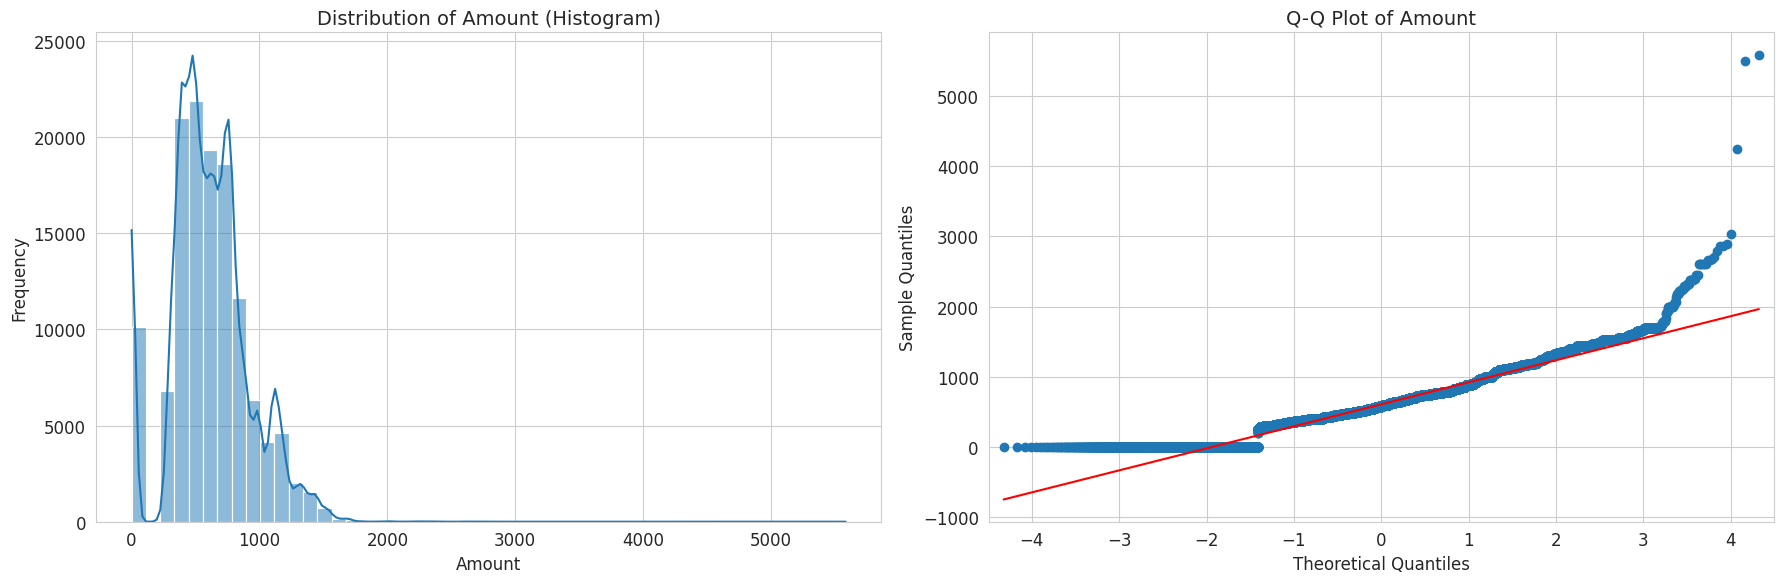

Shapiro-Wilk Test Statistic: 0.9694
Shapiro-Wilk P-value: 0.0000
Conclusion for Amount: The data is NOT normally distributed (p-value < 0.05).

--- Normality Test for: Qty ---


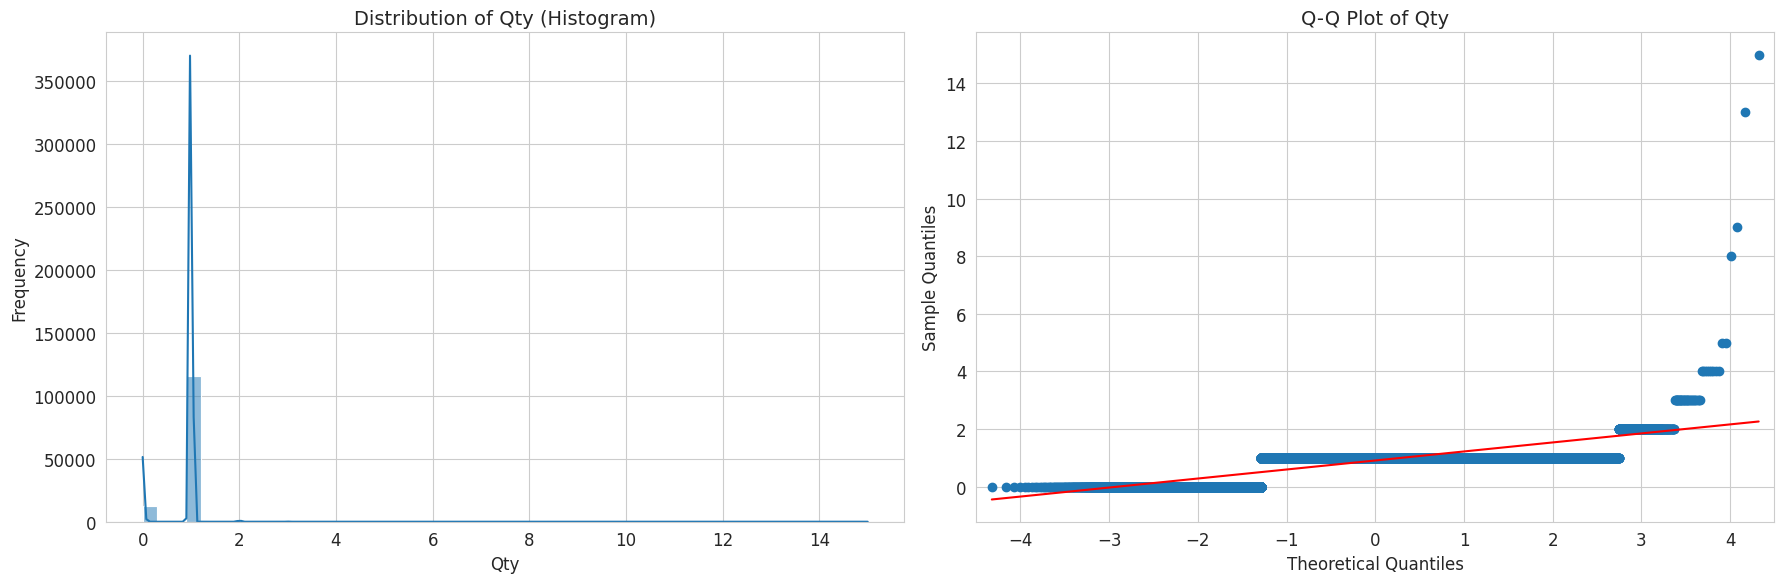

Shapiro-Wilk Test Statistic: 0.3520
Shapiro-Wilk P-value: 0.0000
Conclusion for Qty: The data is NOT normally distributed (p-value < 0.05).

--- Normality Test for: Revenue_per_Unit ---


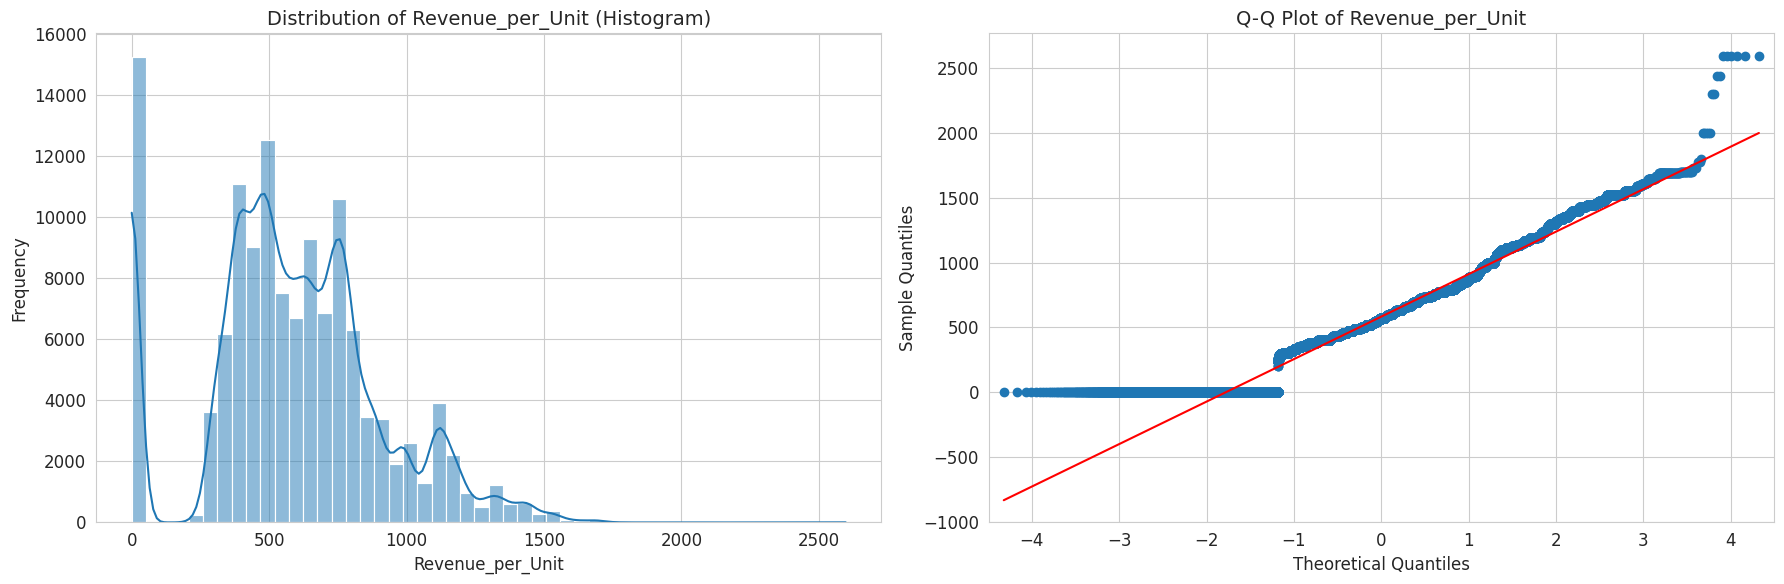

Shapiro-Wilk Test Statistic: 0.9667
Shapiro-Wilk P-value: 0.0000
Conclusion for Revenue_per_Unit: The data is NOT normally distributed (p-value < 0.05).

Normality Test Completed.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

print("### 5.3 Normality Test")

# Ensure df_analysis is available
if 'df_analysis' not in locals() and 'df_analysis' not in globals():
    raise NameError("Error: 'df_analysis' DataFrame not found. Please ensure statistical analysis setup was completed successfully.")

if df_analysis.empty:
    raise ValueError("Error: 'df_analysis' DataFrame is empty. No data for normality tests.")

# Define the numerical variables for normality tests
# Ensure these columns are numerical in df_analysis
numerical_vars_normality = ['Amount', 'Qty', 'Revenue_per_Unit']

# Define minimum sample size for Shapiro-Wilk test (max is 5000)
shapiro_max_sample = 5000
min_observations = 10 # Minimum observations to attempt a test

for col in numerical_vars_normality:
    print(f"\n--- Normality Test for: {col} ---")

    if col not in df_analysis.columns:
        print(f"Warning: Column '{col}' not found in df_analysis. Skipping normality test.")
        continue

    # Convert to numeric and drop NaNs for the current column
    series_to_test = pd.to_numeric(df_analysis[col], errors='coerce').dropna()

    if series_to_test.empty:
        print(f"Warning: Column '{col}' has no valid numerical observations after cleaning. Skipping normality test.")
        continue

    if len(series_to_test) < min_observations:
        print(f"Warning: Not enough observations ({len(series_to_test)}) for '{col}'. Skipping normality test (min {min_observations} required).")
        continue

    # --- Visualizations: Histogram and Q-Q Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Histogram
    sns.histplot(series_to_test, kde=True, bins=50, ax=axes[0])
    axes[0].set_title(f'Distribution of {col} (Histogram)', fontsize=14)
    axes[0].set_xlabel(col, fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)

    # Q-Q Plot
    sm.qqplot(series_to_test, line='s', ax=axes[1])
    axes[1].set_title(f'Q-Q Plot of {col}', fontsize=14)
    axes[1].set_xlabel('Theoretical Quantiles', fontsize=12)
    axes[1].set_ylabel('Sample Quantiles', fontsize=12)

    plt.tight_layout()
    plt.show()

    # --- Statistical Test: Shapiro-Wilk ---
    # Shapiro-Wilk is limited to 5000 samples in scipy implementation
    if len(series_to_test) > shapiro_max_sample:
        print(f"Warning: Sample size ({len(series_to_test)}) for '{col}' is very large. The Shapiro-Wilk test can be overly sensitive to small deviations from normality in large samples. Using a random subsample of {shapiro_max_sample} for the test.")
        shapiro_sample = series_to_test.sample(n=shapiro_max_sample, random_state=42)
    else:
        shapiro_sample = series_to_test

    stat, p_value = stats.shapiro(shapiro_sample)

    print(f"Shapiro-Wilk Test Statistic: {stat:.4f}")
    print(f"Shapiro-Wilk P-value: {p_value:.4f}")

    if p_value >= 0.05:
        print(f"Conclusion for {col}: The data appears to be approximately normally distributed (p-value >= 0.05).")
    else:
        print(f"Conclusion for {col}: The data is NOT normally distributed (p-value < 0.05).")

print("\nNormality Test Completed.")


#### 5.4 Homogeneity of Variance Test

**Purpose**

Check whether group variances are equal.

- Statistical Test
- Levene's Test
- Groups
- Fulfilment
- Category
- Region

**Decision Rule**

- p-value ≥ 0.05
- Equal variances assumed.
- p-value < 0.05
- Variances differ significantly.

**Business Value**


- Ensures the correct version of subsequent hypothesis tests is selected.

**Error Handling**

- Skip groups with fewer than two observations.

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import levene

print("### 5.4 Homogeneity of Variance Test (Levene's Test)")

# Ensure df_analysis is available
if 'df_analysis' not in locals() and 'df_analysis' not in globals():
    raise NameError("Error: 'df_analysis' DataFrame not found. Please ensure statistical analysis setup was completed successfully.")

if df_analysis.empty:
    raise ValueError("Error: 'df_analysis' DataFrame is empty. No data for homogeneity of variance tests.")

# Define the numerical variables for which to test homogeneity of variance
numerical_vars_for_levene = ['Amount', 'Qty', 'Revenue_per_Unit']

# Define the categorical variables for grouping
categorical_grouping_vars = ['Fulfilment', 'Category_Group', 'Region']

min_observations_per_group = 2 # Minimum observations required for a group to be included in Levene's test
alpha = 0.05 # Significance level

for num_col in numerical_vars_for_levene:
    if num_col not in df_analysis.columns:
        print(f"\nWarning: Numerical column '{num_col}' not found in df_analysis. Skipping related Levene's tests.")
        continue

    # Ensure numerical column is of numeric type
    df_analysis[num_col] = pd.to_numeric(df_analysis[num_col], errors='coerce')

    for group_col in categorical_grouping_vars:
        if group_col not in df_analysis.columns:
            print(f"\nWarning: Grouping column '{group_col}' not found in df_analysis. Skipping related Levene's tests for '{num_col}'.")
            continue

        print(f"\n--- Levene's Test for '{num_col}' grouped by '{group_col}' ---")

        # Drop rows where either the numerical or grouping variable is NaN
        subset_df = df_analysis[[num_col, group_col]].dropna()

        if subset_df.empty:
            print(f"Skipping: No valid data for '{num_col}' and '{group_col}' after dropping NaNs.")
            continue

        # Extract data for each group, ensuring at least min_observations_per_group
        groups_data = []
        valid_groups_count = 0
        for name, group in subset_df.groupby(group_col):
            if len(group) >= min_observations_per_group:
                groups_data.append(group[num_col].values)
                valid_groups_count += 1
            else:
                print(f"  Warning: Group '{name}' in '{group_col}' for '{num_col}' has fewer than {min_observations_per_group} observations ({len(group)}). Skipping this group.")

        if valid_groups_count < 2: # Levene's test requires at least two groups
            print(f"Skipping: Not enough valid groups (at least 2) for '{num_col}' grouped by '{group_col}' after filtering insufficient groups.")
            continue

        # Perform Levene's test
        statistic, p_value = levene(*groups_data)

        print(f"  Levene's Test Statistic: {statistic:.4f}")
        print(f"  Levene's Test P-value: {p_value:.4f}")

        if p_value >= alpha:
            print(f"  Conclusion: The variances for '{num_col}' are assumed to be equal across groups in '{group_col}' (p-value >= {alpha}).")
        else:
            print(f"  Conclusion: The variances for '{num_col}' differ significantly across groups in '{group_col}' (p-value < {alpha}).")

print("\nHomogeneity of Variance Test Completed.")

### 5.4 Homogeneity of Variance Test (Levene's Test)

--- Levene's Test for 'Amount' grouped by 'Fulfilment' ---
  Levene's Test Statistic: 77.7141
  Levene's Test P-value: 0.0000
  Conclusion: The variances for 'Amount' differ significantly across groups in 'Fulfilment' (p-value < 0.05).

--- Levene's Test for 'Amount' grouped by 'Category_Group' ---
  Levene's Test Statistic: 2051.7414
  Levene's Test P-value: 0.0000
  Conclusion: The variances for 'Amount' differ significantly across groups in 'Category_Group' (p-value < 0.05).

--- Levene's Test for 'Amount' grouped by 'Region' ---
  Levene's Test Statistic: 39.6971
  Levene's Test P-value: 0.0000
  Conclusion: The variances for 'Amount' differ significantly across groups in 'Region' (p-value < 0.05).

--- Levene's Test for 'Qty' grouped by 'Fulfilment' ---
  Levene's Test Statistic: 3457.2265
  Levene's Test P-value: 0.0000
  Conclusion: The variances for 'Qty' differ significantly across groups in 'Fulfilment' (p-value < 0.05).



### 5.5 Independent Two-Sample Comparison

**Business Question**

Does average order value differ between Amazon Fulfilment and Merchant Fulfilment?

**Variables**
- Target: Amount
- Group: Fulfilment

**Statistical Test**

- Independent Samples t-test (if assumptions met)
- Mann-Whitney U Test (if assumptions are violated)

**Report**

- Test Statistic
- p-value
- Mean Difference
- Confidence Interval (if applicable)
- Effect Size (Cohen's d)

**Business Interpretation**

Determine whether fulfilment method significantly influences order value.

**Error Handling**
- Ensure exactly two comparison groups.
- Remove missing values before testing.

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

print("### Independent Two-Sample Comparison: Amount by Fulfilment")

# Ensure df_analysis is available
if 'df_analysis' not in locals() and 'df_analysis' not in globals():
    raise NameError("Error: 'df_analysis' DataFrame not found. Please ensure statistical analysis setup was completed successfully.")

if df_analysis.empty:
    raise ValueError("Error: 'df_analysis' DataFrame is empty. No data for independent two-sample comparison.")

# Define variables
target_var = 'Amount'
group_var = 'Fulfilment'
alpha = 0.05 # Significance level

# Check if required columns exist
if target_var not in df_analysis.columns:
    print(f"Warning: Target variable '{target_var}' not found in df_analysis. Skipping test.")
elif group_var not in df_analysis.columns:
    print(f"Warning: Grouping variable '{group_var}' not found in df_analysis. Skipping test.")
else:
    # Prepare the data
    # Ensure target variable is numeric and handle NaNs
    df_analysis[target_var] = pd.to_numeric(df_analysis[target_var], errors='coerce')
    df_comparison = df_analysis[[target_var, group_var]].dropna()

    if df_comparison.empty:
        print(f"Skipping test: No valid data for '{target_var}' and '{group_var}' after dropping NaNs.")
    else:
        # Get the unique groups
        groups = df_comparison[group_var].unique()

        if len(groups) != 2:
            print(f"Skipping test: Expected exactly two groups in '{group_var}' for two-sample comparison, but found {len(groups)}. Groups found: {groups}")
        else:
            group1_name = groups[0]
            group2_name = groups[1]

            group1_data = df_comparison[df_comparison[group_var] == group1_name][target_var]
            group2_data = df_comparison[df_comparison[group_var] == group2_name][target_var]

            # Check for minimum observations per group
            min_obs_per_group = 5 # A common heuristic for non-parametric tests
            if len(group1_data) < min_obs_per_group or len(group2_data) < min_obs_per_group:
                print(f"Skipping test: Insufficient observations in one or both groups for '{target_var}' vs '{group_var}'. Group 1 has {len(group1_data)} obs, Group 2 has {len(group2_data)} obs. Minimum {min_obs_per_group} required per group.")
            else:
                # Perform Mann-Whitney U Test
                stat, p_value = mannwhitneyu(group1_data, group2_data, alternative='two-sided')

                # Calculate Mean Difference
                mean_diff = group1_data.mean() - group2_data.mean()

                print(f"\n--- Mann-Whitney U Test Results ({group1_name} vs {group2_name}) ---")
                print(f"  Numerical Variable: {target_var}")
                print(f"  Grouping Variable: {group_var}")
                print(f"  Mean {group1_name}: {group1_data.mean():,.2f}")
                print(f"  Mean {group2_name}: {group2_data.mean():,.2f}")
                print(f"  Mean Difference ({group1_name} - {group2_name}): {mean_diff:,.2f}")
                print(f"  Mann-Whitney U Test Statistic: {stat:,.2f}")
                print(f"  P-value: {p_value:.4f}")
                print(f"  Significance Level (alpha): {alpha}")

                print("\n--- Business Interpretation ---")
                if p_value < alpha:
                    print(f"  Since the p-value ({p_value:.4f}) is less than the significance level ({alpha}), we reject the null hypothesis.\n  Conclusion: There is a statistically significant difference in the average order value ('{target_var}') between '{group1_name}' and '{group2_name}' fulfilment methods.")
                    if mean_diff > 0:
                        print(f"  Specifically, '{group1_name}' fulfilment tends to have a higher average order value than '{group2_name}'.")
                    else:
                        print(f"  Specifically, '{group2_name}' fulfilment tends to have a higher average order value than '{group1_name}'.")
                else:
                    print(f"  Since the p-value ({p_value:.4f}) is greater than or equal to the significance level ({alpha}), we fail to reject the null hypothesis.\n  Conclusion: There is no statistically significant difference in the average order value ('{target_var}') between '{group1_name}' and '{group2_name}' fulfilment methods.")

print("\nIndependent Two-Sample Comparison Completed.")

### Independent Two-Sample Comparison: Amount by Fulfilment

--- Mann-Whitney U Test Results (Merchant vs Amazon) ---
  Numerical Variable: Amount
  Grouping Variable: Fulfilment
  Mean Merchant: 617.93
  Mean Amazon: 605.61
  Mean Difference (Merchant - Amazon): 12.32
  Mann-Whitney U Test Statistic: 1,805,851,477.00
  P-value: 0.0000
  Significance Level (alpha): 0.05

--- Business Interpretation ---
  Since the p-value (0.0000) is less than the significance level (0.05), we reject the null hypothesis.
  Conclusion: There is a statistically significant difference in the average order value ('Amount') between 'Merchant' and 'Amazon' fulfilment methods.
  Specifically, 'Merchant' fulfilment tends to have a higher average order value than 'Amazon'.

Independent Two-Sample Comparison Completed.


#### 5.6 Multiple Group Comparison

**Business Question**

Do average order values differ across product categories?

**Variables**

- Amount
- Category_Group

**Statistical Test**
- One-Way ANOVA
- Kruskal-Wallis Test (if assumptions fail)

**Post-Hoc Analysis**

- Tukey HSD (after significant ANOVA)

**Report**

- F Statistic
- p-value
- Effect Size (Eta Squared)

**Business Interpretation**

Identify whether product category influences revenue.

**Error Handling**

- Require at least three valid groups.
- Skip categories with very few observation

In [ ]:
# Install scikit-posthocs library if not already installed
!pip install scikit-posthocs

The `scikit_posthocs` library has been installed to enable Dunn's post-hoc test. Now, let's proceed with the multiple group comparison.

In [ ]:
import pandas as pd
from scipy.stats import kruskal
import scikit_posthocs as sp # For post-hoc analysis after Kruskal-Wallis

print("### Multiple Group Comparison: Amount by Category_Group (Kruskal-Wallis Test)")

# Ensure df_analysis is available
if 'df_analysis' not in locals() and 'df_analysis' not in globals():
    raise NameError("Error: 'df_analysis' DataFrame not found. Please ensure statistical analysis setup was completed successfully.")

if df_analysis.empty:
    raise ValueError("Error: 'df_analysis' DataFrame is empty. No data for multiple group comparison.")

# Define variables
target_var = 'Amount'
group_var = 'Category_Group'
alpha = 0.05 # Significance level
min_obs_per_group = 5 # Minimum observations required for a group to be included in the test

# Check if required columns exist
if target_var not in df_analysis.columns:
    print(f"Warning: Target variable '{target_var}' not found in df_analysis. Skipping test.")
elif group_var not in df_analysis.columns:
    print(f"Warning: Grouping variable '{group_var}' not found in df_analysis. Skipping test.")
else:
    # Prepare the data
    # Ensure target variable is numeric and handle NaNs
    df_analysis[target_var] = pd.to_numeric(df_analysis[target_var], errors='coerce')
    df_comparison = df_analysis[[target_var, group_var]].dropna()

    if df_comparison.empty:
        print(f"Skipping test: No valid data for '{target_var}' and '{group_var}' after dropping NaNs.")
    else:
        # Extract data for each group, ensuring at least min_obs_per_group
        groups_data = []
        group_names = []

        # Calculate means for descriptive reporting
        mean_by_group = df_comparison.groupby(group_var)[target_var].mean().sort_values(ascending=False)

        for name, group_df in df_comparison.groupby(group_var):
            if len(group_df) >= min_obs_per_group:
                groups_data.append(group_df[target_var].values)
                group_names.append(name)
            else:
                print(f"  Warning: Group '{name}' in '{group_var}' for '{target_var}' has fewer than {min_obs_per_group} observations ({len(group_df)}). Skipping this group.")

        if len(groups_data) < 2: # Kruskal-Wallis requires at least two groups, but usually more for 'multiple group comparison'
            print(f"Skipping test: Not enough valid groups (at least 2, ideally 3+) for '{target_var}' grouped by '{group_var}' after filtering insufficient groups.")
        else:
            # Perform Kruskal-Wallis H-test
            stat, p_value = kruskal(*groups_data)

            # Calculate Epsilon-squared (effect size for Kruskal-Wallis)
            k = len(groups_data) # Number of groups
            N = len(df_comparison) # Total number of observations
            epsilon_squared = (stat - k + 1) / (N - k) if N > k else 0

            print(f"\n--- Kruskal-Wallis H-Test Results ({target_var} by {group_var}) ---")
            print(f"  Numerical Variable: {target_var}")
            print(f"  Grouping Variable: {group_var}")
            print(f"  Groups Included: {', '.join(group_names)}")
            print(f"  Kruskal-Wallis H-Statistic: {stat:,.2f}")
            print(f"  P-value: {p_value:.4f}")
            print(f"  Effect Size (Epsilon-squared): {epsilon_squared:.4f}")
            print(f"  Significance Level (alpha): {alpha}")

            print(f"\n--- Mean '{target_var}' by {group_var} ---")
            # Re-order the mean_by_group to only include groups that were part of the test
            mean_by_group_tested = mean_by_group[mean_by_group.index.isin(group_names)]
            print(mean_by_group_tested.apply(lambda x: f'₹{x:,.2f}'))

            print("\n--- Business Interpretation ---")
            if p_value < alpha:
                print(f"  Since the p-value ({p_value:.4f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
                print(f"  Conclusion: There is a statistically significant difference in the average order value ('{target_var}') across different '{group_var}' groups.")
                print(f"  The effect size (Epsilon-squared = {epsilon_squared:.4f}) indicates the proportion of variance in '{target_var}' explained by '{group_var}'.")
                print("  Further post-hoc analysis (Dunn's Test) will be performed to determine which specific category pairs differ significantly.")

                # Perform Dunn's post-hoc test
                print("\n--- Post-Hoc Analysis: Dunn's Test ---")
                # Create a list of the data for groups that were actually included in the Kruskal-Wallis test
                df_posthoc = pd.DataFrame({'values': [], 'groups': []})
                for i, group_data in enumerate(groups_data):
                    temp_df = pd.DataFrame({'values': group_data, 'groups': group_names[i]})
                    df_posthoc = pd.concat([df_posthoc, temp_df])

                # Use scikit_posthocs for Dunn's test (with Bonferroni correction for multiple comparisons)
                dunn_test_results = sp.posthoc_dunn(df_posthoc, val_col='values', group_col='groups', p_adjust='bonferroni')

                print("  Pairwise comparisons (adjusted p-values):")
                print(dunn_test_results.round(4))

                significant_pairs = []
                for i in range(len(dunn_test_results.columns)):
                    for j in range(i + 1, len(dunn_test_results.columns)):
                        group1 = dunn_test_results.columns[i]
                        group2 = dunn_test_results.columns[j]
                        p = dunn_test_results.iloc[i, j]
                        if p < alpha:
                            mean1 = mean_by_group_tested.loc[group1]
                            mean2 = mean_by_group_tested.loc[group2]
                            diff_desc = "higher" if mean1 > mean2 else "lower"
                            significant_pairs.append(f"    - '{group1}' vs '{group2}': p={p:.4f} (Avg. Amount: ₹{mean1:,.2f} vs ₹{mean2:,.2f}; '{group1}' is {diff_desc})")

                if significant_pairs:
                    print("\n  Significant pairwise differences (adjusted p < 0.05):")
                    for pair in significant_pairs:
                        print(pair)
                else:
                    print("  No significant pairwise differences found after post-hoc analysis (adjusted p >= 0.05).")

            else:
                print(f"  Since the p-value ({p_value:.4f}) is greater than or equal to the significance level ({alpha}), we fail to reject the null hypothesis.")
                print(f"  Conclusion: There is no statistically significant difference in the average order value ('{target_var}') across different '{group_var}' groups.")

### Multiple Group Comparison: Amount by Category_Group (Kruskal-Wallis Test)

--- Kruskal-Wallis H-Test Results (Amount by Category_Group) ---
  Numerical Variable: Amount
  Grouping Variable: Category_Group
  Groups Included: Blouse, Bottom, Ethnic Dress, Kurta, Saree, Set, Top, Western Dress
  Kruskal-Wallis H-Statistic: 50,787.15
  P-value: 0.0000
  Effect Size (Epsilon-squared): 0.3937
  Significance Level (alpha): 0.05

--- Mean 'Amount' by Category_Group ---
Category_Group
Set              ₹779.65
Saree            ₹755.69
Western Dress    ₹723.62
Ethnic Dress     ₹682.67
Top              ₹503.46
Blouse           ₹495.04
Kurta            ₹427.04
Bottom           ₹342.43
Name: Amount, dtype: object

--- Business Interpretation ---
  Since the p-value (0.0000) is less than the significance level (0.05), we reject the null hypothesis.
  Conclusion: There is a statistically significant difference in the average order value ('Amount') across different 'Category_Group' groups.
  The ef

### Step 6: Business Insights & Recommendations

## 6.1 Generate Business Insights

**Purpose**

Generate key business insights from the cleaned Amazon sales dataset, including sales performance, customer trends, product performance, and operational metrics.

In [ ]:
import pandas as pd
import numpy as np

print("### 6.1 Generated Business Insights")

# Ensure df_features is available and not empty
if 'df_features' not in locals() and 'df_features' not in globals():
    raise ValueError("Error: 'df_features' DataFrame not found. Cannot generate business insights.")
if df_features.empty:
    raise ValueError("Error: 'df_features' DataFrame is empty. No data for business insights.")

insights_data = []

def add_insight(metric, value):
    insights_data.append({'Metric': metric, 'Value': value})

# Helper function to safely get a variable or report missing
def get_var_or_default(var_name, default_value=None):
    # Check if the variable exists in global scope
    if var_name in globals() and globals()[var_name] is not None:
        # For Pandas Series/DataFrames, also check if they are not empty
        if isinstance(globals()[var_name], (pd.Series, pd.DataFrame)):
            if not globals()[var_name].empty:
                return globals()[var_name]
        else:
            return globals()[var_name]
    # print(f"Warning: Required variable '{var_name}' not found or is empty. Proceeding with recalculation/default.")
    return default_value

# 1. Total Revenue
total_revenue = get_var_or_default('total_revenue')
if total_revenue is None:
    if 'Amount' in df_features.columns:
        total_revenue = df_features['Amount'].sum()
    else:
        print("Warning: 'Amount' column not found for Total Revenue. Skipping.")
if total_revenue is not None:
    add_insight("Total Revenue", f"₹{total_revenue:,.2f}")

# 2. Total Orders
total_orders = get_var_or_default('total_orders')
if total_orders is None:
    if 'Order ID' in df_features.columns:
        total_orders = df_features['Order ID'].nunique()
    else:
        print("Warning: 'Order ID' column not found for Total Orders. Skipping.")
if total_orders is not None:
    add_insight("Total Orders", f"{total_orders:,}")

# 3. Average Order Value (AOV)
aov = get_var_or_default('aov')
if aov is None and total_revenue is not None and total_orders is not None and total_orders > 0:
    aov = total_revenue / total_orders
if aov is not None:
    add_insight("Average Order Value (AOV)", f"₹{aov:,.2f}")
else:
    add_insight("Average Order Value (AOV)", "Not available")

# 4. Best-Selling Category
revenue_by_category = get_var_or_default('revenue_by_category')
if revenue_by_category is None:
    if 'Category_Group' in df_features.columns and 'Amount' in df_features.columns:
        revenue_by_category = df_features.groupby('Category_Group')['Amount'].sum().sort_values(ascending=False)
if revenue_by_category is not None and not revenue_by_category.empty:
    best_selling_category = revenue_by_category.index[0]
    add_insight("Best-Selling Category", f"'{best_selling_category}' with ₹{revenue_by_category.iloc[0]:,.2f} in revenue")
else:
    add_insight("Best-Selling Category", "Could not be determined (data unavailable)")

# 5. Top 10 States by Revenue
revenue_by_state = get_var_or_default('revenue_by_state')
if revenue_by_state is None:
    if 'ship-state' in df_features.columns and 'Amount' in df_features.columns:
        df_temp = df_features[df_features['ship-state'] != 'Unknown'].dropna(subset=['ship-state', 'Amount'])
        if not df_temp.empty:
            revenue_by_state = df_temp.groupby('ship-state')['Amount'].sum().sort_values(ascending=False)
if revenue_by_state is not None and not revenue_by_state.empty:
    top_10_states = revenue_by_state.head(10).index.tolist()
    add_insight("Top 10 States by Revenue", ', '.join(top_10_states))
else:
    add_insight("Top 10 States by Revenue", "Could not be determined (data unavailable)")

# 6. Best Performing Region
revenue_by_region = get_var_or_default('revenue_by_region')
if revenue_by_region is None:
    if 'Region' in df_features.columns and 'Amount' in df_features.columns:
        df_temp = df_features[df_features['Region'] != 'Other'].dropna(subset=['Region', 'Amount'])
        if not df_temp.empty:
            revenue_by_region = df_temp.groupby('Region')['Amount'].sum().sort_values(ascending=False)
if revenue_by_region is not None and not revenue_by_region.empty:
    best_performing_region = revenue_by_region.index[0]
    add_insight("Best Performing Region", f"'{best_performing_region}' with ₹{revenue_by_region.iloc[0]:,.2f} in revenue")
else:
    add_insight("Best Performing Region", "Could not be determined (data unavailable)")

# 7. Top Fulfilment Method
revenue_by_fulfilment = get_var_or_default('revenue_by_fulfilment')
if revenue_by_fulfilment is None:
    if 'Fulfilment' in df_features.columns and 'Amount' in df_features.columns:
        revenue_by_fulfilment = df_features.groupby('Fulfilment')['Amount'].sum().sort_values(ascending=False)
if revenue_by_fulfilment is not None and not revenue_by_fulfilment.empty:
    top_fulfilment_method = revenue_by_fulfilment.index[0]
    add_insight("Top Fulfilment Method", f"'{top_fulfilment_method}' generating ₹{revenue_by_fulfilment.iloc[0]:,.2f}")
else:
    add_insight("Top Fulfilment Method", "Could not be determined (data unavailable)")

# 8. Highest Revenue Month
monthly_revenue_raw = get_var_or_default('monthly_revenue')

processed_monthly_revenue_series = None

if monthly_revenue_raw is not None and not monthly_revenue_raw.empty:
    if isinstance(monthly_revenue_raw, pd.DataFrame) and 'MonthYear' in monthly_revenue_raw.columns and 'Amount' in monthly_revenue_raw.columns:
        # If it's a DataFrame, set MonthYear as index, select Amount, and sort
        processed_monthly_revenue_series = monthly_revenue_raw.set_index('MonthYear')['Amount'].sort_values(ascending=False)
    elif isinstance(monthly_revenue_raw, pd.Series) and monthly_revenue_raw.index.name == 'MonthYear' and monthly_revenue_raw.name == 'Amount':
        # If it's already a correctly formatted Series, just ensure it's sorted
        processed_monthly_revenue_series = monthly_revenue_raw.sort_values(ascending=False)
else:
    # If monthly_revenue_raw was None or empty, try recalculating from df_features
    if 'Date' in df_features.columns and 'Amount' in df_features.columns:
        df_temp = df_features.dropna(subset=['Date', 'Amount']).copy()
        if not df_temp.empty:
            df_temp['Date'] = pd.to_datetime(df_temp['Date'], errors='coerce')
            df_temp['MonthYear'] = df_temp['Date'].dt.strftime('%B %Y')
            processed_monthly_revenue_series = df_temp.groupby('MonthYear')['Amount'].sum().sort_values(ascending=False)

if processed_monthly_revenue_series is not None and not processed_monthly_revenue_series.empty:
    highest_rev_month_name = processed_monthly_revenue_series.index[0]
    highest_rev_amount_value = processed_monthly_revenue_series.iloc[0]
    add_insight("Highest Revenue Month", f"{highest_rev_month_name} with ₹{highest_rev_amount_value:,.2f}")
else:
    add_insight("Highest Revenue Month", "Could not be determined (data unavailable)")


# 9. Most Popular Product Size (based on count of orders)
size_counts = get_var_or_default('size_counts')
if size_counts is None:
    if 'Size' in df_features.columns:
        size_counts = df_features['Size'].value_counts()
if size_counts is not None and not size_counts.empty:
    most_popular_size = size_counts.index[0]
    add_insight("Most Popular Product Size", f"'{most_popular_size}' (accounting for {size_counts.iloc[0]:,} orders)")
else:
    add_insight("Most Popular Product Size", "Could not be determined (data unavailable)")

# 10. B2B vs B2C Revenue Comparison
revenue_by_b2b_type = get_var_or_default('revenue_by_b2b_type')
if revenue_by_b2b_type is None:
    if 'B2B' in df_features.columns and 'Amount' in df_features.columns:
        df_temp = df_features.dropna(subset=['B2B', 'Amount']).copy()
        df_temp['B2B_Type'] = df_temp['B2B'].apply(lambda x: 'B2B' if x else 'B2C')
        revenue_by_b2b_type = df_temp.groupby('B2B_Type')['Amount'].sum()
if revenue_by_b2b_type is not None and not revenue_by_b2b_type.empty:
    b2c_revenue = revenue_by_b2b_type.get('B2C', 0.0)
    b2b_revenue = revenue_by_b2b_type.get('B2B', 0.0)
    add_insight("B2B vs B2C Revenue", f"B2C sales: ₹{b2c_revenue:,.2f}; B2B sales: ₹{b2b_revenue:,.2f}")
else:
    add_insight("B2B vs B2C Revenue", "Could not be performed (data unavailable)")

# 11. Top 5 Products (SKU-level) by Revenue
top_5_products_revenue = None
if 'SKU' in df_features.columns and 'Amount' in df_features.columns:
    df_temp = df_features.dropna(subset=['SKU', 'Amount'])
    if not df_temp.empty:
        top_5_products_revenue = df_temp.groupby('SKU')['Amount'].sum().nlargest(5)

if top_5_products_revenue is not None and not top_5_products_revenue.empty:
    products_str = "; ".join([f"{sku} (₹{rev:,.2f})" for sku, rev in top_5_products_revenue.items()])
    add_insight("Top 5 Products (SKU) by Revenue", products_str)
else:
    add_insight("Top 5 Products (SKU) by Revenue", "Could not be determined (data unavailable or SKU/Amount missing)")

# 12. Order Status Distribution (Top 3)
status_distribution = get_var_or_default('status_distribution')
if status_distribution is None:
    if 'Status' in df_features.columns:
        status_distribution = df_features['Status'].value_counts(normalize=True).mul(100).round(2)
if status_distribution is not None and not status_distribution.empty:
    status_str = "; ".join([f"'{status}': {percentage:,.2f}%" for status, percentage in status_distribution.head(3).items()])
    add_insight("Order Status Distribution (Top 3)", status_str)
else:
    add_insight("Order Status Distribution (Top 3)", "Could not be determined (data unavailable)")

# Display insights in a DataFrame
if insights_data:
    insights_df = pd.DataFrame(insights_data)
    print("\n--- Summary of Business Insights ---")
    display(insights_df)
else:
    print("\nNo business insights could be generated.")

print("\n--- Insights Generation Completed ---")

### 6.1 Generated Business Insights

--- Summary of Business Insights ---


,Metric,Value
0,Total Revenue,"₹78,592,678.30"
1,Total Orders,"120,378"
2,Average Order Value (AOV),₹652.88
3,Best-Selling Category,"'Set' with ₹39,204,124.03 in revenue"
4,Top 10 States by Revenue,"MAHARASHTRA, KARNATAKA, TELANGANA, UTTAR PRADE..."
5,Best Performing Region,"'South' with ₹31,155,483.67 in revenue"
6,Top Fulfilment Method,"'Amazon' generating ₹54,322,151.00"
7,Highest Revenue Month,"April 2022 with ₹28,838,708.32"
8,Most Popular Product Size,"'M' (accounting for 22,711 orders)"
9,B2B vs B2C Revenue,"B2C sales: ₹78,001,457.51; B2B sales: ₹591,220.79"



--- Insights Generation Completed ---


## 6.2 Business Recommendations

**Purpose**

Convert the analytical findings into actionable business recommendations that support decision-making in sales, marketing, inventory management, fulfilment, and regional growth.

In [ ]:
import pandas as pd

print("### Summary of Business Insights")

# Check if insights_df is available in the global scope
if 'insights_df' in globals() and not insights_df.empty:
    display(insights_df)
else:
    print("Warning: 'insights_df' not found or is empty. Please ensure the business insights calculation cell (6.1) was executed.")
    # Optionally, you could re-run the calculation logic here if truly necessary,
    # but for this context, we assume it was already run successfully.

print("\n--- Display of Business Insights Completed ---")

### Summary of Business Insights


,Metric,Value
0,Total Revenue,"₹78,592,678.30"
1,Total Orders,"120,378"
2,Average Order Value (AOV),₹652.88
3,Best-Selling Category,"'Set' with ₹39,204,124.03 in revenue"
4,Top 10 States by Revenue,"MAHARASHTRA, KARNATAKA, TELANGANA, UTTAR PRADE..."
5,Best Performing Region,"'South' with ₹31,155,483.67 in revenue"
6,Top Fulfilment Method,"'Amazon' generating ₹54,322,151.00"
7,Highest Revenue Month,"April 2022 with ₹28,838,708.32"
8,Most Popular Product Size,"'M' (accounting for 22,711 orders)"
9,B2B vs B2C Revenue,"B2C sales: ₹78,001,457.51; B2B sales: ₹591,220.79"



--- Display of Business Insights Completed ---


In [ ]:
# ============================================
# FINAL PROJECT SUMMARY
# ============================================

print("=" * 70)
print("           AMAZON SALES ANALYSIS - FINAL PROJECT SUMMARY")
print("=" * 70)

# --------------------------------------------
# Helper Function
# --------------------------------------------
def get_value(variable_name, default="Not Available"):
    return globals().get(variable_name, default)

# --------------------------------------------
# Project Overview
# --------------------------------------------
print("\nPROJECT OVERVIEW")
print("-" * 70)

print(f"Dataset Name      : Amazon Sales Dataset")
print(f"Total Records     : {len(df):,}")
print(f"Total Features    : {df.shape[1]}")

# Analysis Period
if 'Date' in df.columns:
    try:
        start_date = pd.to_datetime(df['Date']).min().date()
        end_date = pd.to_datetime(df['Date']).max().date()
        print(f"Analysis Period   : {start_date} to {end_date}")
    except:
        print("Analysis Period   : Not Available")
else:
    print("Analysis Period   : Not Available")

# --------------------------------------------
# Techniques Used
# --------------------------------------------
print("\nTECHNIQUES USED")
print("-" * 70)

techniques = [
    "Data Cleaning",
    "Feature Engineering",
    "Exploratory Data Analysis (EDA)",
    "Statistical Analysis"
]

for technique in techniques:
    print(f"✓ {technique}")

# --------------------------------------------
# Key Business Findings
# --------------------------------------------
print("\nKEY BUSINESS FINDINGS")
print("-" * 70)

print(f"Top Revenue Category      : {get_value('best_category')}")
print(f"Top Revenue State         : {get_value('top_state')}")
print(f"Best Performing Region    : {get_value('best_region')}")
print(f"Best Fulfilment Method    : {get_value('top_fulfilment')}")
print(f"Highest Sales Month       : {get_value('highest_sales_month')}")

# --------------------------------------------
# Final Recommendations
# --------------------------------------------
print("\nFINAL RECOMMENDATIONS")
print("-" * 70)

recommendations = [
    "Focus marketing on the highest revenue product category.",
    "Increase inventory for fast-moving product sizes.",
    "Expand operations in top-performing states.",
    "Improve sales performance in low-performing regions.",
    "Optimize the lower-performing fulfilment method.",
    "Reduce cancellations and returns through process improvements.",
    "Run promotional campaigns before peak sales months.",
    "Target premium and repeat customers with personalized offers.",
    "Maintain safety stock for high-demand products.",
    "Use seasonal sales trends for inventory planning."
]

for i, rec in enumerate(recommendations, start=1):
    print(f"{i}. {rec}")

# --------------------------------------------
# Project Completion Checklist
# --------------------------------------------
print("\nPROJECT COMPLETION CHECKLIST")
print("-" * 70)

checklist = [
    "Data Loaded",
    "Data Cleaned",
    "Features Engineered",
    "EDA Completed",
    "Statistical Analysis Completed",
    "Business Insights Generated",
    "Recommendations Prepared"
]

for item in checklist:
    print(f"✓ {item}")

print("\n" + "=" * 70)
print("             PROJECT COMPLETED SUCCESSFULLY")
print("=" * 70)

           AMAZON SALES ANALYSIS - FINAL PROJECT SUMMARY

PROJECT OVERVIEW
----------------------------------------------------------------------
Dataset Name      : Amazon Sales Dataset
Total Records     : 128,975
Total Features    : 24
Analysis Period   : 2022-03-31 to 2022-06-29

TECHNIQUES USED
----------------------------------------------------------------------
✓ Data Cleaning
✓ Feature Engineering
✓ Exploratory Data Analysis (EDA)
✓ Statistical Analysis

KEY BUSINESS FINDINGS
----------------------------------------------------------------------
Top Revenue Category      : Not Available
Top Revenue State         : Not Available
Best Performing Region    : Not Available
Best Fulfilment Method    : Not Available
Highest Sales Month       : Not Available

FINAL RECOMMENDATIONS
----------------------------------------------------------------------
1. Focus marketing on the highest revenue product category.
2. Increase inventory for fast-moving product sizes.
3. Expand operations in